In [1]:
!pip install torchsummary
!pip install torchmetrics
!pip install git+https://github.com/fangwei123456/spikingjelly.git

  Cloning https://github.com/fangwei123456/spikingjelly.git to /tmp/pip-req-build-3dbkp0cb
  Running command git clone --filter=blob:none --quiet https://github.com/fangwei123456/spikingjelly.git /tmp/pip-req-build-3dbkp0cb
  Resolved https://github.com/fangwei123456/spikingjelly.git to commit 142245d6b06aadc7d18842ddc52bd98e67b17b54
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 1.9 MB/s eta 0:00:00
  Created wheel for spikingjelly: filename=spikingjelly-2.0.0-py3-none-any.whl size=996615 sha256=ddb18eb6fbf75a9b1fbd97112e32be03d389e9957d420dc7dc8bbe69c8408fe4
  Stored in directory: /tmp/pip-ephem-wheel-cache-3nu7clcd/wheels/93/ab/c9/e0318e4c9feaebc1632bcc0168638a2ed5ef17340741c9ad49
Successfully built spikingjelly


In [2]:
!python --version

Python 3.12.13


In [3]:
%matplotlib inline

# import
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision
import numpy as np
from torchsummary import summary # Libraries for previewing neural network architectures
from spikingjelly.activation_based import neuron, encoding, functional, surrogate
from spikingjelly import visualizing
from matplotlib import pyplot as plt
import time

In [4]:
import inspect

print("=== Encoding ===")
print(dir(encoding))


=== Encoding ===
['F', 'LatencyEncoder', 'PeriodicEncoder', 'PoissonEncoder', 'PopEncoder', 'PopSpikeEncoderDeterministic', 'PopSpikeEncoderRandom', 'StatefulEncoder', 'StatelessEncoder', 'WeightedPhaseEncoder', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_population_activity', '_population_parameters', 'abstractmethod', 'base', 'functional', 'math', 'neuron', 'nn', 'surrogate', 'torch']


In [5]:
# Configure basic information
# Configure the hardware platform
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")
# Specify the dataset directory
dataset_dir = './dataset' # Dataset directory
# Specify the dataset's batch_size
batch_size = 64
# Set the directory for auto-saving models
# Be sure to create this directory beforehand
model_auto_save_dir = './model_save/auto_save/'
# Set the directory for manually saving models
# Make sure the folder has been created
model_history_save_dir = './model_save/history_save/'
# Set the path to the external image
# Make sure the image is present in the corresponding folder; if no external image is available, comment out this line of code
# img_path = “./dataset/images1.jpg”
# Do not print ellipses in Jupyter output; disabling this is recommended when there are too many network parameters
# torch.set_printoptions(threshold=np.inf)

os.makedirs(model_auto_save_dir, exist_ok=True)
os.makedirs(model_history_save_dir, exist_ok=True)

device: cuda:0


In [6]:
# Import the dataset

# Load the training dataset
train_dataset = torchvision.datasets.MNIST(
    root=dataset_dir,
    train=True,
    transform=torchvision.transforms.ToTensor(),
    download=True
)
# Load the test dataset
test_dataset = torchvision.datasets.MNIST(
    root=dataset_dir,
    train=False,
    transform=torchvision.transforms.ToTensor(),
    download=True
)
# Print the size of the training dataset
train_dataset_size = len(train_dataset)
print(f"Training dataset size: {train_dataset_size}")
# Print the size of the test dataset
test_dataset_size = len(test_dataset)
print(f"Test dataset size: {test_dataset_size}")

# Load the training data using DataLoader
train_dataloader = data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    pin_memory=True
)
# Load the test data using DataLoader
test_dataloader = data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.17MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.06MB/s]

Training dataset size: 60000
Test dataset size: 10000


In [7]:
isinstance(train_dataset, torch.utils.data.Dataset)

True

## ANN

In [8]:
from torch.utils.data import random_split

# Load the original test dataset
test_dataset_full = test_dataset

# Split original test set 50/50 into validation and test
val_size = len(test_dataset_full) // 2
test_size = len(test_dataset_full) - val_size

a_val_dataset, a_test_dataset = random_split(
    test_dataset_full,
    [val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Training:   {len(train_dataset)}")
print(f"Validation: {len(a_val_dataset)}")
print(f"Test:       {len(a_test_dataset)}")

Training:   60000
Validation: 5000
Test:       5000


In [9]:
NUM_CLASSES  = len(train_dataset.classes)
CLASS_NAMES  = train_dataset.classes
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Val: {len(a_val_dataset)} | Test: {len(a_test_dataset)}")

Classes (10): ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Train: 60000 | Val: 5000 | Test: 5000


In [10]:
# Load the test data using DataLoader
a_test_dataloader = data.DataLoader(
    dataset=a_test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

# Load the test data using DataLoader
a_val_dataloader = data.DataLoader(
    dataset=a_val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

In [11]:
import os, re, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch.optim import Optimizer, Adam, AdamW, SGD
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import timm
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import  ImageFolder
from collections import Counter
from torchvision.transforms import ToTensor
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score


In [12]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")

In [13]:
from sklearn.model_selection import train_test_split
from pathlib import Path

from tqdm import tqdm
from typing import Tuple, Union, Callable

CriterionType = Union[
    nn.Module,
    Callable[[torch.Tensor, torch.Tensor], torch.Tensor]
]

In [14]:
class ANN(nn.Module):
  @property
  def has_backbone(): return False

  def __init__(self, num_classes=8):
      super().__init__()
      # convolutions & pooling layers
      self.features = nn.Sequential(
          # Block 1: 1 conv layer
          nn.LazyConv2d(32, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2), # from 224 to 112

          # Block 2: 1 conv layer
          nn.LazyConv2d(64, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2), # from 112 to 56
      )

      # fully-connected layers
      self.classifier = nn.Sequential(
          nn.Flatten(),  # flat tensor to vector
          nn.LazyLinear(512),
          nn.ReLU(),
          nn.Dropout(p=0.4),
          nn.LazyLinear(256),
          nn.ReLU(),
          nn.LazyLinear(num_classes)
      )

  def forward(self, x):
    x = self.features(x)
    output = self.classifier(x)
    return output

In [15]:
class ANNV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1),
            nn.BatchNorm2d(32, eps=1e-3),
            nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(32, 32, 3, 1),
            nn.BatchNorm2d(32, eps=1e-3),
            nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(32, 32, 3, 1),
            nn.BatchNorm2d(32, eps=1e-3),
            nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Flatten(),
            nn.Linear(32, 10),
            nn.ReLU()
        )

    def forward(self,x):
        x = self.network(x)
        return x

In [16]:
MAX_EPOCH_LIMIT = 30

In [17]:
CHECKPOINT_DIR = Path("./model_save/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

In [18]:
def get_backbone(model: nn.Module):
    """Return the backbone module for freezing (works for all model types)."""
    for attr in ["backbone", "base", "base_model", "features"]:
        if hasattr(model, attr):
            return getattr(model, attr)
    return None

# a function for training one epoch
def train_one_epoch(model: nn.Module, dataloader: DataLoader, optimizer: Optimizer, criterion: CriterionType, epoch: int, max_epoch: int) -> Tuple[float, float]:
  # Prepare for storing loss and accuracy
  losses = MeanMetric().to(DEVICE)
  acc = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(DEVICE)
  model.train() # set model to train mode
  # a loop to iterate input(X)[image] and label(Y) for all mini-batches
  for X, y in tqdm(dataloader, desc=f"Epoch {epoch+1}/{max_epoch} Training Loop", leave=False):
      X, y = X.to(DEVICE), y.to(DEVICE)
      optimizer.zero_grad() # reset optimizer
      preds = model(X) # model forward
      loss = criterion(preds, y) # calculate loss
      loss.backward() # compute gradients via backpropagation
      torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
      optimizer.step() # perform gradient descent
      preds = preds.argmax(dim=1) # obtain the final predicted class
      losses.update(loss, X.size(0)) # store loss per batch
      acc.update(preds, y) # store accuracy per batch
  return losses.compute().item(), acc.compute().item()

# a function for validating one epoch
def validate_one_epoch(model: nn.Module, dataloader: DataLoader, optimizer: Optimizer, criterion: CriterionType, epoch: int, max_epoch: int) -> Tuple[float, float]:
  # Prepare for storing loss and accuracy
  losses = MeanMetric().to(DEVICE)
  acc = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(DEVICE)
  model.eval() # set model to validation mode
  with torch.no_grad(): # disables gradient computation for evaluation
    # a loop to iterate input(X)[image] and label(Y) for all mini-batches
    for X, y in tqdm(dataloader, desc=f"Epoch {epoch+1}/{max_epoch} Validation Loop", leave=False):
      X, y = X.to(DEVICE), y.to(DEVICE)
      preds = model(X) # model forward
      loss = criterion(preds, y) # calculate loss
      preds = preds.argmax(dim=1) # obtain the final predicted class
      losses.update(loss, X.size(0)) # store loss per batch
      acc.update(preds, y) # store accuracy per batch
  return losses.compute().item(), acc.compute().item()



def train_model_adam_w(model: nn.Module, model_name: str, train_loader: DataLoader, val_loader: DataLoader,
                num_epochs: int = 30, use_two_phase: bool =True) -> pd.DataFrame:
    """
    Two-phase fine-tuning strategy:
      Phase 1 (epochs 1–5):  Freeze base_model -> train classifier head only at lr=1e-3.
                              Lets the head adapt to your 8 classes before touching base_model.
      Phase 2 (epochs 6–30): Unfreeze all -> fine-tune end-to-end at lr=1e-5.
                              Small LR prevents destroying pretrained features.

    Also includes:
      - ReduceLROnPlateau: halves LR if val loss doesn't improve for 3 epochs
      - Early stopping: stops if no improvement for 5 epochs
      - Best checkpoint: saves state dict when val loss improves
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    FREEZE_EPOCH_LIMIT = 5

    history = pd.DataFrame()
    best_val_loss   = float("inf")
    EARLY_STOP_COUNTER  = 0
    EARLY_STOP_PATIENCE  = 5
    CHECKPOINT_PATH = CHECKPOINT_DIR / f"best_{model_name.replace(' ', '_')}.pth"

    # Phase 1: freeze backbone(base_model), train classifier head
    backbone = get_backbone(model)
    if use_two_phase and backbone is not None:
        print(f"\n  Phase 1: freezing backbone(base_model), training classifier  head only (5 epochs, lr=1e-3)")
        for p in backbone.parameters():
            p.requires_grad = False

        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-3
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )

        for epoch in range(FREEZE_EPOCH_LIMIT):
            # Train one epoch
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, epoch, 5)
            # Validate one epoch
            val_loss, val_acc = validate_one_epoch(model, val_loader, optimizer, criterion, epoch, 5)

            # store and print loss and accuracy per epoch
            statistics = pd.DataFrame({
                "epoch": [epoch+1],
                "model": [model.__class__.__name__],
                "model_name": [model_name],
                "train_loss": [train_loss],
                "train_acc": [train_acc],
                "val_loss": [val_loss],
                "val_acc": [val_acc],
                "optimizer": ["AdamW"]
            })
            history = pd.concat([history, statistics], ignore_index=True)
            print(f"  Epoch {epoch+1}/{FREEZE_EPOCH_LIMIT} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val={val_loss:.4f} | val_acc={val_acc:.3f}")
            print(statistics.to_dict(orient="records")[0])

            scheduler.step(val_loss)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), CHECKPOINT_PATH)

        # Unfreeze base_model for phase 2
        for p in backbone.parameters():
            p.requires_grad = True
        print(f"\n  Phase 2: unfreezing all, fine-tuning end-to-end (lr=1e-5)")
    else:
        print(f"\n  Training from scratch: no backbone(base_model) to freeze")

    # Phase 2 (or full training for no backbone models)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4 if backbone is None else 1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    for epoch in range(FREEZE_EPOCH_LIMIT if use_two_phase and backbone else 0, num_epochs):
        # Train one epoch
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion,
                                                  epoch,
                                                  num_epochs)
        # Validate one epoch
        val_loss, val_acc = validate_one_epoch(model, val_loader, optimizer, criterion,
                                                epoch,
                                                num_epochs)
        # store and print loss and accuracy per epoch
        statistics = pd.DataFrame({
            "epoch": [epoch+1],
            "model": [model.__class__.__name__],
            "model_name": [model_name],
            "train_loss": [train_loss],
            "train_acc": [train_acc],
            "val_loss": [val_loss],
            "val_acc": [val_acc],
            "optimizer": ["AdamW"]
        })
        history = pd.concat([history, statistics], ignore_index=True)
        print(f"  Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val={val_loss:.4f} | val_acc={val_acc:.3f}")
        print(statistics.to_dict(orient="records")[0])

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"  LR: {current_lr:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            EARLY_STOP_COUNTER = 0
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print(f"  ✔ Val loss improved -> checkpoint saved")
        else:
            EARLY_STOP_COUNTER += 1
            print(f"  No improvement ({EARLY_STOP_COUNTER}/{EARLY_STOP_PATIENCE})")
            if EARLY_STOP_COUNTER >= EARLY_STOP_PATIENCE:
                print(f"  (<->) Early stopping triggered.")
                break

    # Load best weights
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    print(f"  ✔✔ Best checkpoint loaded: val_loss={best_val_loss:.4f}")
    return history

In [19]:
from dataclasses import dataclass, field
import torch

@dataclass(frozen=True)
class EvaluationResult:
  confusion_matrix: ConfusionMatrix
  accuracy: float
  precision: float
  recall: float
  f1_score: float
  all_preds: list = field(default_factory=list)
  all_labels: list = field(default_factory=list)

In [20]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        preds = model(images.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
    return all_preds, all_labels


def evaluate_model(model: nn.Module, loader: DataLoader) -> EvaluationResult:
  # prepare for storing evaluation metrics
  test_acc = Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)
  test_confusion_matrix = ConfusionMatrix(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)
  test_precision = Precision(task="multiclass", num_classes=NUM_CLASSES, average='macro').to(DEVICE)
  test_recall = Recall(task="multiclass", num_classes=NUM_CLASSES, average='macro').to(DEVICE)
  test_f1_score = F1Score(task="multiclass", num_classes=NUM_CLASSES, average='macro').to(DEVICE)

  # model = model.to(DEVICE)
  all_preds, all_labels = [], []

  model.eval() # Set model to evaluation mode
  with torch.no_grad():
    for X, y in tqdm(loader, desc=f"Evaluation Loop", leave=False):
        X, y = X.to(DEVICE), y.to(DEVICE)
        preds = model(X) # model forward
        preds = preds.argmax(dim=1) # obtain the final predicted class
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())

        # store loss and accuracy per batch
        test_confusion_matrix.update(preds, y)
        test_acc.update(preds, y)
        test_precision.update(preds, y)
        test_recall.update(preds, y)
        test_f1_score.update(preds, y)

  return EvaluationResult(
      confusion_matrix=test_confusion_matrix,
      accuracy=test_acc.compute().item(),
      precision=test_precision.compute().item(),
      recall=test_recall.compute().item(),
      f1_score=test_f1_score.compute().item(),
      all_preds=all_preds,
      all_labels=all_labels
  )

def show_results(preds, labels, model_name):
    print(f"\n{'─'*55}\n  {model_name}\n{'─'*55}")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=3))
    macro_f1 = f1_score(labels, preds, average="macro")
    print(f"  Macro F1: {macro_f1:.4f}")
    return macro_f1

def show_model_results(result: EvaluationResult, model_name: str) -> EvaluationResult:
    print(f"\n{'─'*55}\n  {model_name}\n{'─'*55}")
    print(classification_report(result.all_labels, result.all_preds, target_names=CLASS_NAMES, digits=3))
    macro_f1 = f1_score(result.all_labels, result.all_preds, average="macro")
    print(f"  Macro F1: {macro_f1:.4f}\n")

    # Print the Results
    print("  Confusion Matrix:", result.confusion_matrix.compute(), "\n")
    print(f"  Accuracy: {result.accuracy}")
    print(f"  Precision: {result.precision}")
    print(f"  Recall: {result.recall}")
    print(f"  F1 Score: {result.f1_score}")
    return result


def plot_confusion_matrix(result: EvaluationResult, model_name: str):
  sns.heatmap(
      result.confusion_matrix.compute().cpu(),
      annot=True,
      fmt="d", cmap="Blues",
      xticklabels=CLASS_NAMES,
      yticklabels=CLASS_NAMES
  )
  # Labels and title
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  fname = f"cm_{model_name.replace(' ','_').lower()}.png"
  plt.savefig(fname, dpi=150)
  plt.show()

def plot_cm(preds, labels, model_name: str) -> str:
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set(title=f"Confusion matrix — {model_name}",
           ylabel="True", xlabel="Predicted")
    plt.xticks(rotation=45, ha="right");
    plt.tight_layout()

    fname = f"cm_{model_name.replace(' ','_').lower()}.png"
    plt.savefig(fname, dpi=150)

    plt.show()

    return fname


def plot_curves(tr: list, vl: list, model_name: str) -> str:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(tr, marker="o", ms=4, label="Train loss") # Train Loss
    ax.plot(vl, marker="s", ms=4, label="Val loss") # Val Loss
    ax.set(title=f"Loss curves — {model_name}", xlabel="Epoch", ylabel="Loss")
    ax.legend()
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()

    fname = f"loss_{model_name.replace(' ','_').lower()}.png"
    plt.savefig(fname, dpi=150)
    plt.show()

    return fname

def plot_model_curves(h: pd.DataFrame, model_name: str) -> str:
  # Create a figure with two subplots (side by side)
  plt.figure(figsize=(14 , 5))
  # Plot Loss Curve (Train + Validation)
  plt.subplot(1, 2, 1) # 1 row, 2 Columns, first plot
  plt.plot(h['epoch'], h['train_loss'], marker="o", ms=4, label="Train", color="blue")
  plt.plot(h['epoch'], h['val_loss'], marker="s", ms=4, label="Validation", color="red")
  plt.title(f"Loss Curves - {model_name}")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  # Plot Accuracy Curve (Train + Validation)
  plt.subplot(1, 2, 2) # 1 row, 2 Columns, second plot
  plt.plot(h['epoch'], h['train_acc'], marker="o", ms=4, label="Train", color="blue")
  plt.plot(h['epoch'], h['val_acc'], marker="s", ms=4, label="Validation", color="red")
  plt.title(f"Accuracy Curves - {model_name}")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  # Adjust layout and show he plots
  plt.tight_layout()

  fname = f"loss_{model_name.replace(' ','_').lower()}.png"
  plt.savefig(fname, dpi=150)

  plt.show()

  return fname


In [21]:
def start_training_loop_adam_w(models = {}, tr_loader=None, v_loader=None, te_loader=None):
  results = {}  # collect evaluation result for comparisons
  history_results = pd.DataFrame() # for full results from model loop
  evaluation_results = {}

  for model_name, (model, use_two_phase) in models.items():
    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    #n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    #print(f"  Trainable params: {n_params:,}")
    print(f"{'='*60}")

    statistics = train_model_adam_w(
        model, model_name, tr_loader if tr_loader else train_loader, v_loader if v_loader else val_loader,
        num_epochs=MAX_EPOCH_LIMIT, use_two_phase=use_two_phase
    )

    history_results = pd.concat([history_results, statistics], ignore_index=True)

    plot_model_curves(statistics, model_name)

    evaluation_result = evaluate_model(model, te_loader if te_loader else test_loader)
    evaluation_results[model_name] = evaluation_result

    results[model_name] = show_model_results(evaluation_result, model_name)

    # Only plot confusion matrix for best models (saves time)
    # if "GoogLeNet" in model_name or "SE" in model_name:
    if any(name in model_name for name in ["Resnet50", "GoogLeNet", "VGG16"]):
        plot_confusion_matrix(evaluation_result, model_name)

  return history_results, evaluation_results, results


  Training: ANN

  Training from scratch: no backbone(base_model) to freeze


  Epoch 1/30 | train_loss=1.7918 | train_acc=0.5742 | val=1.1512 | val_acc=0.805
{'epoch': 1, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 1.791807770729065, 'train_acc': 0.5741562247276306, 'val_loss': 1.1512253284454346, 'val_acc': 0.8050000071525574, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 2/30 | train_loss=1.0643 | train_acc=0.8067 | val=0.8897 | val_acc=0.892
{'epoch': 2, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 1.0643110275268555, 'train_acc': 0.8067469596862793, 'val_loss': 0.8897385001182556, 'val_acc': 0.8916000127792358, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 3/30 | train_loss=0.8989 | train_acc=0.8728 | val=0.8026 | val_acc=0.915
{'epoch': 3, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.8988951444625854, 'train_acc': 0.8728488683700562, 'val_loss': 0.8025950193405151, 'val_acc': 0.9146000146865845, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 4/30 | train_loss=0.8265 | train_acc=0.8981 | val=0.7527 | val_acc=0.925
{'epoch': 4, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.8264949917793274, 'train_acc': 0.8981289863586426, 'val_loss': 0.7527446746826172, 'val_acc': 0.9246000051498413, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


...

  Epoch 26/30 | train_loss=0.5788 | train_acc=0.9826 | val=0.5565 | val_acc=0.986
{'epoch': 26, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5788180828094482, 'train_acc': 0.9825740456581116, 'val_loss': 0.5565450191497803, 'val_acc': 0.9861999750137329, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 27/30 | train_loss=0.5764 | train_acc=0.9830 | val=0.5543 | val_acc=0.988
{'epoch': 27, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5763832330703735, 'train_acc': 0.9830409288406372, 'val_loss': 0.5542848110198975, 'val_acc': 0.9878000020980835, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 28/30 | train_loss=0.5743 | train_acc=0.9839 | val=0.5537 | val_acc=0.988
{'epoch': 28, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5742517709732056, 'train_acc': 0.9839080572128296, 'val_loss': 0.5537170171737671, 'val_acc': 0.9878000020980835, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 29/30 | train_loss=0.5724 | train_acc=0.9844 | val=0.5517 | val_acc=0.988
{'epoch': 29, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5723519325256348, 'train_acc': 0.9843583106994629, 'val_loss': 0.5516909956932068, 'val_acc': 0.9876000285148621, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 30/30 | train_loss=0.5711 | train_acc=0.9844 | val=0.5517 | val_acc=0.988
{'epoch': 30, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5710582137107849, 'train_acc': 0.9844083786010742, 'val_loss': 0.551703929901123, 'val_acc': 0.9882000088691711, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  No improvement (1/5)
  ✔✔ Best checkpoint loaded: val_loss=0.5517


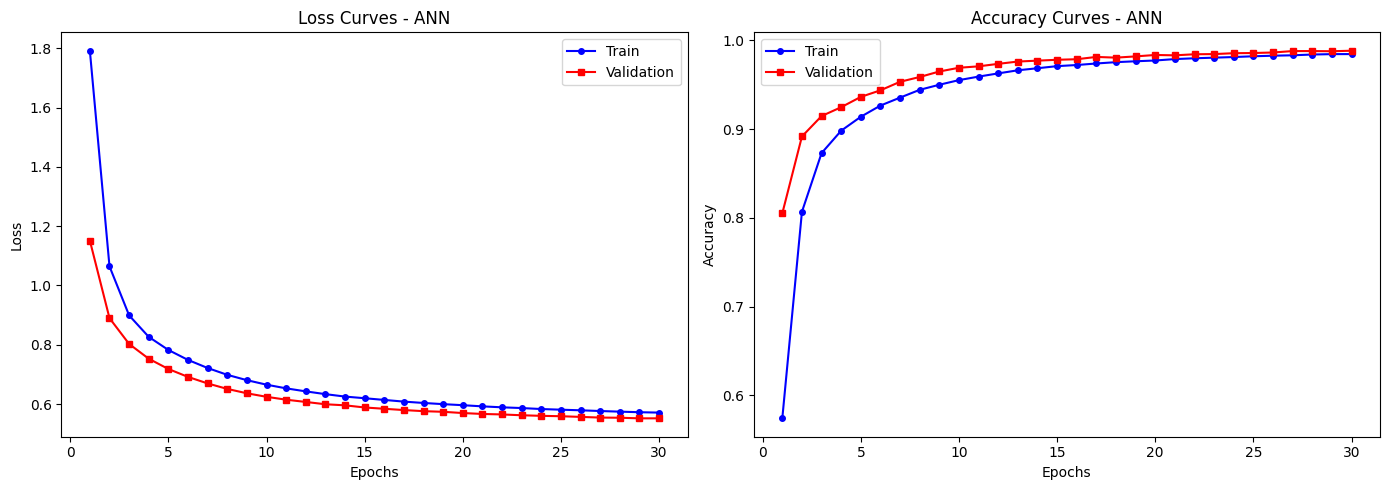


───────────────────────────────────────────────────────
  ANN
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    0 - zero      0.970     0.993     0.981       451
     1 - one      0.993     0.996     0.995       553
     2 - two      0.978     0.980     0.979       495
   3 - three      0.985     0.987     0.986       530
    4 - four      0.994     0.986     0.990       501
    5 - five      0.993     0.984     0.989       449
     6 - six      0.985     0.976     0.980       460
   7 - seven      0.978     0.987     0.982       531
   8 - eight      0.984     0.988     0.986       508
    9 - nine      0.986     0.967     0.977       522

    accuracy                          0.985      5000
   macro avg      0.985     0.985     0.985      5000
weighted avg      0.985     0.985     0.985      5000

  Macro F1: 0.9845

  Confusion Matrix: tensor([[448,   0,   0,   0,   0,   0,   1,   1,   1,   0],
        [  0, 551,   1

In [22]:
ANN_MODELS = {
    'ANN': (ANN(NUM_CLASSES), False),
   # 'ANNV2': (ANNV2(), False),
}

history_results_adam_w, evaluation_results_adam_w, results_adam_w = start_training_loop_adam_w(
    ANN_MODELS, train_dataloader,  a_val_dataloader, a_test_dataloader
)

In [23]:
ANN_RESULTS = results_adam_w


  Confusion Matrix: ANN


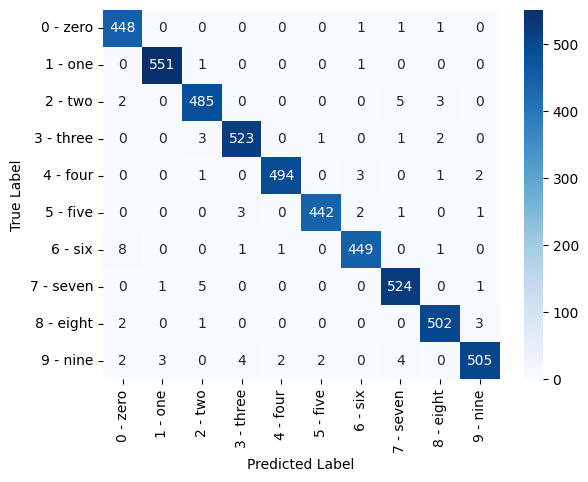

In [24]:
for model_name, er in evaluation_results_adam_w.items():
  print(f"\n{'='*60}")
  print(f"  Confusion Matrix: {model_name}")
  print(f"{'='*60}")
  plot_confusion_matrix(er, model_name)


In [25]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

# Predict using the model
def predict_(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy().flatten()


def predict(model, image, device):
    model.eval()

    # NumPy -> Tensor if necessary
    if isinstance(image, np.ndarray):
        image = torch.from_numpy(image)

    image = image.float()

    # (C, H, W) -> (1, C, H, W)
    if image.ndim == 3:
        image = image.unsqueeze(0)

    # (H, W) -> (1, 1, H, W)
    elif image.ndim == 2:
        image = image.unsqueeze(0).unsqueeze(0)

    image = image.to(device)

    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.softmax(outputs, dim=1)

    return probabilities.cpu().numpy().flatten()

# Visualization
def visualize_predictions(original_image, probabilities, class_names, real_class):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))

    # Display image
    axarr[0].imshow(original_image)
    axarr[0].axis("off")
    axarr[0].set_title(f"Real Class: {real_class}")

    # Display predictions
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()


# Visualization
def visualize_predictions_colored(original_image, probabilities, class_names, real_class):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))

    # --------------------------------------------------
    # Prepare image for matplotlib
    # --------------------------------------------------
    if isinstance(original_image, torch.Tensor):
        original_image = original_image.detach().cpu().squeeze().numpy()
    else:
        original_image = np.asarray(original_image).squeeze()

    # --------------------------------------------------
    # Prediction
    # --------------------------------------------------
    max_idx = np.argmax(probabilities)
    predicted_class = class_names[max_idx]

    is_correct = predicted_class == real_class
    title_color = "green" if is_correct else "red"

    # --------------------------------------------------
    # Left: Image
    # --------------------------------------------------
    axarr[0].imshow(original_image, cmap="gray")
    axarr[0].axis("off")

    axarr[0].set_title(
        f"Real: {real_class}\nPredicted: {predicted_class}",
        color=title_color,
        fontsize=14,
        fontweight="bold"
    )

    # --------------------------------------------------
    # Right: Bar chart
    # --------------------------------------------------
    bar_colors = []

    for i, cls in enumerate(class_names):
        prob = probabilities[i]

        if prob == 0:
            bar_colors.append("lightgray")

        elif cls == predicted_class:
            if predicted_class == real_class:
                bar_colors.append("green")
            else:
                bar_colors.append("red")

        elif cls == real_class:
            bar_colors.append("green")

        else:
            bar_colors.append("pink")

    bars = axarr[1].barh(
        class_names,
        probabilities,
        color=bar_colors
    )

    # Color y-axis labels
    for label in axarr[1].get_yticklabels():
        cls = label.get_text()

        if cls == real_class:
            label.set_color("green")
            label.set_fontweight("bold")

        elif cls == predicted_class and predicted_class != real_class:
            label.set_color("red")
            label.set_fontweight("bold")

    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    # Show probability values
    for bar, prob in zip(bars, probabilities):
        axarr[1].text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{prob:.2f}",
            va="center"
        )

    plt.tight_layout()
    plt.show()


def test_model(model, examples, transforms=None):
    for example in test_examples:
        original_image, image_tensor = preprocess_image(example, transforms)
        probabilities = predict(model, image_tensor, DEVICE)

        # Assuming dataset.classes gives the class names
        class_names = dataset.classes
        visualize_predictions_colored(original_image, probabilities, class_names, Path(example).parent.name)




#best_model = get_model_from_model_name(best_name)
best_model, _ = ANN_MODELS['ANN']
best_model.to(DEVICE)



ANN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)

Original image
label: 3


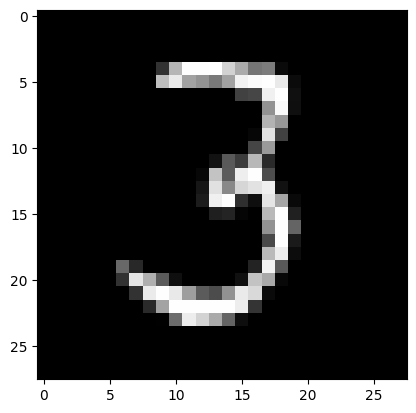

In [26]:
# Load a single image from the test set
index = 4373
input, label = a_test_dataset[index]
#input = torchvision.transforms.ToPILImage()(input)
#plt.imshow(input)
plt.imshow(input.squeeze().detach().cpu().numpy(), cmap="gray")
print('Original image')
print(f"label: {label}")
plt.show()

In [27]:
(a_test_dataset, a_test_dataset.dataset.classes)

(<torch.utils.data.dataset.Subset at 0x7b4e40747440>,
 ['0 - zero',
  '1 - one',
  '2 - two',
  '3 - three',
  '4 - four',
  '5 - five',
  '6 - six',
  '7 - seven',
  '8 - eight',
  '9 - nine'])

In [28]:
input, label = a_test_dataset[index]
label

3

True label: 3
Predicted label: 3


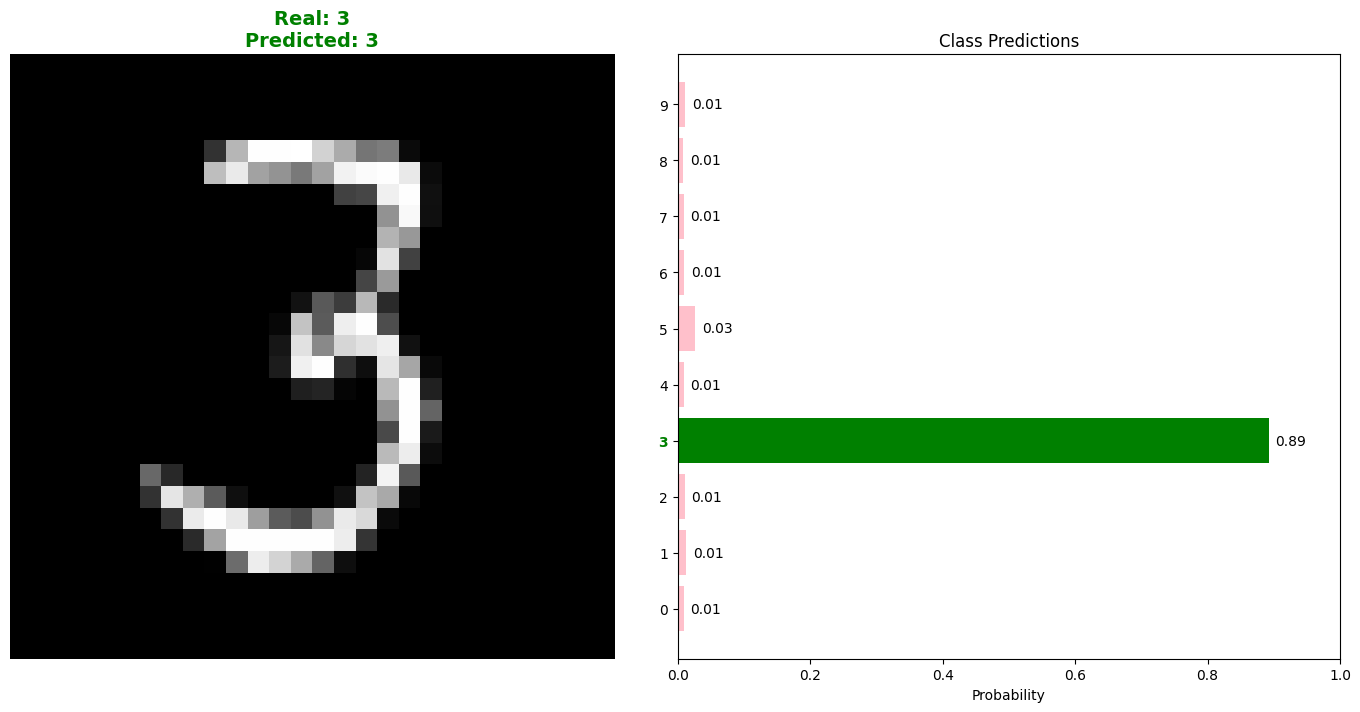

In [29]:
# Load a single image
index = 4373  # must be < 5000 if using your split test_dataset
input, label = a_test_dataset[index]

# Keep tensor shape: (1, 28, 28)
image_tensor = input

probabilities = predict(best_model, image_tensor, DEVICE)

print(f"True label: {label}")
print(f"Predicted label: {probabilities.argmax()}")

class_names = [str(i) for i in range(10)]# a_test_dataset.dataset.classes
visualize_predictions_colored(
    input,
    probabilities,
    class_names,
    str(label)
)

# SNN

In [30]:
from spikingjelly.activation_based import neuron, layer, functional, surrogate, encoding
import torch.nn as nn

class DirectSNN(nn.Module):
    """Same topology as the ANN: 2×Conv+Pool → FC 512 → FC 256 → FC 10.
    ReLU replaced by LIF; dropout omitted (or use layer.Dropout)."""

    def __init__(self, num_classes=10, tau=2.0):
        super().__init__()
        surr = surrogate.ATan()

        self.features = nn.Sequential(
            # Block 1  (matches ANN: 32 filters, 3×3, pool/2)
            layer.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False),
            neuron.LIFNode(tau=tau, surrogate_function=surr),
            layer.MaxPool2d(kernel_size=2),   # 28 → 14

            # Block 2  (matches ANN: 64 filters, 3×3, pool/2)
            layer.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            neuron.LIFNode(tau=tau, surrogate_function=surr),
            layer.MaxPool2d(kernel_size=2),   # 14 → 7
        )

        self.classifier = nn.Sequential(
            layer.Flatten(),
            # 64 * 7 * 7 = 3136  (for 28×28 input)
            layer.Linear(64 * 7 * 7, 512, bias=False),
            neuron.LIFNode(tau=tau, surrogate_function=surr),
            # optional: layer.Dropout(0.4)
            layer.Linear(512, 256, bias=False),
            neuron.LIFNode(tau=tau, surrogate_function=surr),
            layer.Linear(256, num_classes, bias=False),
            neuron.LIFNode(tau=tau, surrogate_function=surr),  # output spikes
        )

    def forward(self, x):
        # x: [N, 1, 28, 28]  or already spikes from encoder
        x = self.features(x)
        x = self.classifier(x)
        return x

In [31]:
# Define network architecture
class SNN(nn.Module):
    def __init__(self):
        super(SNN, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_1 = nn.Linear(in_features=28 * 28, out_features=10, bias=False)
        self.lif_layer_1 = neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan())

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear_1(x)
        x = self.lif_layer_1(x)
        # x = F.softmax(x, dim=0) #softmax activation layer is used for multivariate classification
        return x

# Instantiate neural network
snn = DirectSNN()
snn = snn.to(device) # Convert neural network

# Print neural network information
print ("Spiking Neural network information")
print(snn)

# Test the output format of the neural network
# Set the input that meets the requirements
input = torch.ones([1, 1, 28, 28])
input = input.to(device)
print ("Input data format", input.shape)

output = snn(input)
print ("Output data format", output.shape)

# View the size of the neural network model
summary(snn, input_size=[[1, 28, 28]])

# After optimizing the parameters once, you need to reset the state of the network, because SNN neurons have "memory”
functional.reset_net(snn)

Spiking Neural network information
DirectSNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (1): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (4): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1, step_mode=s)
    (1): Linear(in_features=3136, out_features=512, bias=False)
    (2): LIFNode(
      v_threshold=

In [32]:
# Set neural network hyperparameters
# Set the loss function
loss_fn = nn.CrossEntropyLoss()
loss_fn= loss_fn.to (device) # Convert the loss function

# Set up optimizer
learning_rate = 0.001 # Set the learning rate
lambda_val = 0.0 # Set the regularization coefficient Lambda
optim = torch.optim.AdamW(snn.parameters(), lr=learning_rate, weight_decay=lambda_val)

# Define input data encoder
encoder = encoding.PoissonEncoder()

# Set the simulation time T
T = 20

In [33]:
# Set the number of training rounds epoch and define the temporary parameters required during the training process
# Set the number of training rounds
epoch = 5
# Define the training set loss and accuracy variables
loss_train = 0.0 # Training loss value
loss_train_sum = 0.0 # Cumulative value of training loss value
loss_train_mean = 0.0 # The average value of the loss value of this round of training
loss_train_store = np.zeros(epoch) # Training loss value storage array
accuracy_train = 0 # Training accuracy
accuracy_rate_train = 0.0 # Training accuracy
accuracy_rate_train_max = 0.0 # Maximum training accuracy
accuracy_rate_train_store = np.zeros(epoch) # Training accuracy storage prime array
# Define cross-verification set loss and accuracy variables
loss_cv = 0.0 # Verify the loss value
loss_cv_sum = 0.0 # Verify the cumulative value of the loss value
loss_cv_mean = 0.0 # The average value of the loss value in this round of verification
loss_cv_store = np.zeros(epoch) # Verification loss value storage array
accuracy_cv = 0 # Verify the exact number
accuracy_rate_cv = 0.0 # Verification accuracy
accuracy_rate_cv_max = 0.0 # Maximum verification accuracy
accuracy_rate_cv_store = np.zeros(epoch) # Verify the accuracy of the stored prime array

In [34]:
# Training network

#########################Start training########################

for i in range(epoch):
    print("----------- %d round of training begins------------" % i)
    # The accumulated value of each round of loss is cleared to zero
    loss_train_sum = 0
    loss_cv_sum = 0
    # Start training neural network
    snn.train()
    # This round of training counts
    train_step = 0
    # Accuracy variable cleared
    accuracy_train = 0
    for data in train_dataloader:
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)
        label_onehot = F.one_hot(labels, 10).float() # Convert tags to independent thermal coding

        out_fr = 0. # Output neuron pulse emission rate
        #out_fr is the tensor of shape=[batch_size, 10]
        # Record the pulse emission rate of 10 neurons in the output layer during the entire simulation time
        for t in range(T):
            encoded_img = encoder(inputs) #First encode the input image into pulse data
            out_fr+=snn(encoded_img) # Accumulate the pulse output of 10 neurons in the output layer
        out_fr = out_fr /T # Divide by time to obtain the pulse emission rate of 10 neurons in the output layer
        # Calculate the loss function
        loss_train = F.mse_loss(out_fr, label_onehot)
        # The loss function is the pulse emission frequency of neurons in the output layer, which is the same as the MSE of the real category
        # Such a loss function will make: when the label i is given, the pulse emission frequency of the i-th neuron in the output layer approaches 1, while the pulse emission frequency of other neurons approaches 0
        # Cumulative loss function
        loss_train_sum += loss_train.item()
        # Convert the classification probability into the corresponding label
        pred_label = out_fr.argmax(1)
        # Accuracy of cumulative calculation results
        accuracy_train += (pred_label == labels).sum()
        # Clear the cumulative gradient of the optimizer
        optim.zero_grad()
        # Calculate gradient
        loss_train.backward()
        # The optimizer starts to optimize
        optim.step()

        # After optimizing the parameters once, you need to reset the state of the network, because SNN neurons have "memory”
        functional.reset_net(snn)

    # Calculate the average training set loss
    loss_train_mean = loss_train_sum / (train_dataset_size / batch_size)
    loss_train_store[i] = loss_train_mean # Store the loss for plotting the loss curve later
    # Calculate training set accuracy
    accuracy_rate_train = (accuracy_train / train_dataset_size) * 100
    accuracy_rate_train_store[i] = accuracy_rate_train


    # Start testing the neural network
    snn.eval()
    # Test step counter for this round
    test_step = 0
    # Reset the accuracy variable
    accuracy_cv = 0
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)
            label_onehot = F.one_hot(labels, 10).float()
            out_fr = 0.0
            for t in range(T):
                encoded_img = encoder(inputs)
                # Feed into the neural network and run
                out_fr += snn(encoded_img)
            out_fr = out_fr / T
            # Compute the loss function
            loss_cv = F.mse_loss(out_fr, label_onehot)
            # Accumulate the loss function
            loss_cv_sum += loss_cv.item()
            # Convert the classification probability to the corresponding label
            pred_label = out_fr.argmax(1)
            # Accumulate accuracy
            accuracy_cv += (pred_label == labels).sum()
            test_step += 1
            # After each parameter optimization, the network’s state must be reset because SNN neurons have “memory”
            functional.reset_net(snn)

        # Calculate the cross-validation set loss (loss_cv)
        loss_cv_mean = loss_cv_sum / (test_dataset_size / batch_size)
        loss_cv_store[i] = loss_cv_mean # Record the loss for later plotting of the loss curve
        # Calculate the cross-validation accuracy
        accuracy_rate_cv = (accuracy_cv / test_dataset_size) * 100
        accuracy_rate_cv_store[i] = accuracy_rate_cv

    # Print the results of this training round
    print(f"loss train: {loss_train_mean: .4f}, accuracy rate train: {accuracy_rate_train.item(): .4f}%, loss cv: {loss_cv_mean: .4f}, accuracy rate cv: {accuracy_rate_cv.item(): .4f}%")
    # Automatically save neural network models whose accuracy during training exceeds that of previous models

    if (accuracy_rate_train + accuracy_rate_cv > accuracy_rate_train_max + accuracy_rate_cv_max):
        torch.save(snn, model_auto_save_dir + "model_auto_save_acc%d.pth" %accuracy_rate_cv)
        accuracy_rate_train_max = accuracy_rate_train  # Record the maximum training accuracy
        accuracy_rate_cv_max = accuracy_rate_cv  # Record the maximum validation accuracy

######################### End of Training########################
print('-------------------------------Training Complete-------------------------------')

----------- 0 round of training begins------------
loss train:  0.0230, accuracy rate train:  82.1167%, loss cv:  0.0041, accuracy rate cv:  97.6400%
----------- 1 round of training begins------------
loss train:  0.0032, accuracy rate train:  98.1183%, loss cv:  0.0024, accuracy rate cv:  98.7000%
----------- 2 round of training begins------------
loss train:  0.0020, accuracy rate train:  98.8950%, loss cv:  0.0023, accuracy rate cv:  98.5300%
----------- 3 round of training begins------------
loss train:  0.0016, accuracy rate train:  99.0833%, loss cv:  0.0016, accuracy rate cv:  99.0800%
----------- 4 round of training begins------------
loss train:  0.0012, accuracy rate train:  99.2917%, loss cv:  0.0017, accuracy rate cv:  98.9300%
-------------------------------Training Complete-------------------------------


---------Graph showing how the loss function changes over training epochs---------


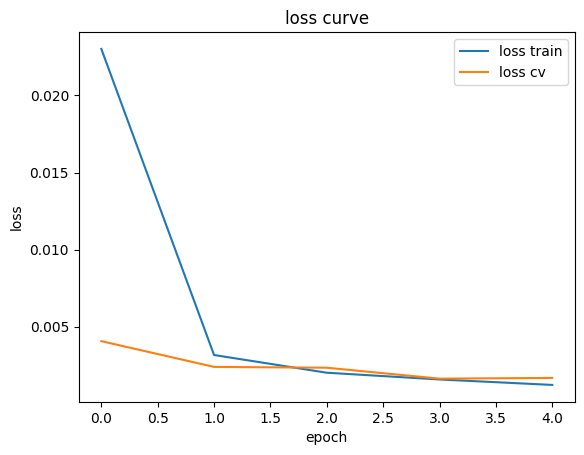

---------Graph showing how accuracy changes over training epochs---------


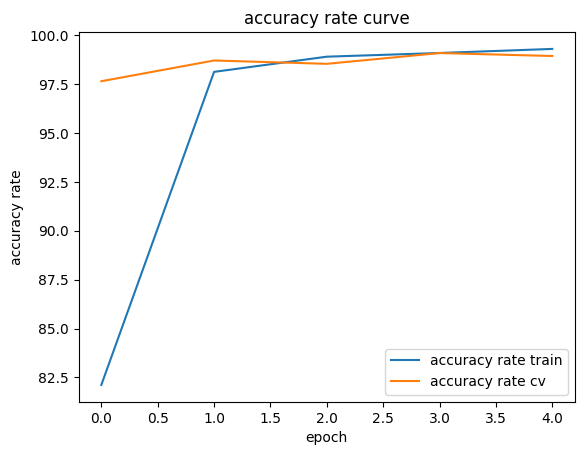

In [35]:
# Plot the loss curve
print('---------Graph showing how the loss function changes over training epochs---------')
plt.plot(np.arange(epoch), loss_train_store, np.arange(epoch), loss_cv_store)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(["loss train", 'loss cv'])
plt.title('loss curve')
plt.show()

# Plot the accuracy curve
print('---------Graph showing how accuracy changes over training epochs---------')
plt.plot(np.arange(epoch), accuracy_rate_train_store, np.arange(epoch), accuracy_rate_cv_store)
plt.xlabel('epoch')
plt.ylabel('accuracy rate')
plt.legend(["accuracy rate train", "accuracy rate cv"])
plt.title('accuracy rate curve')
plt.show()

In [36]:
# Next, let’s run the inference process separately and output the results every 100 iterations.
# Load a model from a specific training round for prediction
# net = torch.load(“model_save/auto_save/model_auto_save_acc95.pth”)
# net = torch.load(“module_save/history_save/module_save_acc63.pth”)

# Start making predictions with the neural network
snn.eval()
# Total number of test steps
test_step = 0
# Track accuracy
accuracy = 0
with torch.no_grad(): # No gradient descent during the prediction phase
    for data in test_dataloader:
        inputs, labels = data
        inputs = inputs.to(device) # Convert the data
        labels = labels.to(device) # Convert data
        label_onehot = F.one_hot(labels, 10).float()
        out_fr = 0.0
        for t in range(T):
            encoded_img = encoder(inputs)
            out_fr += snn(encoded_img)
        out_fr = out_fr / T
        # Convert classification probabilities to corresponding labels
        pred_label = out_fr.argmax(1)
        # Output results every 100 iterations
        if (test_step % 100 == 0):
            print('Output result', pred_label)
            print('Original labels', labels)
        # Accumulate accuracy
        accuracy += (pred_label == labels).sum()
        test_step += 1

        # After each parameter optimization, the network’s state must be reset because SNN neurons have “memory”
        functional.reset_net(snn)

accuracy_rate = accuracy / test_dataset_size
print('Number of correct predictions:', accuracy.item(), 'Total test cases:', test_dataset_size)
print("Model accuracy: %.2f%%" % (accuracy_rate.item() * 100))


Output result tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 8, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3], device='cuda:0')
Original labels tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3], device='cuda:0')
Output result tensor([0, 9, 6, 8, 8, 5, 6, 1, 1, 9, 8, 9, 2, 3, 5, 5, 9, 4, 2, 1, 9, 3, 9, 2,
        0, 6, 0, 4, 0, 0, 1, 2, 3, 4, 7, 8, 9, 0, 1, 2, 3, 7, 8, 9, 0, 1, 2, 3,
        4, 7, 8, 9, 7, 3, 0, 3, 1, 8, 7, 6, 4, 0, 2, 6], device='cuda:0')
Original labels tensor([0, 9, 6, 8, 8, 5, 6, 1, 1, 9, 8, 9, 2, 3, 5, 5, 9, 4, 2, 1, 9, 3, 9, 2,
        0, 6, 0, 4, 0, 0, 1, 2, 3, 4, 7, 8, 9, 0, 1, 2, 3, 7, 8, 9, 0, 1, 2, 3,
        4, 7, 8, 9, 7, 3, 0, 3, 1, 8, 7, 6, 4, 0, 2, 6], device='cuda:0')
Numb

In [37]:
x= SNN()

In [38]:
#summary(x, input_size=[[1, 28, 28]])

In [39]:
snn.classifier[6]

LIFNode(
  v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
  (surrogate_function): ATan(alpha=2.0, spiking=True)
)

In [40]:
img, label = test_dataset[3373]

img = img.to(DEVICE)

# [C, H, W] -> [N, C, H, W]
if img.dim() == 3:
    img = img.unsqueeze(0)

print("img:", img.shape)
print("img device:", img.device)

encoded_img = encoder(img)

print("encoded:", encoded_img.shape)
print("encoded device:", encoded_img.device)

x = snn.features(encoded_img)

print("features:", x.shape)

x = snn.classifier[0](x)

print("flatten:", x.shape)

img: torch.Size([1, 1, 28, 28])
img device: cuda:0
encoded: torch.Size([1, 1, 28, 28])
encoded device: cuda:0
features: torch.Size([1, 64, 7, 7])
flatten: torch.Size([1, 3136])


Original image
label: 7


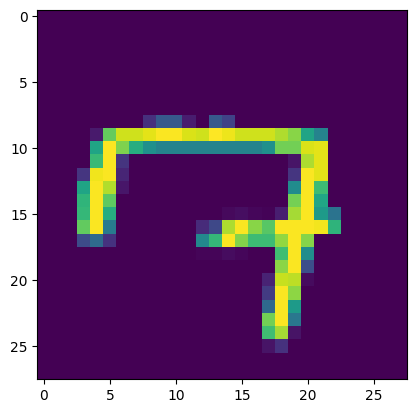

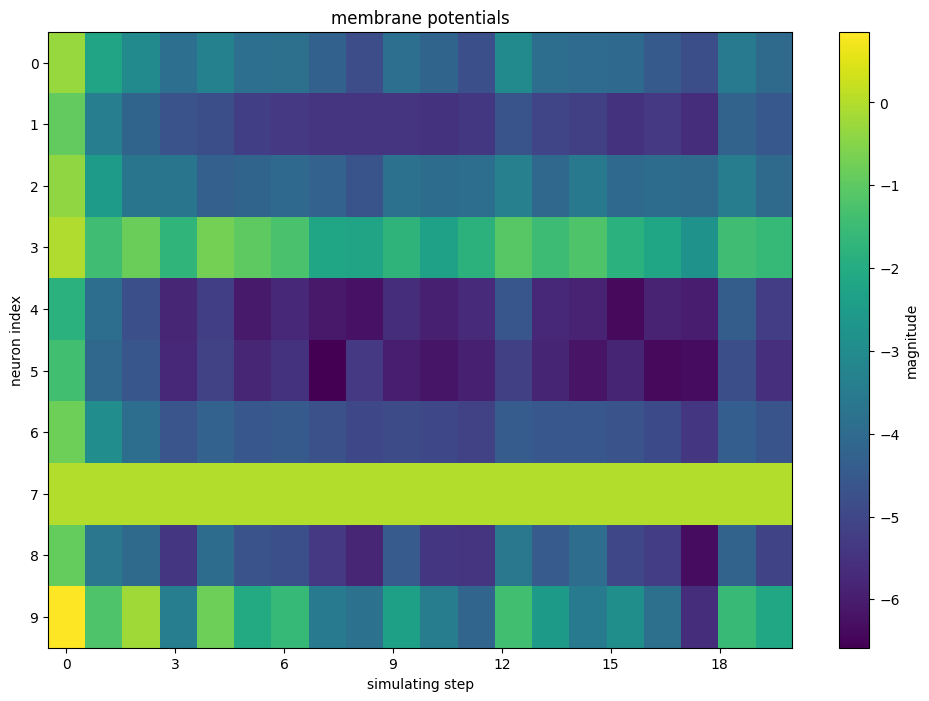

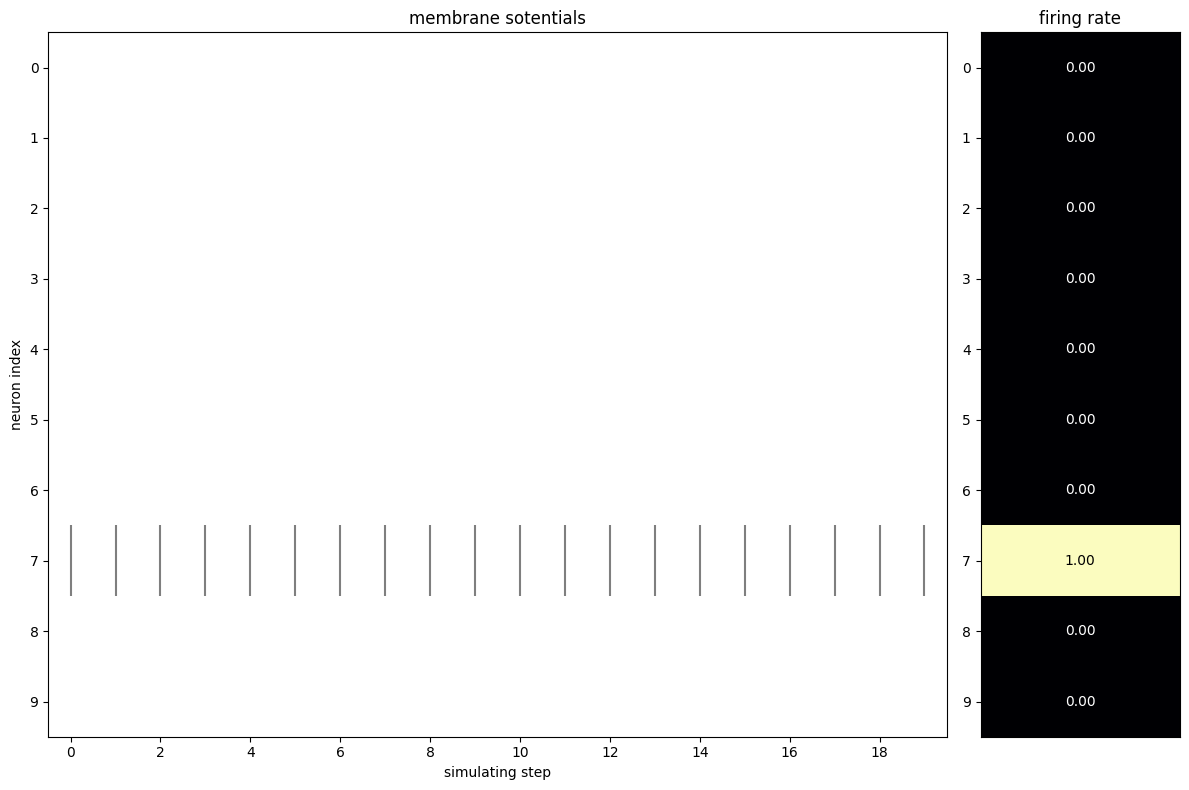

In [41]:
#For a more intuitive understanding, we can select a single image for prediction; by changing the index, we can choose different input images.

# Obtaining the membrane potential of the output layer neurons at this point is somewhat challenging and requires the use of the “hook” feature.

# Retrieve a single image for prediction

# Load the raw data
# Load a single image from the test set
# Save the data for plotting
snn.eval()
functional.reset_net(snn)
# Register a hook
output_layer = snn.classifier[6] # snn.lif_layer_1 # Output layer
output_layer.v_seq = []
output_layer.s_seq = []
def save_hook(m, x, y):
    m.v_seq.append(m.v.unsqueeze(0))
    m.s_seq.append(y.unsqueeze(0))

hook = output_layer.register_forward_hook(save_hook)

# Load a single image from the test set
index = 3373
input, label = test_dataset[index]
input = torchvision.transforms.ToPILImage()(input)
plt.imshow(input)
print('Original image')
print(f"label: {label}")
plt.show()

# Start making predictions with the neural network
snn.eval()

with torch.no_grad():
    img, label = test_dataset[index]
    img = img.unsqueeze(0).to(device)
    out_fr = 0.
    for t in range(T):
        encoded_img = encoder(img)
        out_fr += snn(encoded_img)
    out_spikes_counter_frequency = (out_fr / T).cpu().numpy()

    output_layer.v_seq = torch.cat(output_layer.v_seq)
    output_layer.s_seq = torch.cat(output_layer.s_seq)
    v_t_array = output_layer.v_seq.cpu().numpy().squeeze()  # v_t_array[i][j] represents the voltage value of neuron i at time j
    s_t_array = output_layer.s_seq.cpu().numpy().squeeze()  # s_t_array[i][j] represents the spike fired by neuron i at time j, which is either 0 or 1

    # Heatmap of membrane potentials and spike output results
    figsize = (12, 8)
    dpi = 100
    visualizing.plot_2d_heatmap(array=v_t_array, title='membrane potentials', xlabel='simulating step',
                                ylabel='neuron index', int_x_ticks=True, x_max=T, figsize=figsize, dpi=dpi)
    visualizing.plot_1d_spikes(spikes=s_t_array, title='membrane sotentials', xlabel='simulating step',
                            ylabel='neuron index', figsize=figsize, dpi=dpi)

    plt.show()

hook.remove()

In [42]:
# Save the spiking neural network model
torch.save(snn, model_history_save_dir + "module_save_acc.pth")
print('Model saved')

Model saved


In [43]:
# View spiking network parameters
print(snn)
snn.named_parameters()
for name, param in snn.named_parameters(prefix="SNN"):
    print(name, param)
    print(name, param.size())

DirectSNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (1): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (4): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1, step_mode=s)
    (1): Linear(in_features=3136, out_features=512, bias=False)
    (2): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=Fals

# ANN2SNN

## Conversion

In [44]:
import spikingjelly.activation_based.ann2snn as ann2snn
import inspect

print("=== ann2snn ===")
print(dir(ann2snn))

print("\n=== converter ===")
print(dir(ann2snn.converter))

print("\n=== modules ===")
print(dir(ann2snn.modules))

print("\n=== utils ===")
print(dir(ann2snn.utils))


=== ann2snn ===
['ChannelVoltageScaler', 'ConversionRecipe', 'Converter', 'FXConversionRecipe', 'FXConverter', 'LocalThresholdBalancingRecipe', 'ModuleConversionRecipe', 'ModuleConverter', 'Qwen2SNNCalibration', 'Qwen2SNNConfig', 'Qwen2SNNModel', 'Qwen2SNNRecipe', 'RateCodingRecipe', 'STATransformerRecipe', 'SignedQCFSSequenceEncoder', 'SpikeZIPTFQANNRecipe', 'TransformerTDEquivalentRecipe', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'calibrate_qwen2_snn', 'converter', 'delay', 'download_url', 'estimate_delay_start', 'modules', 'operators', 'qcfs', 'recipes', 'utils']

=== converter ===
['Converter', 'FXConversionRecipe', 'FXConverter', 'ModuleConversionRecipe', 'ModuleConverter', 'Optional', 'TransformerTDEquivalentRecipe', 'Union', '_FX_TRACE_LOCK', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_resolve_device', '_symbolic_trace', 'fx', 'l

In [45]:
torch.random.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)
#dataset_dir = "./data/mnist"
batch_size = 100
TT = 50

In [46]:
calibration_data_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=False, drop_last=False
)


In [47]:
from spikingjelly.activation_based import ann2snn

recipe = ann2snn.RateCodingRecipe(
    dataloader=calibration_data_loader,
    mode="max",
)
conv_snn_max = ann2snn.FXConverter(recipe).convert(best_model)

100%|██████████| 600/600 [00:06<00:00, 92.06it/s]


In [48]:
recipe = ann2snn.RateCodingRecipe(
    dataloader=calibration_data_loader,
    mode="99.9%",
)
conv_snn_99 = ann2snn.FXConverter(recipe).convert(best_model)

100%|██████████| 600/600 [00:07<00:00, 83.11it/s]


## Accuracy vs Timesteps

In [49]:
@torch.no_grad()
def accuracy_vs_T_(model, loader, T_max, device):
    model.eval()
    correct = torch.zeros(T_max); total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        functional.reset_net(model)
        acc, preds = 0., []
        for t in range(T_max):
            acc = acc + model(x)
            preds.append(acc.argmax(1))          # prediction using spikes up to t
        for t in range(T_max):
            correct[t] += (preds[t] == y).sum().item()
        total += y.size(0)
    return (100.0 * correct / total).tolist()

# curve = accuracy_vs_T_(snn, a_test_dataloader, T_max=64, device=device)
# plot curve against range(1, 65): x=timesteps (latency), y=accuracy

curve_max  = accuracy_vs_T_(conv_snn_max,  a_test_dataloader, T_max=64, device=device)
curve_99 = accuracy_vs_T_(conv_snn_99, a_test_dataloader, T_max=64, device=device)
curve_base_snn = accuracy_vs_T_(snn, a_test_dataloader, T_max=64, device=device)

## Plot Trace Neuron

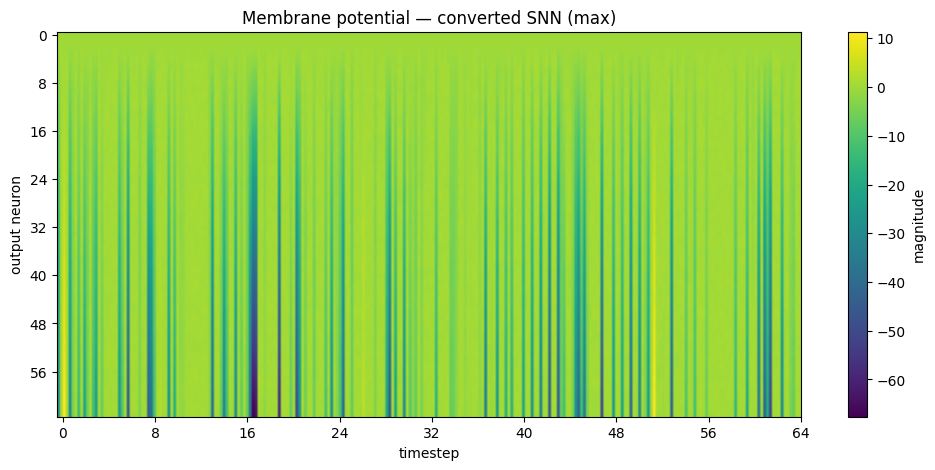

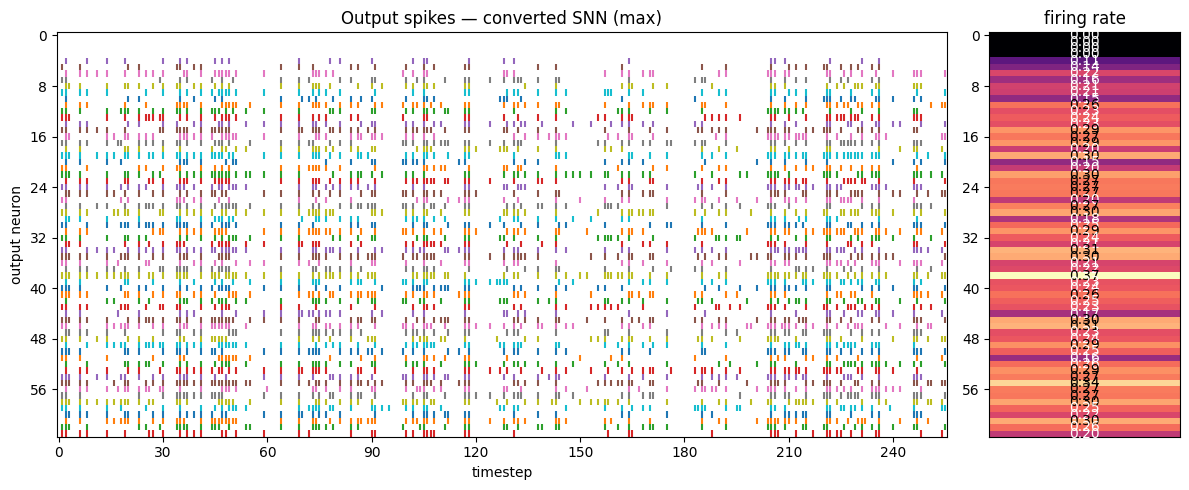

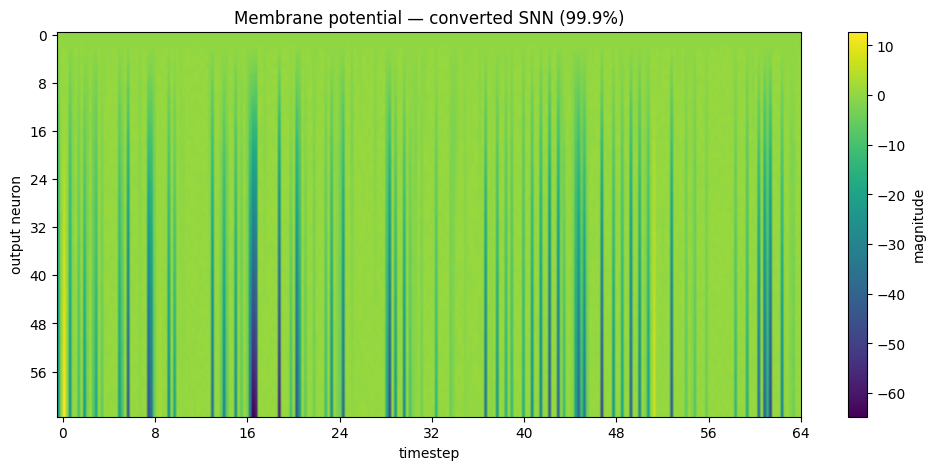

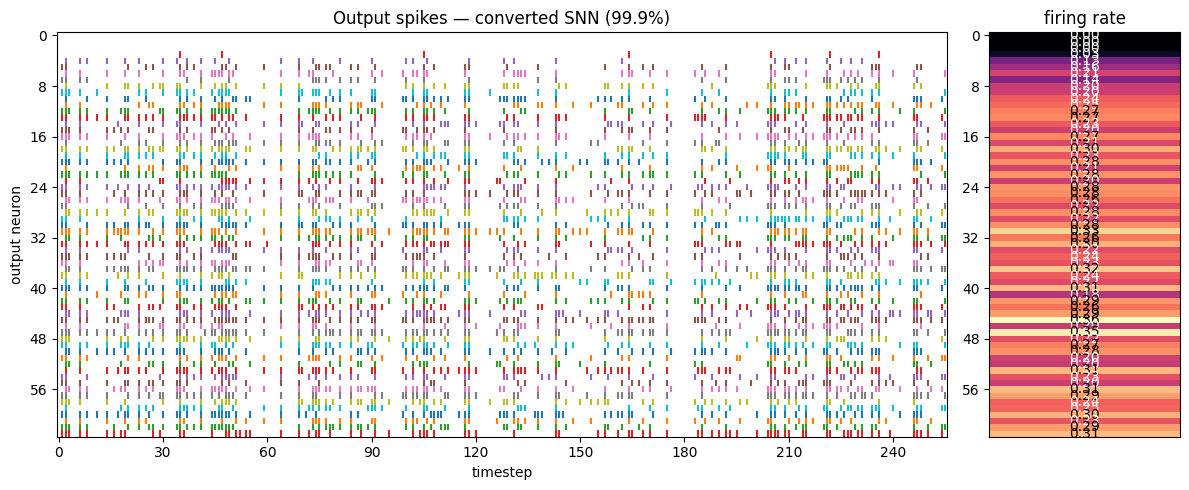

In [50]:

def trace_neuron(model, node, img, T, device):
    """Record membrane potential v and spikes of one IF node over T steps."""
    model = model.to(device).eval()
    v_seq, s_seq = [], []

    def hook(m, x, y):
        v_seq.append(m.v.detach().float().cpu().unsqueeze(0))   # membrane BEFORE reset
        s_seq.append(y.detach().float().cpu().unsqueeze(0))     # output spikes (0/1)

    h = node.register_forward_hook(hook)
    functional.reset_net(model)
    with torch.no_grad():
        x = img.unsqueeze(0).to(device)      # [1,1,28,28] — converted model takes analog input
        for _ in range(T):
            model(x)                            # feed analog image each step; IF accumulates
    functional.reset_net(model)
    h.remove()

    v = torch.cat(v_seq).numpy().squeeze()    # [T, n_neurons]
    s = torch.cat(s_seq).numpy().squeeze()
    return v.T, s.T                           # transpose -> [neuron, step] for the plotters


# grab the final spiking layer of each converted model
node_max = conv_snn_max.get_submodule("classifier.spiking_1.if_node")
node_99  = conv_snn_99.get_submodule("classifier.spiking_1.if_node")

img, label = a_test_dataset[3373]
T = 64

for tag, s_net, node in [("max", conv_snn_max, node_max), ("99.9%", conv_snn_99, node_99)]:
    v_arr, s_arr = trace_neuron(s_net, node, img, T, device)
    visualizing.plot_2d_heatmap(array=v_arr, title=f"Membrane potential — converted SNN ({tag})",
                                xlabel="timestep", ylabel="output neuron",
                                int_x_ticks=True, x_max=T, figsize=(12, 5), dpi=100)
    visualizing.plot_1d_spikes(spikes=s_arr, title=f"Output spikes — converted SNN ({tag})",
                               xlabel="timestep", ylabel="output neuron", figsize=(12, 5), dpi=100)
    plt.show()

In [51]:
def try_visualize_converted(model, dataset, T, index=3373, device='cuda'):
    model.eval()
    functional.reset_net(model)

    # Locate the last IFNode that produces the 10-class spikes
    # (for the structure you printed it is classifier.spiking_1.if_node)
    output_neuron = None
    for name, module in model.named_modules():
        if isinstance(module, neuron.IFNode) or isinstance(module, neuron.LIFNode):
            output_neuron = module   # keep the last one we encounter
    if output_neuron is None:
        raise RuntimeError("No IFNode / LIFNode found in the model")

    # Storage for membrane potential and spikes
    output_neuron.v_seq = []
    output_neuron.s_seq = []

    def save_hook(m, x, y):
        # m.v is the membrane potential *after* the current step
        # y is the spike tensor
        output_neuron.v_seq.append(m.v.detach().unsqueeze(0))
        output_neuron.s_seq.append(y.detach().unsqueeze(0))

    hook = output_neuron.register_forward_hook(save_hook)

    # Load one sample
    img, label = dataset[index]
    print(f"Original label: {label}")
    plt.imshow(torchvision.transforms.ToPILImage()(img), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

    with torch.no_grad():
        x = img.unsqueeze(0).to(device)          # [1, 1, 28, 28]
        out_fr = 0.
        for t in range(T):
            out_fr += model(x)                   # rate-coding style accumulation
        out_fr = out_fr / T
        pred = out_fr.argmax(1).item()
        print(f"Predicted class (rate coding, T={T}): {pred}")

        # Concatenate recorded sequences
        if len(output_neuron.v_seq) == 0:
            raise RuntimeError("Hook collected no data – check that the correct neuron was selected")
        v_t_array = torch.cat(output_neuron.v_seq).cpu().numpy().squeeze()  # [T, 10]
        s_t_array = torch.cat(output_neuron.s_seq).cpu().numpy().squeeze()  # [T, 10]

        # Visualise
        figsize = (12, 8)
        dpi = 100
        visualizing.plot_2d_heatmap(
            array=v_t_array,
            title='Membrane potentials (output layer)',
            xlabel='simulating step',
            ylabel='neuron index',
            int_x_ticks=True,
            x_max=T,
            figsize=figsize,
            dpi=dpi
        )
        visualizing.plot_1d_spikes(
            spikes=s_t_array,
            title='Output spikes',
            xlabel='simulating step',
            ylabel='neuron index',
            figsize=figsize,
            dpi=dpi
        )
        plt.show()

    hook.remove()
    functional.reset_net(model)

Original label: 7


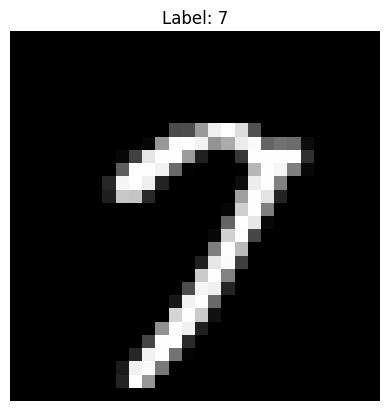

Predicted class (rate coding, T=16): 7


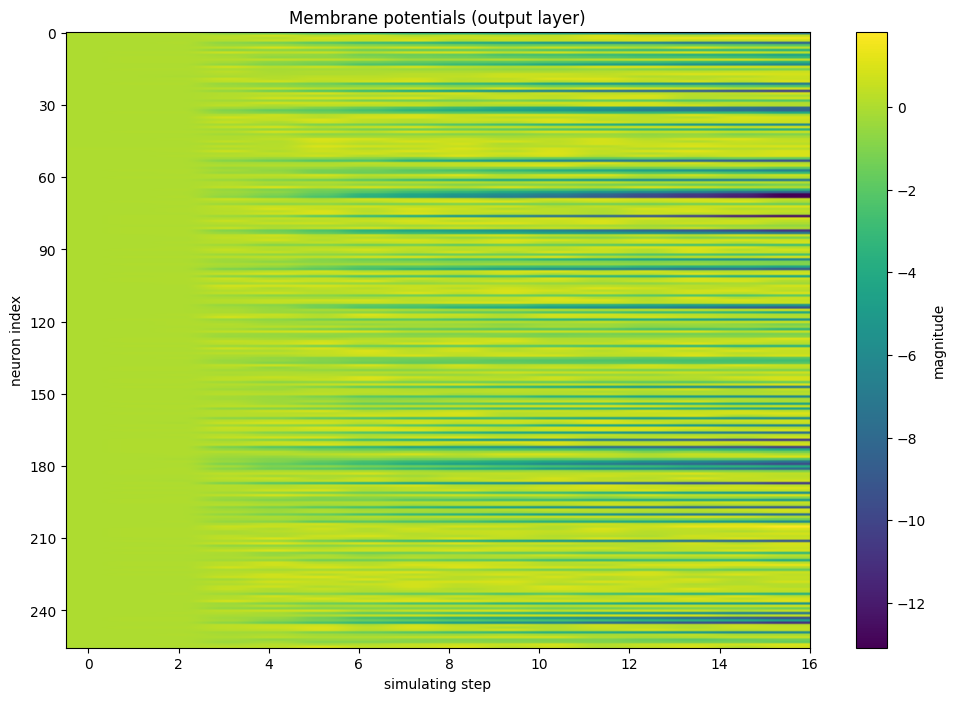

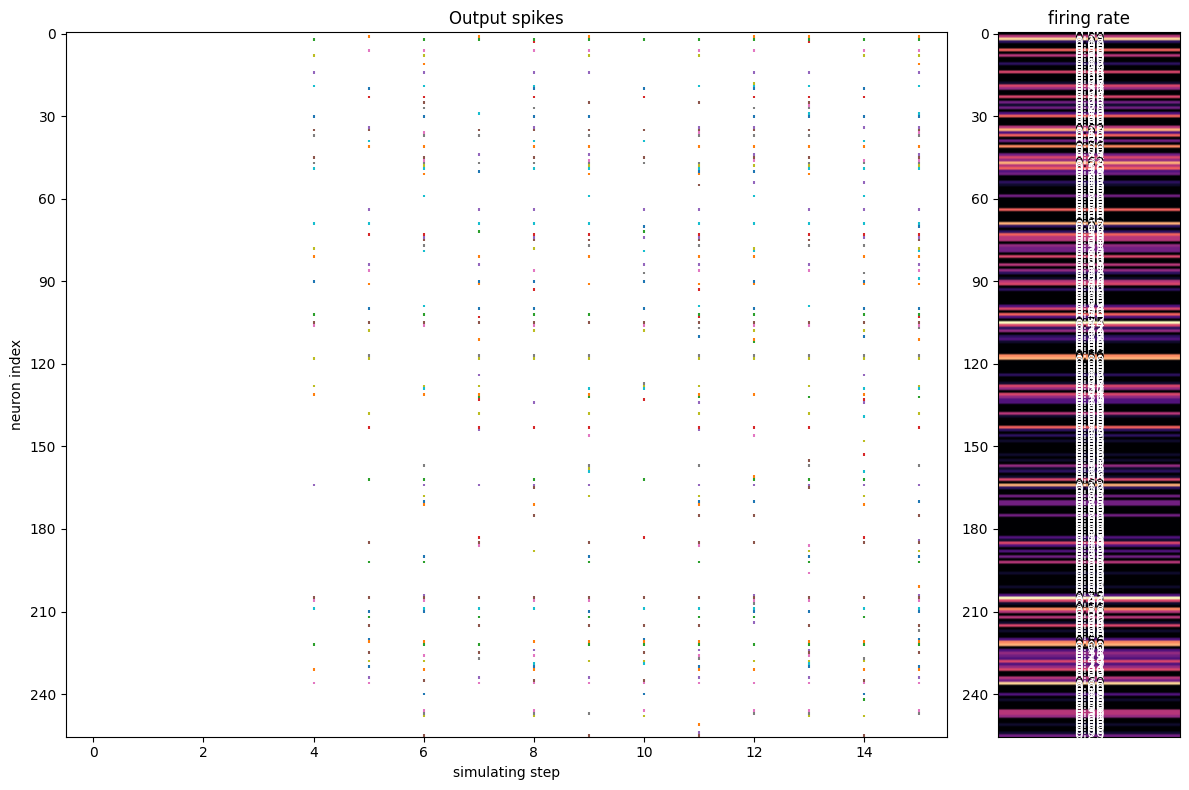

Original label: 7


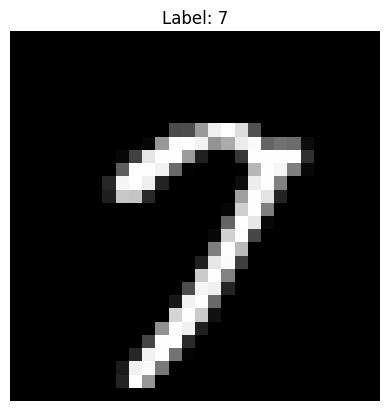

Predicted class (rate coding, T=16): 7


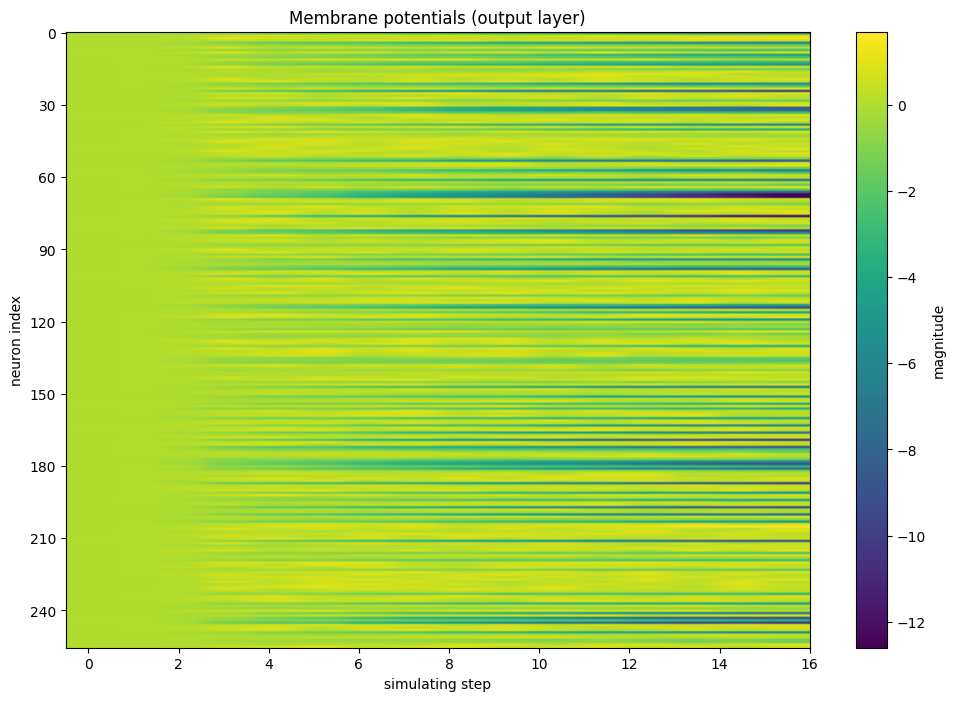

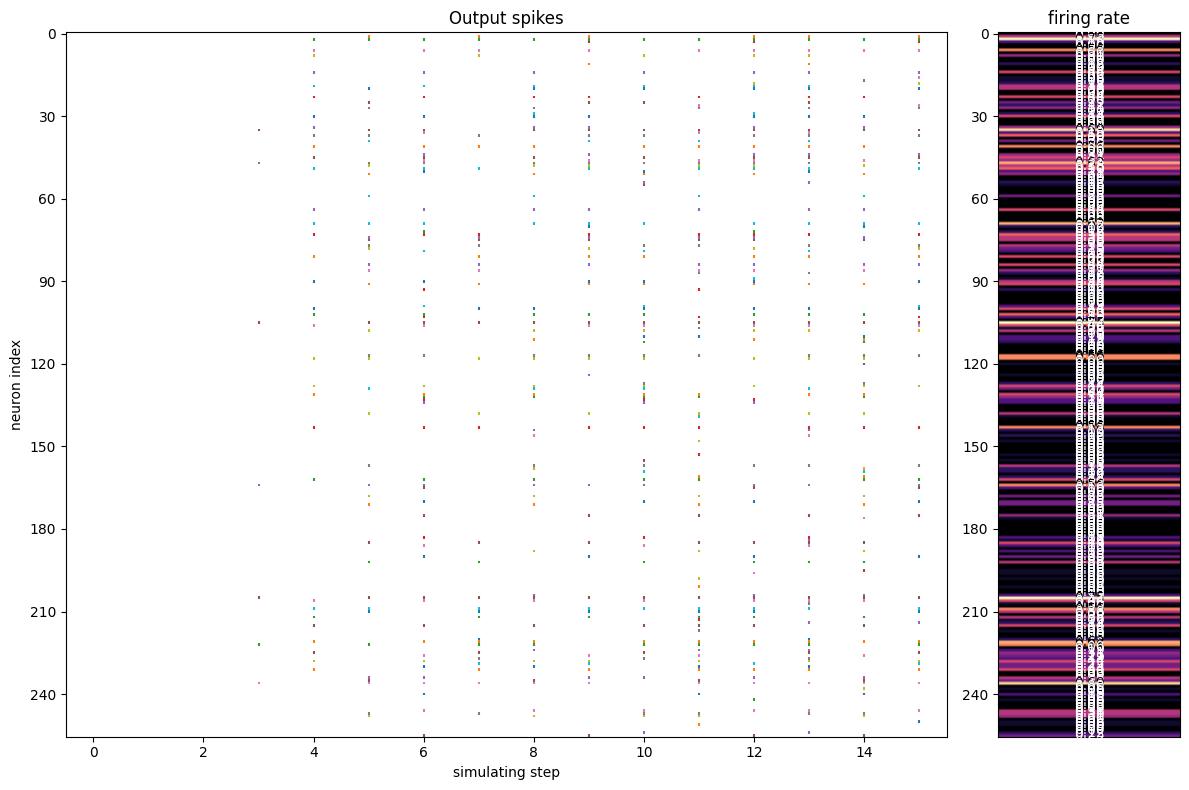

In [52]:
try_visualize_converted(conv_snn_max, a_test_dataset, T=16, index=3373, device=device)
try_visualize_converted(conv_snn_99, a_test_dataset, T=16, index=3373, device=device)

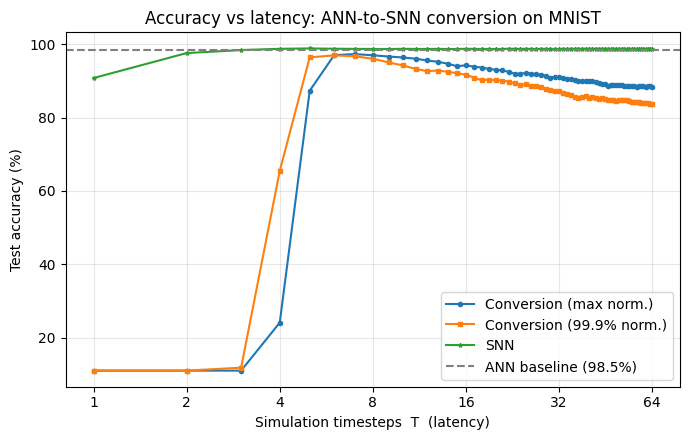

In [53]:
import matplotlib.pyplot as plt



T = range(1, 65)                      # x-axis: timesteps 1..64
ann_acc = ANN_RESULTS['ANN'].accuracy * 100                       # your ANN baseline for reference

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(T, curve_max,  marker="o", ms=3, label='Conversion (max norm.)')
ax.plot(T, curve_99, marker="s", ms=3, label='Conversion (99.9% norm.)')
ax.plot(T, curve_base_snn, marker="*", ms=3, label='SNN')
ax.axhline(ann_acc, ls="--", color="grey", label=f'ANN baseline ({ann_acc:.1f}%)')

ax.set_xlabel("Simulation timesteps  T  (latency)")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Accuracy vs latency: ANN-to-SNN conversion on MNIST")
ax.set_xscale("log", base=2)          # timesteps span 1..64 — log base-2 spreads them out
ax.set_xticks([1, 2, 4, 8, 16, 32, 64]) ## [2**i for i in range(int(math.log2(T_max)) + 1)]
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())   # show 1,2,4.. not 2^0,2^1
ax.grid(alpha=.3)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("accuracy_vs_latency.png", dpi=150)
plt.show()

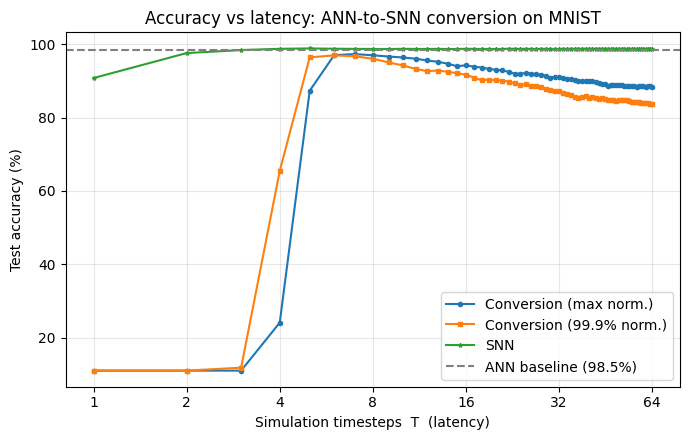

In [54]:
import matplotlib.pyplot as plt



T = range(1, 65)                      # x-axis: timesteps 1..64
ann_acc = ANN_RESULTS['ANN'].accuracy * 100                       # your ANN baseline for reference

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(T, curve_max,  marker="o", ms=3, label='Conversion (max norm.)')
ax.plot(T, curve_99, marker="s", ms=3, label='Conversion (99.9% norm.)')
ax.plot(T, curve_base_snn, marker="*", ms=3, label='SNN')
ax.axhline(ann_acc, ls="--", color="grey", label=f'ANN baseline ({ann_acc:.1f}%)')

ax.set_xlabel("Simulation timesteps  T  (latency)")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Accuracy vs latency: ANN-to-SNN conversion on MNIST")
ax.set_xscale("log", base=2)          # timesteps span 1..64 — log base-2 spreads them out
ax.set_xticks([1, 2, 4, 8, 16, 32, 64]) ## [2**i for i in range(int(math.log2(T_max)) + 1)]
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())   # show 1,2,4.. not 2^0,2^1
ax.grid(alpha=.3)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("accuracy_vs_latency.png", dpi=150)
plt.show()

# Analytical Estimation

Lemaire argues tha simply counting the synaptic operations is insufficient. their metric includes:

$$
E
=
E_{\mathrm{mem}}
+
E_{\mathrm{ops+addr}}
$$

Energy comes from
- memory accesses
- synaptic operations
- addressing operations


Th memory model additionally considers reads/writes associated with:
- input data
- parameters/weights
- membrane potentials
- outputs

For SNNs, membrane potentials introduce additional memory operations, while sparse spike activity can reduce weight and input/output accesss

## Level 1: Computational activity (what the network is doing)


This is the "MACs / ACCs" part of Level 1. [Davidson & Furber] , checks the spikes, MACs/ACCs, rates, timesteps.

spikes_per_neuron_per_inference < 1.72 is the theoretical indicator of possible energy advantage under the analytical assumptions.

Measure the:
- input spikes
- output spikes
- spikes per layer
- total spikes
- spike rate
- timesteps







In [55]:
!pip install pynvml
!pip install psutil

In [56]:
from __future__ import annotations
 
import math
import time
import threading
import copy
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
 
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from spikingjelly.activation_based import neuron, functional
 
try:
    import psutil
    _HAS_PSUTIL = True
except Exception:
    _HAS_PSUTIL = False
 
try:
    import pynvml
    pynvml.nvmlInit()
    _NVML = pynvml.nvmlDeviceGetHandleByIndex(0)
    _HAS_NVML = True
except Exception:
    _NVML = None
    _HAS_NVML = False
 
 
# ENERGY CONSTANTS  
E_ADD_INT32  = 0.1e-12
E_MULT_INT32 = 3.1e-12
E_ADD_FP32   = 0.9e-12
E_MULT_FP32  = 3.7e-12
 
_SRAM_POINTS = [(8.0, 10e-12), (32.0, 20e-12), (1024.0, 100e-12)]  # (kB, J)
BYTES_PER_WORD = 4
 
 
def sram_access_energy(size_kB: float) -> float:
    """Piecewise-linear SRAM access energy vs memory size (Lemaire's method).
    E_read == E_write by assumption."""
    pts = _SRAM_POINTS
    if size_kB <= pts[0][0]:
        return pts[0][1]
    for (x0, y0), (x1, y1) in zip(pts[:-1], pts[1:]):
        if size_kB <= x1:
            return y0 + (y1 - y0) * (size_kB - x0) / (x1 - x0)
    (x0, y0), (x1, y1) = pts[-2], pts[-1]
    return y1 + (y1 - y0) * (size_kB - x1) / (x1 - x0)
 
 
@dataclass
class EnergyModel:
    e_add: float = E_ADD_INT32
    e_mult: float = E_MULT_INT32
    label: str = "int32"
 
    @property
    def e_acc(self) -> float:
        return self.e_add
 
    @property
    def e_mac(self) -> float:
        return self.e_add + self.e_mult
 
 
INT32_MODEL = EnergyModel(E_ADD_INT32, E_MULT_INT32, "int32")
FP32_MODEL  = EnergyModel(E_ADD_FP32,  E_MULT_FP32,  "fp32")
 
 
# TOPOLOGY
SYNAPTIC_TYPES = (nn.Conv2d, nn.Linear)
NEURON_TYPES   = (neuron.BaseNode,)
 
 
@dataclass
class LayerSpec:
    name: str
    kind: str # 'conv' | 'fc'
    exec_order: int
    has_bias: bool
 
    Cin: int = 0; Hin: int = 0; Win: int = 0
    Cout: int = 0; Hout: int = 0; Wout: int = 0
    Hk: int = 1; Wk: int = 1; S: int = 1
    Nin: int = 0
    Nout: int = 0
 
    neuron_name: Optional[str] = None
    neuron_count: int = 0
    neuron_is_lif: bool = False
 
    theta_in: float = 0.0  # spike EVENTS arriving, summed over T
    theta_out: float = 0.0  # spike EVENTS emitted by the linked neuron
    analog_input: bool = False  # True => encoder layer, dense MACs
    input_scale: float = 1.0   # VoltageScaler lambda, if detected
 
    @property
    def n_out_positions(self) -> int:
        return self.Cout * self.Hout * self.Wout if self.kind == "conv" else self.Nout
 
    @property
    def n_weights(self) -> int:
        if self.kind == "conv":
            return self.Cout * self.Cin * self.Hk * self.Wk
        return self.Nin * self.Nout
 
    @property
    def n_bias(self) -> int:
        return (self.Cout if self.kind == "conv" else self.Nout) if self.has_bias else 0
 
    @property
    def n_in_elements(self) -> int:
        return self.Cin * self.Hin * self.Win if self.kind == "conv" else self.Nin
 
 
def profile_topology(model: nn.Module, example_input: torch.Tensor, device: torch.device, probe_T: int = 8) -> List[LayerSpec]:
    """
    Recovers layer geometry, links each synaptic layer to the neuron that
    follows it, and decides analog-vs-spiking from the DISTINCT VALUES seen
    across `probe_T` timesteps.  One timestep is not enough: right after a
    reset most layers emit all zeros, which looks binary.
    """
    model.eval()
    specs: Dict[str, LayerSpec] = {}
    order: List[Tuple[int, str, str]] = []
    neuron_info: Dict[str, Tuple[int, int, bool]] = {}
    seen_values: Dict[str, set] = {}
    counter = {"i": 0}
    hooks = []
 
    def syn_hook(name, mod):
        def hook(m, inp, out):
            x = inp[0]
            with torch.no_grad():
                u = torch.unique(x.detach())
                if u.numel() <= 8:
                    seen_values.setdefault(name, set()).update(
                        round(float(v), 6) for v in u)
                else:
                    seen_values.setdefault(name, set()).add(float("nan"))
            if name in specs:
                return
            idx = counter["i"]; counter["i"] += 1
            if isinstance(m, nn.Conv2d):
                sp = LayerSpec(name=name, kind="conv", exec_order=idx,
                               has_bias=m.bias is not None,
                               Cin=x.shape[1], Hin=x.shape[2], Win=x.shape[3],
                               Cout=out.shape[1], Hout=out.shape[2], Wout=out.shape[3],
                               Hk=m.kernel_size[0], Wk=m.kernel_size[1], S=m.stride[0])
            else:
                sp = LayerSpec(name=name, kind="fc", exec_order=idx,
                               has_bias=m.bias is not None,
                               Nin=m.in_features, Nout=m.out_features)
            specs[name] = sp
            order.append((idx, name, "syn"))
        return hook
 
    def neu_hook(name, mod):
        def hook(m, inp, out):
            if name in neuron_info:
                return
            idx = counter["i"]; counter["i"] += 1
            t = out[0] if isinstance(out, (tuple, list)) else out
            n = t.numel() // max(t.shape[0], 1)
            neuron_info[name] = (idx, n, isinstance(m, neuron.LIFNode))
            order.append((idx, name, "neu"))
        return hook
 
    for name, mod in model.named_modules():
        if isinstance(mod, SYNAPTIC_TYPES):
            hooks.append(mod.register_forward_hook(syn_hook(name, mod)))
        elif isinstance(mod, NEURON_TYPES):
            hooks.append(mod.register_forward_hook(neu_hook(name, mod)))
 
    with torch.no_grad():
        functional.reset_net(model)
        for _ in range(probe_T):
            model(example_input.to(device))
    for h in hooks:
        h.remove()
    functional.reset_net(model)
 
    for name, sp in specs.items():
        raw = seen_values.get(name, set())
        has_many = any(math.isnan(v) for v in raw)
        nonzero = sorted(v for v in raw if not math.isnan(v) and v != 0.0)
        if has_many or len(nonzero) > 1:
            sp.analog_input = True
            sp.input_scale = 1.0
        else:
            sp.analog_input = False
            sp.input_scale = nonzero[0] if nonzero else 1.0
 
    order.sort()
    for i, (idx, name, kind) in enumerate(order):
        if kind != "syn":
            continue
        for j in range(i + 1, len(order)):
            if order[j][2] == "neu":
                nname = order[j][1]
                _, cnt, is_lif = neuron_info[nname]
                specs[name].neuron_name = nname
                specs[name].neuron_count = cnt
                specs[name].neuron_is_lif = is_lif
                break
 
    return sorted(specs.values(), key=lambda s: s.exec_order)
 
 
# LEVEL 1  --  event counting
def count_activity(model, specs: List[LayerSpec], loader, T: int, device, max_batches: Optional[int] = None) -> List[LayerSpec]:
    """
    Per sample, summed over all T timesteps:
      theta_in  = number of NONZERO input elements (spike events)
      theta_out = number of spikes emitted by the following neuron
 
    For the analog encoder layer theta_in is the value sum; it is not a spike
    count and is not consumed by the dense path, kept only for reference.
    """
    specs = copy.deepcopy(specs)
    by_name = {s.name: s for s in specs}
    ev_in = {s.name: 0.0 for s in specs}
    ev_out: Dict[str, float] = {}
    hooks = []
 
    def syn_hook(name, analog):
        def hook(m, inp, out):
            x = inp[0].detach()
            ev_in[name] += float(x.sum().item() if analog
                                 else (x != 0).sum().item())
        return hook
 
    def neu_hook(name):
        def hook(m, inp, out):
            t = out[0] if isinstance(out, (tuple, list)) else out
            ev_out[name] = ev_out.get(name, 0.0) + float((t.detach() != 0).sum().item())
        return hook
 
    wanted = {s.neuron_name for s in specs if s.neuron_name}
    for name, mod in model.named_modules():
        if name in by_name and isinstance(mod, SYNAPTIC_TYPES):
            hooks.append(mod.register_forward_hook(
                syn_hook(name, by_name[name].analog_input)))
        elif name in wanted and isinstance(mod, NEURON_TYPES):
            hooks.append(mod.register_forward_hook(neu_hook(name)))
 
    model.eval()
    n = 0
    with torch.no_grad():
        for b, (x, _) in enumerate(loader):
            if max_batches is not None and b >= max_batches:
                break
            x = x.to(device)
            functional.reset_net(model)
            for _ in range(T):
                model(x)
            n += x.size(0)
    for h in hooks:
        h.remove()
    functional.reset_net(model)
 
    n = max(n, 1)
    for s in specs:
        s.theta_in = ev_in[s.name] / n
        s.theta_out = ev_out.get(s.neuron_name, 0.0) / n if s.neuron_name else 0.0
    return specs
 
 
def validate_activity(specs: List[LayerSpec], T: int, strict: bool = True):
    problems = []
    for s in specs:
        if s.neuron_count:
            rate = s.theta_out / (s.neuron_count * T)
            if rate > 1.0 + 1e-6:
                problems.append(
                    f"{s.name}: firing rate {rate:.3f} > 1 -- theta_out is not "
                    f"an event count")
        if not s.analog_input:
            cap = s.n_in_elements * T
            if s.theta_in > cap * (1 + 1e-6):
                problems.append(
                    f"{s.name}: theta_in {s.theta_in:.0f} exceeds capacity "
                    f"{cap} ({s.n_in_elements} inputs x T={T})")
    for prev, cur in zip(specs[:-1], specs[1:]):
        if cur.analog_input or prev.theta_out == 0:
            continue
        if cur.theta_in > prev.theta_out * (1 + 1e-6):
            problems.append(
                f"{cur.name}: theta_in {cur.theta_in:.0f} > theta_out of "
                f"{prev.name} ({prev.theta_out:.0f}) -- impossible through pooling")
    if problems:
        msg = "Activity validation failed:\n  " + "\n  ".join(problems)
        if strict:
            raise ValueError(msg)
        print("WARNING: " + msg)
    return problems
 
 
def level1_summary(specs: List[LayerSpec], T: int) -> Dict:
    total_spikes = sum(s.theta_out for s in specs)
    total_neurons = sum(s.neuron_count for s in specs)
    return {
        "T": T,
        "total_spikes_per_sample": total_spikes,
        "total_neurons": total_neurons,
        "spikes_per_neuron_per_inference": total_spikes / total_neurons if total_neurons else 0.0,
        "spikes_per_neuron_per_timestep": (total_spikes / total_neurons / T) if (total_neurons and T) else 0.0,
    }
 
 
# LEVEL 2  --  Lemaire operation counts
 
def snn_layer_counts(s: LayerSpec, T: int, fc_acc_literal: bool = False) -> Dict[str, float]:
    th_in, th_out = s.theta_in, s.theta_out
 
    if s.analog_input:
        # Static frame-based encoding: analog input repeated T times => dense MACs
        return _dense_counts(s, repeats=T, is_snn_encoder=True)
 
    if s.kind == "conv":
        mac = T * s.n_out_positions if s.neuron_is_lif else 0.0
        acc = (th_in * math.ceil(s.Hk / s.S) * math.ceil(s.Wk / s.S) * s.Cout
               + (T * s.n_out_positions if s.has_bias else 0.0)
               + th_out)
        rd = (th_in
              + th_in * s.Cout * s.Wk * s.Hk
              + (s.n_out_positions if s.has_bias else 0.0)
              + th_in * s.Cout * s.Wk * s.Hk + s.n_out_positions)
        wr = th_out + th_in * s.Cout * s.Wk * s.Hk + s.n_out_positions
        mac_addr = th_in * 2
        acc_addr = th_in * s.Cout * s.Hk * s.Wk
    else:
        mac = T * s.Nout if s.neuron_is_lif else 0.0
        fan = (s.Nin * s.Nout) if fc_acc_literal else s.Nout
        acc = th_in * fan + (T * s.Nout if s.has_bias else 0.0) + th_out
        rd = (th_in
              + th_in * s.Nout + (s.Nout if s.has_bias else 0.0)
              + (th_in + 1) * s.Nout)
        wr = th_out + th_in * s.Nout + s.Nout
        mac_addr = 0.0
        acc_addr = th_in * s.Nout
 
    return {"mac": mac, "acc": acc, "rd": rd, "wr": wr, "mac_addr": mac_addr, "acc_addr": acc_addr}
 
 
def _dense_counts(s: LayerSpec, repeats: int = 1,
                  is_snn_encoder: bool = False) -> Dict[str, float]:
    if s.kind == "conv":
        mac = s.n_out_positions * s.Cin * s.Hk * s.Wk
        acc = s.n_out_positions if s.has_bias else 0.0
        rd = (s.Cin * s.Cout * s.Hout * s.Wout * s.Wk * s.Hk
              + (s.Cin * s.Wk * s.Hk + (1 if s.has_bias else 0))
                * s.Cout * s.Wout * s.Hout)
        wr = s.n_out_positions
        mac_addr = 0.0
        acc_addr = (s.Cin * s.Hin * s.Win + s.n_out_positions
                    + s.Cout * s.Hk * s.Wk)
    else:
        mac = s.Nin * s.Nout
        acc = s.Nout if s.has_bias else 0.0
        rd = s.Nin + (s.Nin + (1 if s.has_bias else 0)) * s.Nout
        wr = s.Nout
        mac_addr = 0.0
        acc_addr = s.Nin + s.Nout
    out = {"mac": mac, "acc": acc, "rd": rd, "wr": wr, "mac_addr": mac_addr, "acc_addr": acc_addr}
    if repeats != 1:
        out = {k: v * repeats for k, v in out.items()}
        if is_snn_encoder:
            out["rd"] += repeats * s.n_out_positions
            out["wr"] += repeats * s.n_out_positions
    return out
 
 
def ann_layer_counts(s: LayerSpec) -> Dict[str, float]:
    return _dense_counts(s, repeats=1)
 
 
def layer_memory_kB(s: LayerSpec, spiking: bool) -> float:
    words = s.n_weights + s.n_bias
    if spiking:
        words += s.n_out_positions
        words += max(s.n_in_elements // 8, 64)
    else:
        words += s.n_in_elements + s.n_out_positions
    return words * BYTES_PER_WORD / 1024.0
 
 
def counts_to_energy(counts: Dict[str, float], mem_kB: float, em: EnergyModel) -> Dict[str, float]:
    e_access = sram_access_energy(mem_kB)
    E_mem = (counts["rd"] + counts["wr"]) * e_access
    E_ops = counts["mac"] * em.e_mac + counts["acc"] * em.e_acc
    E_addr = counts["mac_addr"] * em.e_mac + counts["acc_addr"] * em.e_acc
    return {"E_mem": E_mem, "E_ops": E_ops, "E_addr": E_addr,
            "E_total": E_mem + E_ops + E_addr,
            "mem_kB": mem_kB, "e_access_J": e_access, **counts}
 
 
def analytical_energy(specs: List[LayerSpec], T: int,em: EnergyModel = INT32_MODEL,fc_acc_literal: bool = False):
    rows = []
    keys = ["E_mem", "E_ops", "E_addr", "E_total", "mac", "acc", "rd", "wr"]
    snn_tot = {k: 0.0 for k in keys}
    ann_tot = {k: 0.0 for k in keys}
 
    for s in specs:
        sc = snn_layer_counts(s, T, fc_acc_literal=fc_acc_literal)
        ac = ann_layer_counts(s)
        se = counts_to_energy(sc, layer_memory_kB(s, True), em)
        ae = counts_to_energy(ac, layer_memory_kB(s, False), em)
        for k in keys:
            snn_tot[k] += se[k]; ann_tot[k] += ae[k]
        rows.append({
            "layer": s.name, "kind": s.kind, "analog_in": s.analog_input,
            "input_scale": s.input_scale,
            "theta_in": s.theta_in, "theta_out": s.theta_out,
            "neurons": s.neuron_count,
            "firing_rate": s.theta_out / (s.neuron_count * T) if s.neuron_count else float("nan"),
            "snn_mac": sc["mac"], "snn_acc": sc["acc"],
            "snn_rd": sc["rd"], "snn_wr": sc["wr"],
            "snn_E_mem": se["E_mem"], "snn_E_ops": se["E_ops"],
            "snn_E_addr": se["E_addr"], "snn_E_total": se["E_total"],
            "snn_mem_kB": se["mem_kB"], "snn_pJ_per_access": se["e_access_J"] * 1e12,
            "ann_mac": ac["mac"], "ann_E_total": ae["E_total"],
            "ann_mem_kB": ae["mem_kB"],
            "ratio_ann_over_snn": ae["E_total"] / se["E_total"] if se["E_total"] else float("nan"),
        })
 
    snn_tot["ratio_ann_over_snn"] = (ann_tot["E_total"] / snn_tot["E_total"]
                                     if snn_tot["E_total"] else float("nan"))
    df = pd.DataFrame(rows)
    if len(df):
        df["snn_pct_of_total"] = 100 * df["snn_E_total"] / snn_tot["E_total"]
    return snn_tot, ann_tot, df
 
 
def ann_baseline(ann: nn.Module, example_input: torch.Tensor, device,em: EnergyModel = INT32_MODEL) -> Tuple[Dict, pd.DataFrame]:
    """
    Analytical energy of the non-spiking ANN. Baseline
    """
    specs = profile_topology(ann, example_input, device, probe_T=1)
    keys = ["E_mem", "E_ops", "E_addr", "E_total", "mac", "acc", "rd", "wr"]
    rows, tot = [], {k: 0.0 for k in keys}
    for s in specs:
        ac = ann_layer_counts(s)
        ae = counts_to_energy(ac, layer_memory_kB(s, False), em)
        for k in keys:
            tot[k] += ae[k]
        rows.append({"layer": s.name, "kind": s.kind, "mac": ac["mac"],
                     "rd": ac["rd"], "wr": ac["wr"], "mem_kB": ae["mem_kB"],
                     "pJ_per_access": ae["e_access_J"] * 1e12,
                     "E_mem": ae["E_mem"], "E_ops": ae["E_ops"],
                     "E_total": ae["E_total"]})
    df = pd.DataFrame(rows)
    df["pct_of_total"] = 100 * df["E_total"] / tot["E_total"]
    return tot, df
 
 
# ACCURACY
@torch.no_grad()
def accuracy_vs_T(model, loader, Ts: List[int], device,
                  spiking: bool = True,
                  max_batches: Optional[int] = None) -> pd.DataFrame:
    """SNN: accumulate output over T timesteps, then argmax.  ANN: single pass."""
    model.eval()
    rows = []
    for T in (list(Ts) if spiking else [1]):
        correct = total = 0
        for b, (x, y) in enumerate(loader):
            if max_batches is not None and b >= max_batches:
                break
            x, y = x.to(device), y.to(device)
            if spiking:
                functional.reset_net(model)
                out = None
                for _ in range(T):
                    o = model(x)
                    out = o if out is None else out + o
            else:
                out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += y.numel()
        functional.reset_net(model)
        rows.append({"T": T, "accuracy": correct / max(total, 1), "n_eval": total})
    return pd.DataFrame(rows)
 
 

# LEVEL 3 - empirical
class _PowerSampler(threading.Thread):
    def __init__(self, period_s: float = 0.02):
        super().__init__(daemon=True)
        self.period = period_s
        self.samples: List[float] = []
        self._stop = threading.Event()
 
    def run(self):
        while not self._stop.is_set():
            try:
                self.samples.append(pynvml.nvmlDeviceGetPowerUsage(_NVML) / 1000.0)
            except Exception:
                pass
            time.sleep(self.period)
 
    def stop(self):
        self._stop.set(); self.join(timeout=1.0)
 
 
def _energy_J() -> Optional[float]:
    if not _HAS_NVML:
        return None
    try:
        return pynvml.nvmlDeviceGetTotalEnergyConsumption(_NVML) / 1000.0
    except Exception:
        return None
 
 
def measure_idle_power(settle_s: float = 5.0, window_s: float = 5.0) -> float:
    """Let the GPU clock down, THEN measure.  Sampling immediately after a
    workload gives an inflated baseline and negative marginal energy."""
    if not _HAS_NVML:
        return 0.0
    if torch.cuda.is_available():
        torch.cuda.synchronize(); torch.cuda.empty_cache()
    time.sleep(settle_s)
    e0 = _energy_J(); t0 = time.perf_counter()
    if e0 is not None:
        time.sleep(window_s)
        return (_energy_J() - e0) / (time.perf_counter() - t0)
    s = _PowerSampler(); s.start(); time.sleep(window_s); s.stop()
    return float(np.mean(s.samples)) if s.samples else 0.0
 
 
def measure_empirical(model, loader, T: int, device,
                      min_duration_s: float = 20.0,
                      warmup_s: float = 3.0,
                      repeats: int = 3,
                      spiking: bool = True) -> Dict:
    """
    Loops the dataset until min_duration_s elapses, so the measurement is long
    compared to NVML's sampling period.  Sub-second runs are pure noise.
    """
    model.eval()
    x0, _ = next(iter(loader))
    x0 = x0.to(device)
 
    t_end = time.perf_counter() + warmup_s
    with torch.no_grad():
        while time.perf_counter() < t_end:
            if spiking:
                functional.reset_net(model)
                for _ in range(T):
                    model(x0)
            else:
                model(x0)
    if device.type == "cuda":
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
 
    idle_W = measure_idle_power()
    trials = []
 
    for _ in range(repeats):
        if _HAS_PSUTIL:
            psutil.cpu_percent(interval=None)
        e0 = _energy_J()
        sampler = None
        if _HAS_NVML and e0 is None:
            sampler = _PowerSampler(); sampler.start()
 
        t0 = time.perf_counter(); seen = 0
        with torch.no_grad():
            while time.perf_counter() - t0 < min_duration_s:
                for x, _ in loader:
                    x = x.to(device, non_blocking=True)
                    if spiking:
                        functional.reset_net(model)
                        for _ in range(T):
                            model(x)
                    else:
                        model(x)
                    seen += x.size(0)
                    if time.perf_counter() - t0 >= min_duration_s:
                        break
        if device.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
 
        e1 = _energy_J()
        if sampler is not None:
            sampler.stop()
 
        wall = t1 - t0
        if e0 is not None and e1 is not None:
            gpu_J, src = e1 - e0, "nvml_energy_counter"
        elif sampler is not None and sampler.samples:
            gpu_J, src = float(np.mean(sampler.samples)) * wall, "nvml_power_integration"
        else:
            gpu_J, src = float("nan"), "unavailable"
 
        trials.append({
            "wall": wall, "seen": seen, "gpu_J": gpu_J,
            "marginal_J": gpu_J - idle_W * wall,
            "ms_per_sample": 1000.0 * wall / max(seen, 1),
            "power_W": gpu_J / wall if wall > 0 else float("nan"),
            "src": src,
        })
 
    med = lambda k: float(np.median([t[k] for t in trials]))
    seen = int(np.median([t["seen"] for t in trials]))
    return {
        "T": T, "n_samples_per_trial": seen, "repeats": repeats,
        "idle_power_W": idle_W,
        "wall_time_s": med("wall"),
        "time_per_sample_ms": med("ms_per_sample"),
        "gpu_energy_per_sample_J": med("gpu_J") / max(seen, 1),
        "gpu_energy_marginal_per_sample_J": med("marginal_J") / max(seen, 1),
        "avg_gpu_power_W": med("power_W"),
        "power_spread_W": float(np.ptp([t["power_W"] for t in trials])),
        "energy_source": trials[0]["src"],
        "cpu_util_pct": psutil.cpu_percent(interval=None) if _HAS_PSUTIL else float("nan"),
        "gpu_peak_mem_MB": (torch.cuda.max_memory_allocated() / 2**20
                            if device.type == "cuda" else float("nan")),
    }
 
 
# SWEEP
def run_benchmark(snn: nn.Module, loader, device,
                  Ts: List[int] = (1, 2, 4, 8, 16, 32, 64),
                  max_batches_l1: Optional[int] = 20,
                  energy_model: EnergyModel = INT32_MODEL,
                  run_level3: bool = True,
                  l3_min_duration_s: float = 20.0,
                  l3_repeats: int = 3,
                  measure_accuracy: bool = True,
                  acc_max_batches: Optional[int] = None,
                  fc_acc_literal: bool = False,
                  strict_validation: bool = True,
                  verbose: bool = True):
    snn = snn.to(device).eval()
 
    x0, _ = next(iter(loader))
    base_specs = profile_topology(snn, x0[:1].to(device), device)
 
    if not any(s.neuron_count for s in base_specs):
        raise ValueError(
            "No spiking neurons found. If this is a plain ANN, use "
            "ann_baseline() instead -- run_benchmark() would treat every layer "
            "as an encoder and merely report the ANN executed T times.")
 
    if verbose:
        print(f"{len(base_specs)} synaptic layers, "
              f"{sum(s.neuron_count for s in base_specs)} spiking neurons/sample")
        for s in base_specs:
            tag = "ANALOG-IN" if s.analog_input else f"spike-in (x{s.input_scale:.4g})"
            print(f"  {s.name:<26} {s.kind:<5} {tag:<24} "
                  f"neurons={s.neuron_count:<7} -> {s.neuron_name}")
 
    rows, frames = [], {}
    for T in Ts:
        if verbose:
            print(f"\n--- T = {T} ---")
        specs = count_activity(snn, base_specs, loader, T, device,
                               max_batches=max_batches_l1)
        validate_activity(specs, T, strict=strict_validation)
        l1 = level1_summary(specs, T)
        snn_e, ann_e, per_layer = analytical_energy(
            specs, T, em=energy_model, fc_acc_literal=fc_acc_literal)
        frames[T] = per_layer
 
        row = {
            "T": T,
            "total_spikes": l1["total_spikes_per_sample"],
            "total_neurons": l1["total_neurons"],
            "spikes_per_neuron": l1["spikes_per_neuron_per_inference"],
            "spikes_per_neuron_per_step": l1["spikes_per_neuron_per_timestep"],
            "snn_mac": snn_e["mac"], "snn_acc": snn_e["acc"],
            "snn_mem_ops": snn_e["rd"] + snn_e["wr"],
            "ann_mac": ann_e["mac"], "ann_mem_ops": ann_e["rd"] + ann_e["wr"],
            "E_snn": snn_e["E_total"], "E_snn_mem": snn_e["E_mem"],
            "E_snn_ops": snn_e["E_ops"], "E_snn_addr": snn_e["E_addr"],
            "E_ann": ann_e["E_total"],
            "E_ratio_ann_over_snn": snn_e["ratio_ann_over_snn"],
        }
        if run_level3:
            row.update({k: v for k, v in measure_empirical(
                snn, loader, T, device, min_duration_s=l3_min_duration_s,
                repeats=l3_repeats).items() if k != "T"})
        rows.append(row)
 
        if verbose:
            print(f"  spikes/sample     : {row['total_spikes']:.1f}")
            print(f"  spikes/neuron/inf : {row['spikes_per_neuron']:.4f} "
                  f"({'BELOW' if row['spikes_per_neuron'] < 1.72 else 'ABOVE'} 1.72)")
            print(f"  E_ann / E_snn     : {row['E_ratio_ann_over_snn']:.3f}x")
 
    df = pd.DataFrame(rows)
 
    if measure_accuracy:
        acc = accuracy_vs_T(snn, loader, list(Ts), device,
                            spiking=True, max_batches=acc_max_batches)
        df = df.merge(acc[["T", "accuracy"]], on="T", how="left")
 
    return df, frames
 
 
# ======================================================================
# PLOTS
# ======================================================================
def plot_all(df: pd.DataFrame, prefix: str = ""):
    Ts = df["T"].values
 
    def _x(ax):
        ax.set_xscale("log", base=2); ax.set_xticks(Ts)
        ax.set_xticklabels(Ts); ax.grid(True, alpha=0.3)
 
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(Ts, df["spikes_per_neuron"], "s-", color="C1", lw=2, ms=7,
            label="spikes / neuron / inference")
    ax.axhline(1.72, color="red", ls="--", lw=1.5, label="Davidson & Furber (1.72)")
    ax.set_xlabel("Timesteps (T)"); ax.set_ylabel("Spikes / neuron / inference")
    ax.set_title(f"{prefix}Spike rate"); ax.legend(); _x(ax)
    fig.tight_layout(); plt.show()
 
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.plot(Ts, df["E_snn"], "o-", color="C2", lw=2, ms=7, label="SNN")
    ax.plot(Ts, df["E_ann"], "--", color="C3", lw=2, label="ANN baseline")
    ax.set_yscale("log"); ax.set_xlabel("Timesteps (T)")
    ax.set_ylabel("Analytical energy per inference (J)")
    ax.set_title(f"{prefix}Analytical energy"); ax.legend(); _x(ax)
    fig.tight_layout(); plt.show()
 
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(Ts, df["E_ratio_ann_over_snn"], "D-", color="C4", lw=2, ms=7)
    ax.axhline(1.0, color="k", ls=":", lw=1.5, label="break-even")
    ax.set_yscale("log"); ax.set_xlabel("Timesteps (T)")
    ax.set_ylabel(r"$E_{ANN}/E_{SNN}$")
    ax.set_title(f"{prefix}Energy advantage"); ax.legend(); _x(ax)
    fig.tight_layout(); plt.show()
 
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.stackplot(Ts, df["E_snn_mem"], df["E_snn_ops"], df["E_snn_addr"],
                 labels=[r"$E_{mem}$", r"$E_{ops}$", r"$E_{addr}$"], alpha=0.85)
    ax.set_xlabel("Timesteps (T)"); ax.set_ylabel("Energy (J)")
    ax.set_title(f"{prefix}SNN energy breakdown"); ax.legend(loc="upper left"); _x(ax)
    fig.tight_layout(); plt.show()
 
    if "accuracy" in df.columns and df["accuracy"].notna().any():
        fig, ax1 = plt.subplots(figsize=(8, 4.5))
        ax1.plot(Ts, 100 * df["accuracy"], "o-", color="C0", lw=2, ms=7)
        ax1.set_xlabel("Timesteps (T)"); ax1.set_ylabel("Accuracy (%)", color="C0")
        ax1.tick_params(axis="y", labelcolor="C0"); _x(ax1)
        ax2 = ax1.twinx()
        ax2.plot(Ts, df["E_ratio_ann_over_snn"], "D--", color="C4", lw=2)
        ax2.axhline(1.0, color="k", ls=":", lw=1.2)
        ax2.set_ylabel(r"$E_{ANN}/E_{SNN}$", color="C4"); ax2.set_yscale("log")
        ax2.tick_params(axis="y", labelcolor="C4")
        ax1.set_title(f"{prefix}Accuracy vs energy advantage")
        fig.tight_layout(); plt.show()
 
        fig, ax = plt.subplots(figsize=(7.5, 4.5))
        ax.plot(df["E_snn"], 100 * df["accuracy"], "o-", lw=2, ms=7)
        for _, r in df.iterrows():
            ax.annotate(f"T={int(r['T'])}", (r["E_snn"], 100 * r["accuracy"]),
                        textcoords="offset points", xytext=(5, 5), fontsize=8)
        ax.axvline(df["E_ann"].iloc[0], color="C3", ls="--", label="ANN energy")
        ax.set_xscale("log"); ax.set_xlabel("Analytical energy per inference (J)")
        ax.set_ylabel("Accuracy (%)"); ax.grid(True, alpha=0.3); ax.legend()
        ax.set_title(f"{prefix}Accuracy-energy Pareto front")
        fig.tight_layout(); plt.show()
 
    if "time_per_sample_ms" in df.columns:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(Ts, df["time_per_sample_ms"], "D-", color="C5", lw=2, ms=7)
        ax.set_xlabel("Timesteps (T)"); ax.set_ylabel("Time per sample (ms)")
        ax.set_title(f"{prefix}Measured latency"); _x(ax)
        fig.tight_layout(); plt.show()

In [57]:
from __future__ import annotations

from typing import Dict, Tuple, Optional, List, Union, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# TOTALS TABLE
def build_totals(ann_result: Dict,
                 models: Dict[str, Tuple[pd.DataFrame, Dict[int, pd.DataFrame]]]
                 ) -> pd.DataFrame:
    """
    One row per (model, T), plus a single ANN row with T = NaN.

    `models` maps a label to the (summary_df, per_layer_frames) pair returned
    by run_benchmark().  Reads and writes are taken from the per-layer frames,
    since the summary only carries their sum.
    """
    rows = []

    a_layers = ann_result["per_layer"]
    a_tot = ann_result["totals"]
    a_rd, a_wr = float(a_layers["rd"].sum()), float(a_layers["wr"].sum())
    rows.append({
        "model": "ANN", "T": np.nan,
        "accuracy": ann_result["accuracy"],
        "spikes": 0.0, "neurons": 0,
        "spikes_per_neuron": np.nan,
        "mac": a_tot["mac"], "acc": a_tot["acc"],
        "mem_reads": a_rd, "mem_writes": a_wr, "mem_accesses": a_rd + a_wr,
        "accesses_per_mac": (a_rd + a_wr) / a_tot["mac"] if a_tot["mac"] else np.nan,
        "accesses_per_spike": np.nan,
        "E_mem": a_tot["E_mem"], "E_ops": a_tot["E_ops"],
        "E_addr": a_tot["E_addr"], "E_total": a_tot["E_total"],
        "pct_E_mem": 100 * a_tot["E_mem"] / a_tot["E_total"],
        "mean_pJ_per_access": 1e12 * a_tot["E_mem"] / (a_rd + a_wr) if (a_rd + a_wr) else np.nan,
        "E_ratio_ann_over_model": 1.0,
        "mem_amplification": 1.0,
    })

    for name, (summary, frames) in models.items():
        for _, r in summary.sort_values("T").iterrows():
            T = int(r["T"])
            pl = frames[T]
            rd, wr = float(pl["snn_rd"].sum()), float(pl["snn_wr"].sum())
            spikes = float(r["total_spikes"])
            rows.append({
                "model": name, "T": T,
                "accuracy": r.get("accuracy", np.nan),
                "spikes": spikes, "neurons": int(r["total_neurons"]),
                "spikes_per_neuron": r["spikes_per_neuron"],
                "mac": r["snn_mac"], "acc": r["snn_acc"],
                "mem_reads": rd, "mem_writes": wr, "mem_accesses": rd + wr,
                "accesses_per_mac": (rd + wr) / r["snn_mac"] if r["snn_mac"] else np.inf,
                "accesses_per_spike": (rd + wr) / spikes if spikes else np.nan,
                "E_mem": r["E_snn_mem"], "E_ops": r["E_snn_ops"],
                "E_addr": r["E_snn_addr"], "E_total": r["E_snn"],
                "pct_E_mem": 100 * r["E_snn_mem"] / r["E_snn"],
                "mean_pJ_per_access": 1e12 * r["E_snn_mem"] / (rd + wr) if (rd + wr) else np.nan,
                "E_ratio_ann_over_model": r["E_ratio_ann_over_snn"],
                "mem_amplification": (rd + wr) / (a_rd + a_wr),
            })

    return pd.DataFrame(rows)


def totals_at(totals: pd.DataFrame, at_T: Union[int, Iterable[int], None] = None) -> pd.DataFrame:
    """ANN row plus model rows at the requested T values. at_T=None means every T in the sweep."""
    ann_row = totals[totals["T"].isna()]
    swept = totals[totals["T"].notna()]
    if at_T is not None:
        value = [at_T] if isinstance(at_T, (int, float)) else list(at_T)
        swept = swept[swept["T"].isin(value)]
    return pd.concat([ann_row, swept.sort_values(["model", "T"])], ignore_index=True)


def plot_totals(ann_result: Dict, totals: pd.DataFrame, at_T: Union[int, Iterable[int], None] = None):
    """Side-by-side totals for the ANN and every SNN, Totals across the whole sweep. at_T=None uses every T."""
    snap = totals_at(totals, at_T)
    swept = totals[totals["T"].notna()]
    all_T = sorted(swept["T"].unique().astype(int))
    E_ann = ann_result["totals"]

    def _x(ax):
        ax.set_xscale("log", base=2); ax.set_xticks(all_T)
        ax.set_xticklabels(all_T); ax.grid(True, alpha=0.3)

    # 1. stacked energy, every model at every T, ANN as a leading group
    labels = [m if np.isnan(t) else f"{m.split(' (')[0]}\nT={int(t)}"
              for m, t in zip(snap["model"], snap["T"])]
    idx = np.arange(len(snap))
    fig, ax = plt.subplots(figsize=(max(9, 0.55 * len(snap)), 5))
    ax.bar(idx, snap["E_mem"], label=r"$E_{mem}$", color="C0")
    ax.bar(idx, snap["E_ops"], bottom=snap["E_mem"], label=r"$E_{ops}$", color="C1")
    ax.bar(idx, snap["E_addr"], bottom=snap["E_mem"] + snap["E_ops"],
           label=r"$E_{addr}$", color="C2")
    ax.axhline(E_ann["E_total"], color="k", ls="--", lw=1.5, label="ANN total")
    ax.set_yscale("log")
    ax.set_xticks(idx); ax.set_xticklabels(labels, fontsize=7, rotation=90)
    ax.set_ylabel("Energy per inference (J)")
    ax.set_title("Total analytical energy, full run")
    ax.legend(fontsize=8); ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout(); plt.show()

    # 2. memory share vs T (replaces the single-T composition bar)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i, (name, g) in enumerate(swept.groupby("model")):
        g = g.sort_values("T")
        ax.plot(g["T"], g["pct_E_mem"], "o-", lw=2, ms=6, color=f"C{i}", label=name)
    ax.axhline(100 * E_ann["E_mem"] / E_ann["E_total"], color="k", ls="--",
               lw=2, label="ANN")
    ax.set_ylim(0, 105)
    ax.set_xlabel("Timesteps (T)")
    ax.set_ylabel(r"$E_{mem}$ share of total (%)")
    ax.set_title("Memory's share of energy"); ax.legend(fontsize=8); _x(ax)
    fig.tight_layout(); plt.show()

    # 3. operation counts vs T, one panel each
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
    panels = [
        ("mac", "MACs", E_ann["mac"]), 
        ("acc", "ACCs", E_ann["acc"]),
        ("mem_reads", "Memory reads", E_ann["rd"]),
        ("mem_writes", "Memory writes", E_ann["wr"])
    ]
    for ax, (col, title, ann_v) in zip(axes.ravel(), panels):
        for i, (name, g) in enumerate(swept.groupby("model")):
            g = g.sort_values("T")
            ax.plot(g["T"], g[col].replace(0, np.nan), "o-", lw=2, ms=5, color=f"C{i}", label=name)
        if ann_v > 0:
            ax.axhline(ann_v, color="k", ls="--", lw=2, label="ANN")
        ax.set_yscale("log"); ax.set_title(title); _x(ax)
    axes[1, 0].set_xlabel("Timesteps (T)"); axes[1, 1].set_xlabel("Timesteps (T)")
    axes[0, 0].set_ylabel("Operations per inference")
    axes[1, 0].set_ylabel("Operations per inference")
    axes[0, 1].legend(fontsize=8)
    fig.suptitle("Operation totals vs timesteps")
    fig.tight_layout(); plt.show()

    # 4. component energies vs T
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
    for ax, comp, ann_v in zip(axes, ["E_mem", "E_ops", "E_total"], [E_ann["E_mem"], E_ann["E_ops"], E_ann["E_total"]]):
        for i, (name, g) in enumerate(swept.groupby("model")):
            g = g.sort_values("T")
            ax.plot(g["T"], g[comp], "o-", lw=2, ms=5, color=f"C{i}", label=name)
        ax.axhline(ann_v, color="k", ls="--", lw=2, label="ANN")
        ax.set_yscale("log"); ax.set_xlabel("Timesteps (T)")
        ax.set_title(comp); _x(ax)
    axes[0].set_ylabel("Energy per inference (J)")
    axes[-1].legend(fontsize=8)
    fig.suptitle("Energy components vs timesteps")
    fig.tight_layout(); plt.show()

# MEMORY ACCESS PLOTS
def plot_memory_accesses(ann_result: Dict, models: Dict[str, Tuple[pd.DataFrame, Dict[int, pd.DataFrame]]],at_T: Union[int, Iterable[int], None] = None):
    """Memory traffic across the un. at_T=None uses every T."""
    a_layers = ann_result["per_layer"]
    a_rd, a_wr = float(a_layers["rd"].sum()), float(a_layers["wr"].sum())
    a_total = a_rd + a_wr
    all_T = sorted({int(t) for _, f in models.values() for t in f})
    if at_T is not None:
        want = [at_T] if isinstance(at_T, (int, float)) else list(at_T)
        all_T = [t for t in all_T if t in want]

    def _x(ax):
        ax.set_xscale("log", base=2); ax.set_xticks(all_T)
        ax.set_xticklabels(all_T); ax.grid(True, alpha=0.3)

    def _acc(frames, T):
        return float(frames[T]["snn_rd"].sum() + frames[T]["snn_wr"].sum())

    # 1. total memory accesses vs T
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i, (name, (_, frames)) in enumerate(models.items()):
        Ts = [t for t in sorted(frames) if t in all_T]
        ax.plot(Ts, [_acc(frames, t) for t in Ts], "o-", lw=2, ms=6, color=f"C{i}", label=name)
    ax.axhline(a_total, color="k", ls="--", lw=2, label=f"ANN ({a_total:,.0f})")
    ax.set_yscale("log"); ax.set_xlabel("Timesteps (T)")
    ax.set_ylabel("Memory accesses per inference")
    ax.set_title("Total memory traffic"); ax.legend(); _x(ax)
    fig.tight_layout(); plt.show()

    # 2. how many times more traffic than the ANN
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i, (name, (_, frames)) in enumerate(models.items()):
        Ts = [t for t in sorted(frames) if t in all_T]
        amp = [_acc(frames, t) / a_total for t in Ts]
        ax.plot(Ts, amp, "D-", lw=2, ms=6, color=f"C{i}", label=name)
        ax.annotate(f"{amp[-1]:.1f}x", (Ts[-1], amp[-1]),
                    textcoords="offset points", xytext=(5, 4), fontsize=9)
    ax.axhline(1.0, color="k", ls=":", lw=2, label="ANN parity")
    ax.set_yscale("log"); ax.set_xlabel("Timesteps (T)")
    ax.set_ylabel("SNN accesses / ANN accesses")
    ax.set_title("Memory amplification over the ANN"); ax.legend(); _x(ax)
    fig.tight_layout(); plt.show()

    # 3. reads vs writes
    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4.2), squeeze=False)
    for ax, (name, (_, frames)) in zip(axes[0], models.items()):
        Ts = [t for t in sorted(frames) if t in all_T]
        rd = [float(frames[t]["snn_rd"].sum()) for t in Ts]
        wr = [float(frames[t]["snn_wr"].sum()) for t in Ts]
        x = np.arange(len(Ts))
        ax.bar(x, rd, label="reads", color="C0")
        ax.bar(x, wr, bottom=rd, label="writes", color="C1")
        ax.axhline(a_total, color="k", ls="--", lw=1.8, label="ANN total")
        ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(Ts)
        ax.set_xlabel("Timesteps (T)"); ax.set_title(name)
        ax.grid(True, axis="y", alpha=0.3); ax.legend(fontsize=8)
    axes[0][0].set_ylabel("Memory accesses per inference")
    fig.suptitle("Reads vs writes"); fig.tight_layout(); plt.show()

    # 4. accesses per spike
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i, (name, (summary, frames)) in enumerate(models.items()):
        s = summary.sort_values("T")
        Ts = [int(t) for t in s["T"] if int(t) in all_T]
        vals = []
        for t in Ts:
            sp = float(s.loc[s["T"] == t, "total_spikes"].iloc[0])
            vals.append(_acc(frames, t) / sp if sp > 0 else np.nan)
        ax.plot(Ts, vals, "s-", lw=2, ms=6, color=f"C{i}", label=name)
    ax.set_yscale("log"); ax.set_xlabel("Timesteps (T)")
    ax.set_ylabel("Memory accesses per spike")
    ax.set_title("Cost of one spike in memory traffic"); ax.legend(); _x(ax)
    fig.tight_layout(); plt.show()

    # 5.  per-layer memory accesses at one T, against the ANN's per-layer counts
    ann_by_layer = dict(zip(a_layers["layer"], a_layers["rd"] + a_layers["wr"]))
    fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 4.6), squeeze=False)
    for ax, (name, (_, frames)) in zip(axes[0], models.items()):
        Ts = [t for t in sorted(frames) if t in all_T]
        layers = frames[Ts[-1]]["layer"].tolist()
        x = np.arange(len(Ts))
        bottom = np.zeros(len(Ts))
        for j, lyr in enumerate(layers):
            vals = np.array([
                float(frames[t].loc[frames[t]["layer"] == lyr, "snn_rd"].iloc[0]
                      + frames[t].loc[frames[t]["layer"] == lyr, "snn_wr"].iloc[0])
                for t in Ts])
            ax.bar(x, vals, bottom=bottom, label=lyr, color=f"C{j}")
            bottom += vals
        ax.axhline(a_total, color="k", ls="--", lw=1.8, label="ANN total")
        ax.set_xticks(x); ax.set_xticklabels(Ts)
        ax.set_xlabel("Timesteps (T)"); ax.set_title(name)
        ax.grid(True, axis="y", alpha=0.3); ax.legend(fontsize=7)
    axes[0][0].set_ylabel("Memory accesses per inference")
    fig.suptitle("Per-layer memory traffic (linear scale shows which layer dominates)")
    fig.tight_layout(); plt.show()

    # 6. per-layer access cost vs footprint
    ref_T = all_T[-1]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(a_layers["mem_kB"] / 1024, a_layers["pJ_per_access"],
               s=90, marker="s", color="C7", label="ANN layers", zorder=3)
    for _, r in a_layers.iterrows():
        ax.annotate(r["layer"], (r["mem_kB"] / 1024, r["pJ_per_access"]),
                    textcoords="offset points", xytext=(6, -3), fontsize=8)
    for i, (name, (_, frames)) in enumerate(models.items()):
        pl = frames[ref_T]
        ax.scatter(pl["snn_mem_kB"] / 1024, pl["snn_pJ_per_access"],
                   s=70, color=f"C{i}", label=name, zorder=3)
    for kb, pj in [(8, 10), (32, 20), (1024, 100)]:
        ax.plot(kb / 1024, pj, "kx", ms=9)
    ax.annotate("interpolation anchors\n(8 kB, 32 kB, 1 MB)", (1.0, 100),
                textcoords="offset points", xytext=(-110, 18), fontsize=8)
    ax.set_xscale("log"); ax.set_xlabel("Layer memory footprint (MB)")
    ax.set_ylabel("Energy per SRAM access (pJ)")
    ax.set_title("Per-access cost is set by layer size, not by T or spiking")
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()


def memory_summary(ann_result: Dict, totals: pd.DataFrame,
                   at_T: Union[int, Iterable[int], None] = None) -> pd.DataFrame:
    """Compact memory table. Defaults to every T."""
    snap = totals_at(totals, at_T)
    return snap[
        [
            "model", "T", "mem_reads", "mem_writes", "mem_accesses",
            "mem_amplification", "accesses_per_spike", "accesses_per_mac",
            "mean_pJ_per_access", "E_mem", "pct_E_mem"
        ]
    ].copy()

In [70]:
from __future__ import annotations

from typing import Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def profile_ann(
    ann,
    loader,
    device,
    energy_model: EnergyModel = INT32_MODEL,
    run_level3: bool = True,
    l3_min_duration_s: float = 20.0,
    l3_repeats: int = 3,
    acc_max_batches: Optional[int] = None,
    verbose: bool = True
) -> Dict:
    ann = ann.to(device).eval()
    x0, _ = next(iter(loader))

    totals, per_layer = ann_baseline(ann, x0[:1].to(device), device, em=energy_model)

    acc_df = accuracy_vs_T(ann, loader, [1], device, spiking=False,
                           max_batches=acc_max_batches)
    accuracy = float(acc_df["accuracy"].iloc[0])

    emp = None
    if run_level3:
        emp = measure_empirical(ann, loader, T=1, device=device,
                                min_duration_s=l3_min_duration_s,
                                repeats=l3_repeats, spiking=False)

    point = pd.DataFrame([{
        "model": "ANN",
        "T": np.nan,
        "accuracy": accuracy,
        "E_analytical": totals["E_total"],
        "E_mem": totals["E_mem"],
        "E_ops": totals["E_ops"],
        "E_addr": totals["E_addr"],
        "mac": totals["mac"],
        "mem_ops": totals["rd"] + totals["wr"],
        "time_per_sample_ms": emp["time_per_sample_ms"] if emp else np.nan,
        "E_gpu_marginal_per_sample": emp["gpu_energy_marginal_per_sample_J"] if emp else np.nan,
        "avg_gpu_power_W": emp["avg_gpu_power_W"] if emp else np.nan,
    }])

    if verbose:
        print(f"ANN baseline ({energy_model.label})")
        print(f"  accuracy        : {accuracy:.4f}")
        print(f"  MACs            : {totals['mac']:,.0f}")
        print(f"  memory ops      : {totals['rd'] + totals['wr']:,.0f}")
        print(f"  E_analytical    : {totals['E_total']:.4e} J/sample")
        print(f"    E_mem         : {totals['E_mem']:.4e} J "
              f"({100 * totals['E_mem'] / totals['E_total']:.1f}%)")
        print(f"    E_ops         : {totals['E_ops']:.4e} J "
              f"({100 * totals['E_ops'] / totals['E_total']:.1f}%)")
        print(f"    E_addr        : {totals['E_addr']:.4e} J "
              f"({100 * totals['E_addr'] / totals['E_total']:.1f}%)")
        if emp:
            print(f"  latency         : {emp['time_per_sample_ms']:.4f} ms/sample")
            print(f"  GPU (marginal)  : {emp['gpu_energy_marginal_per_sample_J']:.4e} J/sample")
            print(f"  power spread    : {emp['power_spread_W']:.1f} W across "
                  f"{emp['repeats']} trials")
        print()
        print(per_layer.to_string(index=False))

    return {"totals": totals, "per_layer": per_layer,
            "accuracy": accuracy, "empirical": emp, "point": point}



# ANN-ONLY PLOTS
def plot_ann(ann_result: Dict, prefix: str = "ANN - "):
    """Where the ANN's energy goes. No T axis exists, so these are per-layer."""
    df = ann_result["per_layer"]
    tot = ann_result["totals"]
    layers = df["layer"].values
    idx = np.arange(len(layers))

    # 1. per-layer energy, split into components
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(idx, df["E_mem"], label=r"$E_{mem}$")
    ax.bar(idx, df["E_ops"], bottom=df["E_mem"], label=r"$E_{ops}$")
    ax.bar(idx, df["E_total"] - df["E_mem"] - df["E_ops"],
           bottom=df["E_mem"] + df["E_ops"], label=r"$E_{addr}$")
    ax.set_yscale("log")
    ax.set_xticks(idx); ax.set_xticklabels(layers, rotation=30, ha="right")
    ax.set_ylabel("Energy per inference (J)")
    ax.set_title(f"{prefix}Energy by layer (total {tot['E_total']:.3e} J)")
    ax.legend(); ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout(); plt.show()

    # 2. share of total 
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(idx, df["pct_of_total"], color="C3")
    ax.bar_label(bars, fmt="%.1f%%", fontsize=9)
    ax.set_xticks(idx); ax.set_xticklabels(layers, rotation=30, ha="right")
    ax.set_ylabel("Share of total energy (%)")
    ax.set_title(f"{prefix}Which layer dominates")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout(); plt.show()

    # 3. memory footprint vs per-access cost 
    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    ax1.bar(idx - 0.2, df["mem_kB"] / 1024, width=0.4, color="C0", label="footprint")
    ax1.set_ylabel("Layer memory (MB)", color="C0")
    ax1.tick_params(axis="y", labelcolor="C0")
    ax1.set_xticks(idx); ax1.set_xticklabels(layers, rotation=30, ha="right")
    ax2 = ax1.twinx()
    ax2.bar(idx + 0.2, df["pJ_per_access"], width=0.4, color="C1", label="cost/access")
    ax2.set_ylabel("Energy per SRAM access (pJ)", color="C1")
    ax2.tick_params(axis="y", labelcolor="C1")
    ax1.set_title(f"{prefix}Memory size drives per-access cost")
    fig.tight_layout(); plt.show()

    # 4. MACs vs memory operations
    fig, ax = plt.subplots(figsize=(7.5, 4))
    w = 0.4
    ax.bar(idx - w / 2, df["mac"], w, label="MACs")
    ax.bar(idx + w / 2, df["rd"] + df["wr"], w, label="memory accesses")
    ax.set_yscale("log")
    ax.set_xticks(idx); ax.set_xticklabels(layers, rotation=30, ha="right")
    ax.set_ylabel("Operations per inference")
    ax.set_title(f"{prefix}Compute vs memory traffic")
    ax.legend(); ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout(); plt.show()



# ANN vs SNN(s)
def plot_comparison(ann_result: Dict,
                    snn_summaries: Dict[str, pd.DataFrame],
                    show_empirical: bool = True):
    """
    Overlays any number of SNN T-sweeps with the ANN drawn as a horizontal
    reference line. `snn_summaries` maps a label to the DataFrame returned by
    run_benchmark().
    """
    E_ann = ann_result["totals"]["E_total"]
    acc_ann = ann_result["accuracy"]
    emp = ann_result["empirical"]
    all_T = sorted({int(t) for d in snn_summaries.values() for t in d["T"]})

    def _x(ax):
        ax.set_xscale("log", base=2); ax.set_xticks(all_T)
        ax.set_xticklabels(all_T); ax.grid(True, alpha=0.3)

    # 1. analytical energy
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i, (name, d) in enumerate(snn_summaries.items()):
        ax.plot(d["T"], d["E_snn"], "o-", lw=2, ms=6, color=f"C{i}", label=name)
    ax.axhline(E_ann, color="k", ls="--", lw=2, label=f"ANN ({E_ann:.2e} J)")
    ax.set_yscale("log"); ax.set_xlabel("Timesteps (T)")
    ax.set_ylabel("Analytical energy per inference (J)")
    ax.set_title("Analytical energy: SNNs vs ANN baseline")
    ax.legend(); _x(ax)
    fig.tight_layout(); plt.show()

    # 2. energy ratio
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i, (name, d) in enumerate(snn_summaries.items()):
        ax.plot(d["T"], d["E_ratio_ann_over_snn"], "D-", lw=2, ms=6,
                color=f"C{i}", label=name)
    ax.axhline(1.0, color="k", ls=":", lw=2, label="break-even (= ANN)")
    ax.set_yscale("log"); ax.set_xlabel("Timesteps (T)")
    ax.set_ylabel(r"$E_{ANN}\,/\,E_{SNN}$")
    ax.set_title("Energy advantage over the ANN (above 1 = SNN wins)")
    ax.legend(); _x(ax)
    fig.tight_layout(); plt.show()

    # 3. accuracy
    if any("accuracy" in d.columns and d["accuracy"].notna().any()
           for d in snn_summaries.values()):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for i, (name, d) in enumerate(snn_summaries.items()):
            if "accuracy" in d.columns:
                ax.plot(d["T"], 100 * d["accuracy"], "o-", lw=2, ms=6,
                        color=f"C{i}", label=name)
        ax.axhline(100 * acc_ann, color="k", ls="--", lw=2,
                   label=f"ANN ({100 * acc_ann:.2f}%)")
        ax.set_xlabel("Timesteps (T)"); ax.set_ylabel("Accuracy (%)")
        ax.set_title("Accuracy retention vs timesteps")
        ax.legend(); _x(ax)
        fig.tight_layout(); plt.show()

        # 4. the money plot: accuracy vs energy, ANN as a single marker
        fig, ax = plt.subplots(figsize=(8, 5))
        for i, (name, d) in enumerate(snn_summaries.items()):
            if "accuracy" not in d.columns:
                continue
            ax.plot(d["E_snn"], 100 * d["accuracy"], "o-", lw=2, ms=6,
                    color=f"C{i}", label=name)
            for _, r in d.iterrows():
                ax.annotate(f"T={int(r['T'])}",
                            (r["E_snn"], 100 * r["accuracy"]),
                            textcoords="offset points", xytext=(5, 4), fontsize=8)
        ax.plot([E_ann], [100 * acc_ann], "k*", ms=18, label="ANN", zorder=5)
        ax.set_xscale("log")
        ax.set_xlabel("Analytical energy per inference (J)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_title("Accuracy-energy trade-off (up and left is better)")
        ax.grid(True, alpha=0.3); ax.legend()
        fig.tight_layout(); plt.show()

    # 5. spike rate against the 1.72 bound (ANN has none, so no line)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i, (name, d) in enumerate(snn_summaries.items()):
        ax.plot(d["T"], d["spikes_per_neuron"], "s-", lw=2, ms=6,
                color=f"C{i}", label=name)
    ax.axhline(1.72, color="red", ls="--", lw=2, label="Davidson & Furber (1.72)")
    ax.set_yscale("log"); ax.set_xlabel("Timesteps (T)")
    ax.set_ylabel("Spikes / neuron / inference")
    ax.set_title("Spike activity vs the energy-saving bound")
    ax.legend(); _x(ax)
    fig.tight_layout(); plt.show()

    # 6 & 7. empirical latency and GPU energy
    if show_empirical and emp is not None:
        if any("time_per_sample_ms" in d.columns for d in snn_summaries.values()):
            fig, ax = plt.subplots(figsize=(8, 4.5))
            for i, (name, d) in enumerate(snn_summaries.items()):
                if "time_per_sample_ms" in d.columns:
                    ax.plot(d["T"], d["time_per_sample_ms"], "D-", lw=2, ms=6,
                            color=f"C{i}", label=name)
            ax.axhline(emp["time_per_sample_ms"], color="k", ls="--", lw=2,
                       label=f"ANN ({emp['time_per_sample_ms']:.3f} ms)")
            ax.set_xlabel("Timesteps (T)"); ax.set_ylabel("Time per sample (ms)")
            ax.set_title("Measured GPU latency")
            ax.legend(); _x(ax)
            fig.tight_layout(); plt.show()

        key = "gpu_energy_marginal_per_sample_J"
        if any(key in d.columns for d in snn_summaries.values()):
            fig, ax = plt.subplots(figsize=(8, 4.5))
            for i, (name, d) in enumerate(snn_summaries.items()):
                if key in d.columns:
                    ax.plot(d["T"], d[key], "^-", lw=2, ms=6,
                            color=f"C{i}", label=name)
            ax.axhline(emp["gpu_energy_marginal_per_sample_J"], color="k",
                       ls="--", lw=2, label="ANN")
            ax.set_xlabel("Timesteps (T)")
            ax.set_ylabel("Measured GPU energy per sample (J, idle-subtracted)")
            ax.set_title("Level 3: measured GPU energy (note: dense kernels, "
                         "no sparsity benefit)")
            ax.legend(); _x(ax)
            fig.tight_layout(); plt.show()


def comparison_table(ann_result: Dict,snn_summaries: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    cols = ["model", "T", "accuracy", "E_analytical", "E_mem", "E_ops", "E_addr",
            "mac", "mem_ops", "spikes_per_neuron", "E_ratio_ann_over_snn",
            "time_per_sample_ms", "E_gpu_marginal_per_sample"]

    rows = [ann_result["point"].assign(
        spikes_per_neuron=np.nan, E_ratio_ann_over_snn=1.0)]

    for name, d in snn_summaries.items():
        r = pd.DataFrame({
            "model": name,
            "T": d["T"],
            "accuracy": d.get("accuracy", np.nan),
            "E_analytical": d["E_snn"],
            "E_mem": d["E_snn_mem"],
            "E_ops": d["E_snn_ops"],
            "E_addr": d["E_snn_addr"],
            "mac": d["snn_mac"],
            "mem_ops": d["snn_mem_ops"],
            "spikes_per_neuron": d["spikes_per_neuron"],
            "E_ratio_ann_over_snn": d["E_ratio_ann_over_snn"],
            "time_per_sample_ms": d.get("time_per_sample_ms", np.nan),
            "E_gpu_marginal_per_sample": d.get("gpu_energy_marginal_per_sample_J", np.nan),
        })
        rows.append(r)

    out = pd.concat(rows, ignore_index=True)
    return out.reindex(columns=cols)


def crossing_points(
    ann_result: Union[Dict, pd.DataFrame],
    summary: pd.DataFrame,
    acc_tolerance: float = 0.01,
) -> Dict:
    """
    Main Results
    """
    if isinstance(ann_result, pd.DataFrame):
        if len(ann_result) != 1:
            raise ValueError(
                f"Expected a single-row DataFrame for ann_result, got {len(ann_result)} rows"
            )
        ann_accuracy = float(ann_result["accuracy"].iloc[0])
    elif isinstance(ann_result, dict):
        ann_accuracy = float(ann_result["accuracy"])
    else:
        raise TypeError(f"ann_result must be Dict or pd.DataFrame, got {type(ann_result)}")

    d = summary.sort_values("T")
    out = {"T_energy_breakeven": np.nan, "T_1p72": np.nan, "T_accuracy": np.nan}

    lost = d[d["E_ratio_ann_over_snn"] < 1.0]
    if len(lost):
        out["T_energy_breakeven"] = int(lost["T"].iloc[0])

    over = d[d["spikes_per_neuron"] > 1.72]
    if len(over):
        out["T_1p72"] = int(over["T"].iloc[0])

    if "accuracy" in d.columns and d["accuracy"].notna().any():
        target = ann_accuracy - acc_tolerance
        ok = d[d["accuracy"] >= target]
        if len(ok):
            out["T_accuracy"] = int(ok["T"].iloc[0])

    out["verdict"] = (
        "SNN never reaches ANN accuracy in the swept range"
        if np.isnan(out["T_accuracy"]) else
        "usable accuracy costs more energy than the ANN"
        if (not np.isnan(out["T_energy_breakeven"])
            and out["T_accuracy"] >= out["T_energy_breakeven"]) else
        "SNN wins on both accuracy and energy"
    )
    return out

ANN: 1.0945e-03 J/sample, acc 0.9846
       layer kind     mac      rd    wr      mem_kB  pJ_per_access        E_mem        E_ops      E_total  pct_of_total
  features.0 conv  225792  476672 25088  102.312500      25.670363 1.288036e-05 7.250432e-07 1.360802e-05      1.243330
  features.3 conv 3612672 7237888 12544  145.750000      29.173387 2.115197e-04 1.156180e-05 2.230834e-04     20.382558
classifier.1   fc 1605632 1609280   512 6288.250000     524.536290 8.443943e-04 5.138074e-06 8.495328e-04     77.619629
classifier.4   fc  131072  131840   256  516.000000      59.032258 7.797925e-06 4.194560e-07 8.217458e-06      0.750808
classifier.6   fc    2560    2826    10   11.078125      11.282552 3.199732e-08 8.193000e-09 4.021692e-08      0.003675
5 synaptic layers, 38400 spiking neurons/sample
  features.0                 conv  ANALOG-IN                neurons=25088   -> features.spiking_0.if_node
  features.3                 conv  spike-in (x2.336)        neurons=12544   -> features.s

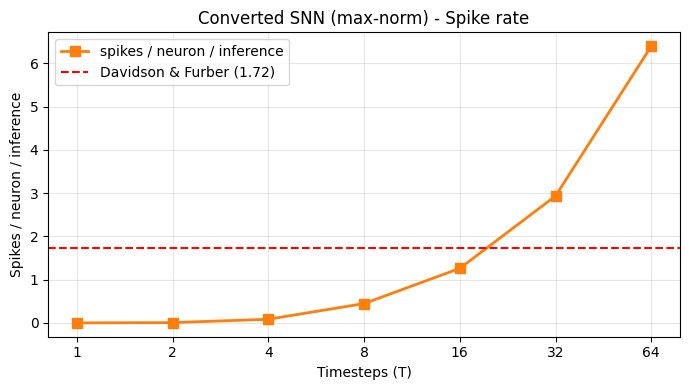

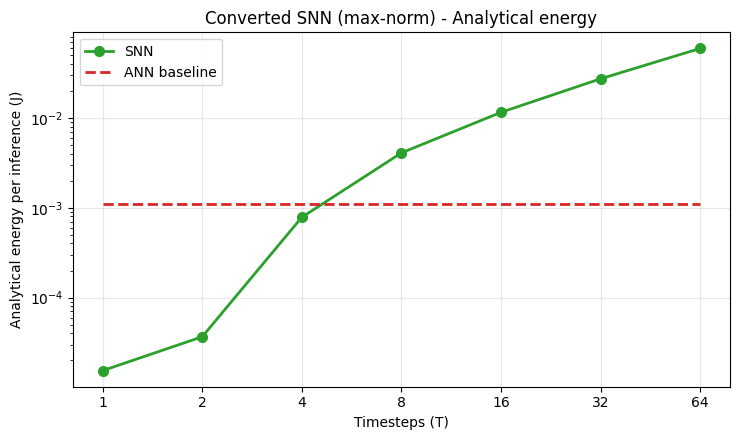

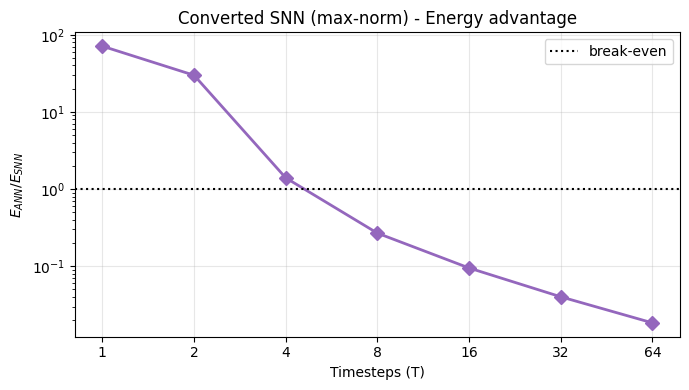

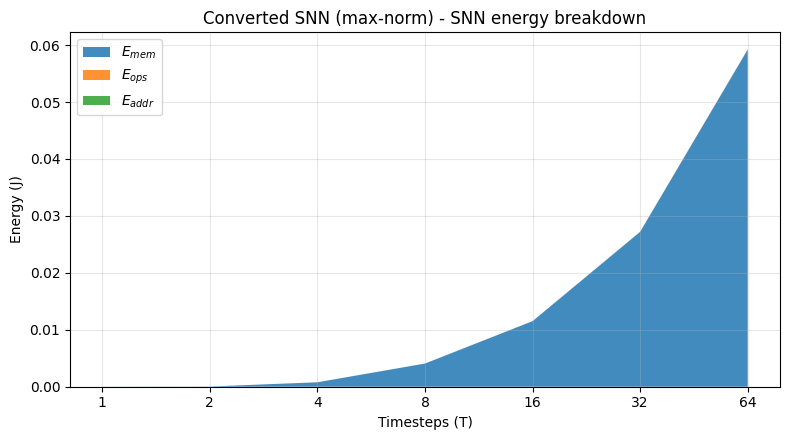

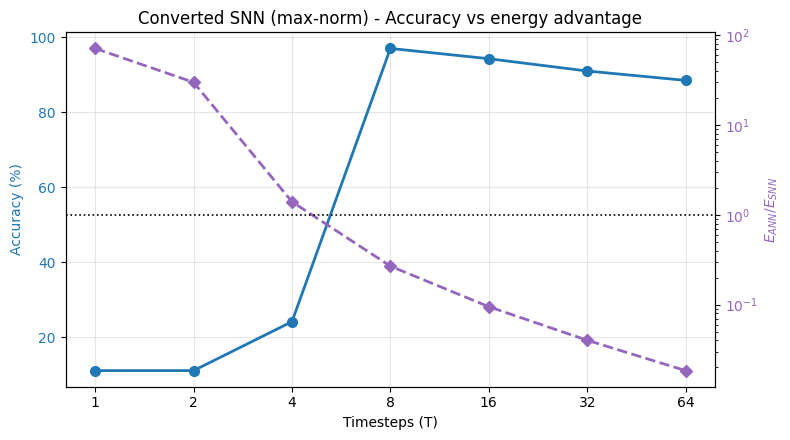

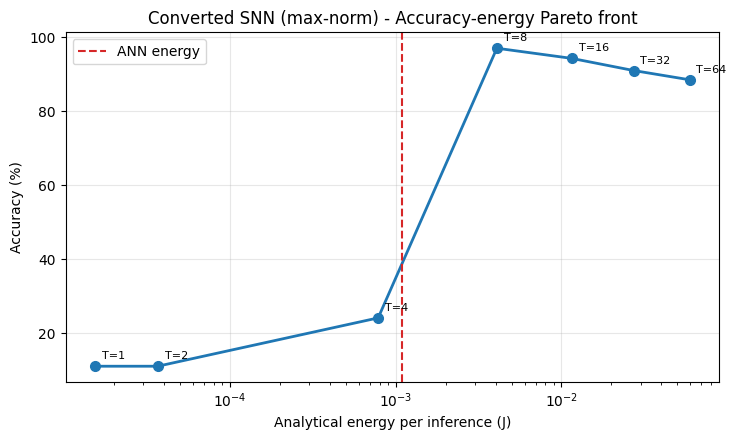

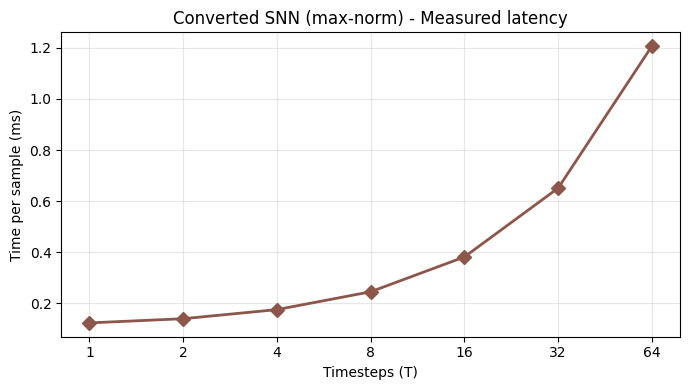

       layer kind  analog_in  input_scale     theta_in    theta_out  neurons  firing_rate   snn_mac      snn_acc       snn_rd       snn_wr    snn_E_mem    snn_E_ops   snn_E_addr  snn_E_total  snn_mem_kB  snn_pJ_per_access  ann_mac  ann_E_total  ann_mem_kB  ratio_ann_over_snn  snn_pct_of_total
  features.0 conv       True     1.000000  3325.081555 46831.857031    25088     0.058334 7225344.0 8.028160e+05 1.605632e+07 1.605632e+06 4.495719e-04 2.320138e-05 8.371200e-08 4.728570e-04   99.632812          25.454259   225792 1.360802e-05  102.312500            0.028778          1.736351
  features.3 conv      False     2.335839 22902.778906 61998.667188    12544     0.154453       0.0 1.365541e+07 2.643199e+07 1.326654e+07 1.089509e-03 1.365541e-06 1.465778e-06 1.092340e-03  124.312500          27.444556  3612672 2.230834e-04  145.750000            0.204225          4.011119
classifier.1   fc      False     2.861293 31770.210156  1993.821094      512     0.121693       0.0 1.628473e+07 3.256

In [59]:
x0, _ = next(iter(a_test_dataloader))

# ---- ANN baseline: NOT through run_benchmark ----
ann_tot, ann_layers = ann_baseline(best_model, x0[:1].to(DEVICE), DEVICE)
ann_acc = accuracy_vs_T(best_model, a_test_dataloader, [1], DEVICE, spiking=False)
print(f"ANN: {ann_tot['E_total']:.4e} J/sample, acc {ann_acc['accuracy'][0]:.4f}")
print(ann_layers.to_string(index=False))

# ---- Converted SNN ----
summary, per_layer = run_benchmark(
    conv_snn_max, a_test_dataloader, DEVICE,
    Ts=[1, 2, 4, 8, 16, 32, 64],
    max_batches_l1=20,
    l3_min_duration_s=20.0,
    acc_max_batches=None,
)
print(summary.to_string(index=False))
plot_all(summary, prefix="Converted SNN (max-norm) - ")
print(per_layer[32].to_string(index=False)) 

In [68]:
type(ann_acc)

pandas.core.frame.DataFrame

In [66]:
len(ann_acc[ann_acc["accuracy"] >= 0.98])

1

In [71]:
crossing_points(ann_acc, summary)



{'T_energy_breakeven': 8,
 'T_1p72': 32,
 'T_accuracy': nan,
 'verdict': 'SNN never reaches ANN accuracy in the swept range'}

ANN baseline (int32)
  accuracy        : 0.9846
  MACs            : 5,577,728
  memory ops      : 9,496,916
  E_analytical    : 1.0945e-03 J/sample
    E_mem         : 1.0766e-03 J (98.4%)
    E_ops         : 1.7853e-05 J (1.6%)
    E_addr        : 5.0234e-09 J (0.0%)
  latency         : 0.1068 ms/sample
  GPU (marginal)  : 2.5344e-04 J/sample
  power spread    : 0.5 W across 3 trials

       layer kind     mac      rd    wr      mem_kB  pJ_per_access        E_mem        E_ops      E_total  pct_of_total
  features.0 conv  225792  476672 25088  102.312500      25.670363 1.288036e-05 7.250432e-07 1.360802e-05      1.243330
  features.3 conv 3612672 7237888 12544  145.750000      29.173387 2.115197e-04 1.156180e-05 2.230834e-04     20.382558
classifier.1   fc 1605632 1609280   512 6288.250000     524.536290 8.443943e-04 5.138074e-06 8.495328e-04     77.619629
classifier.4   fc  131072  131840   256  516.000000      59.032258 7.797925e-06 4.194560e-07 8.217458e-06      0.750808
classifier.

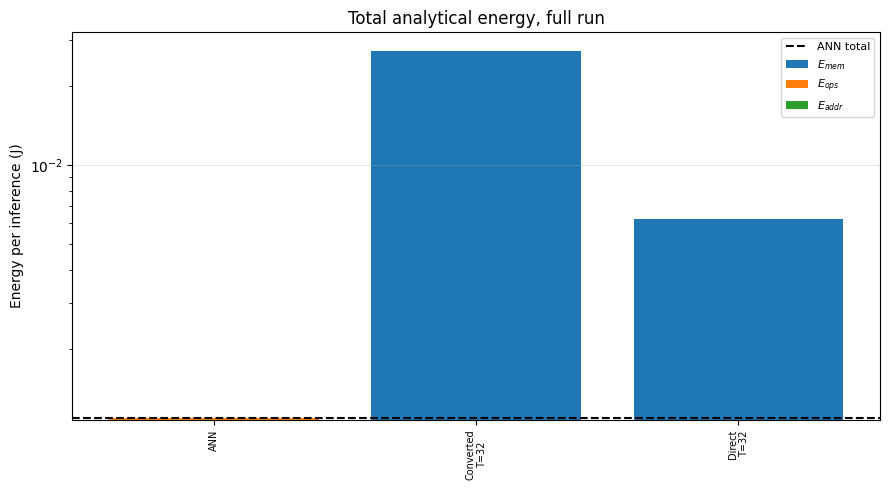

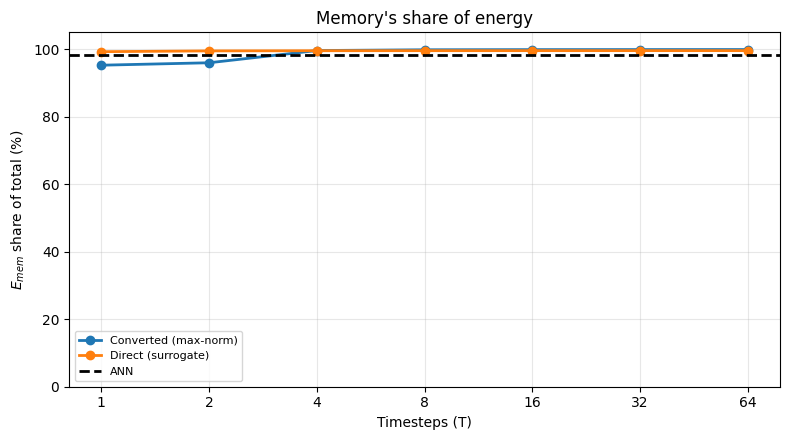

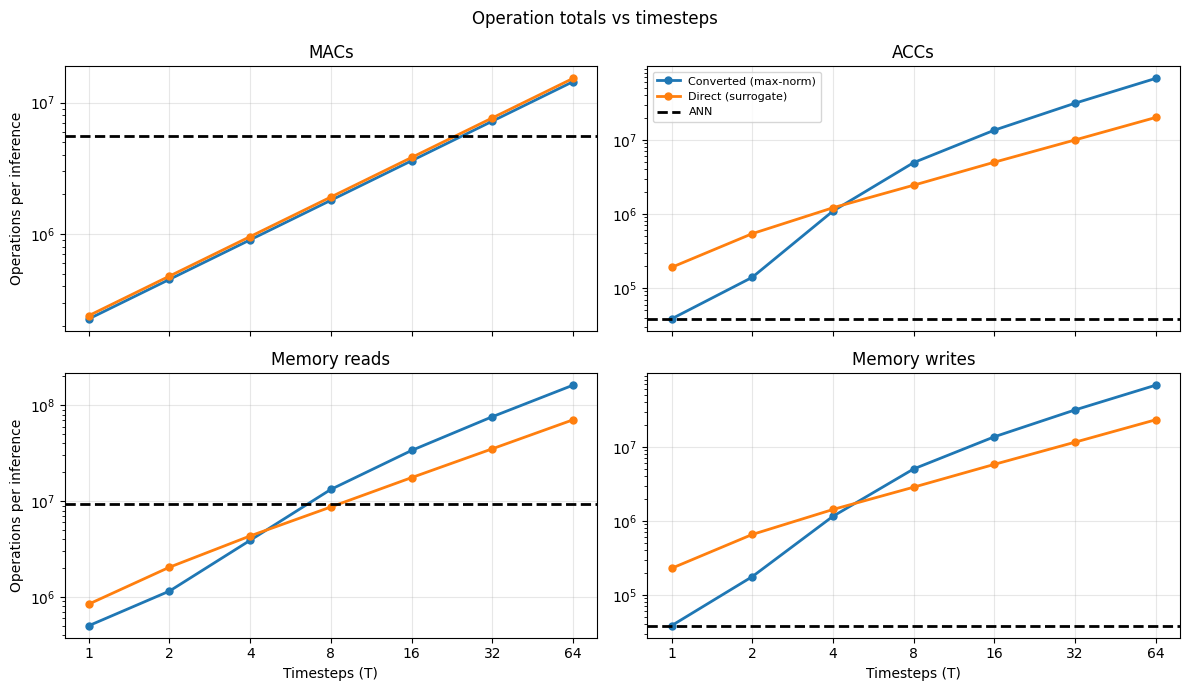

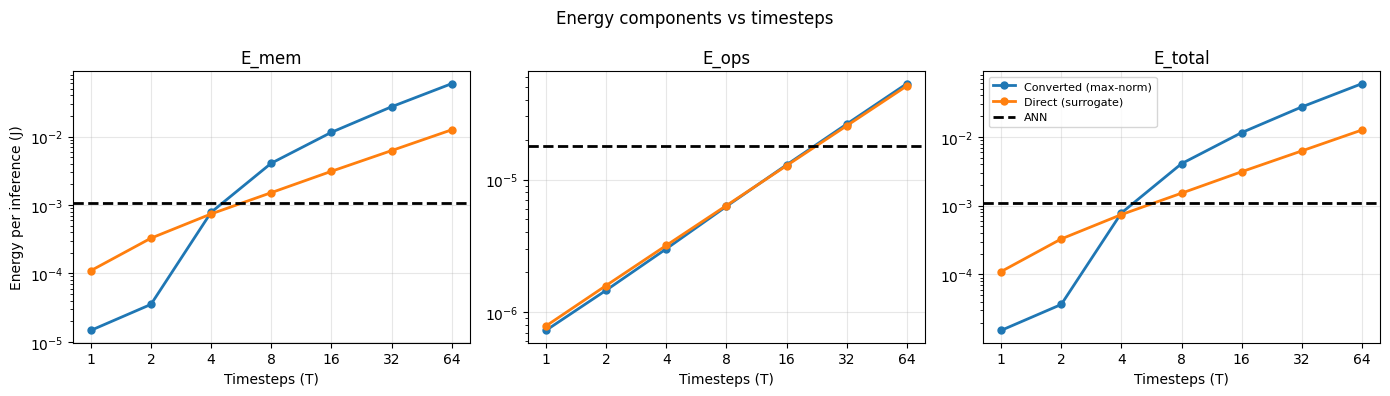

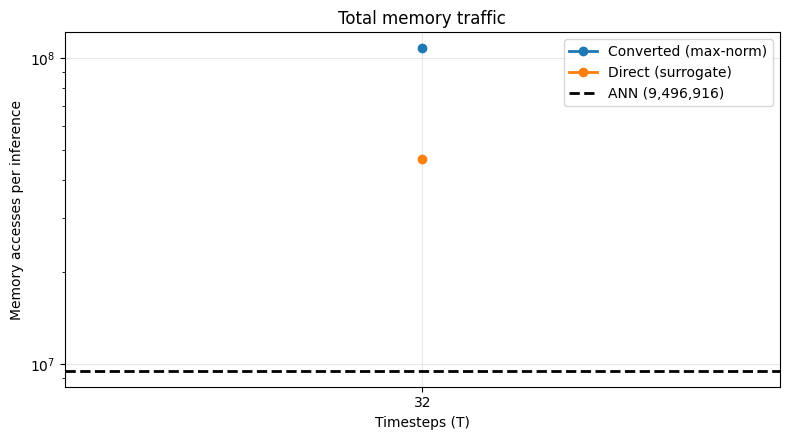

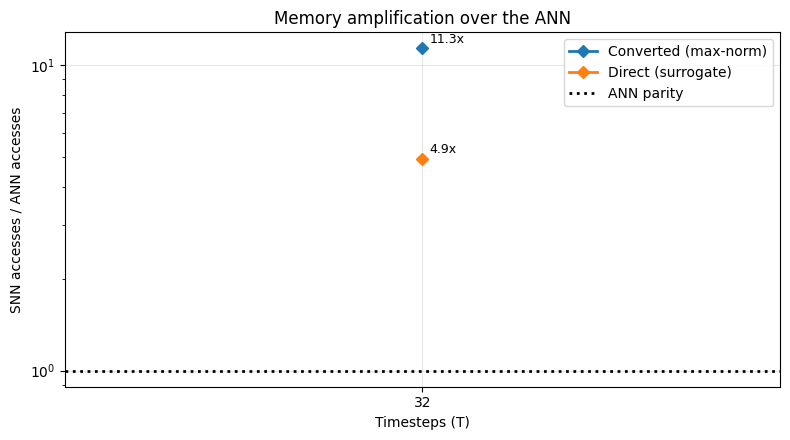

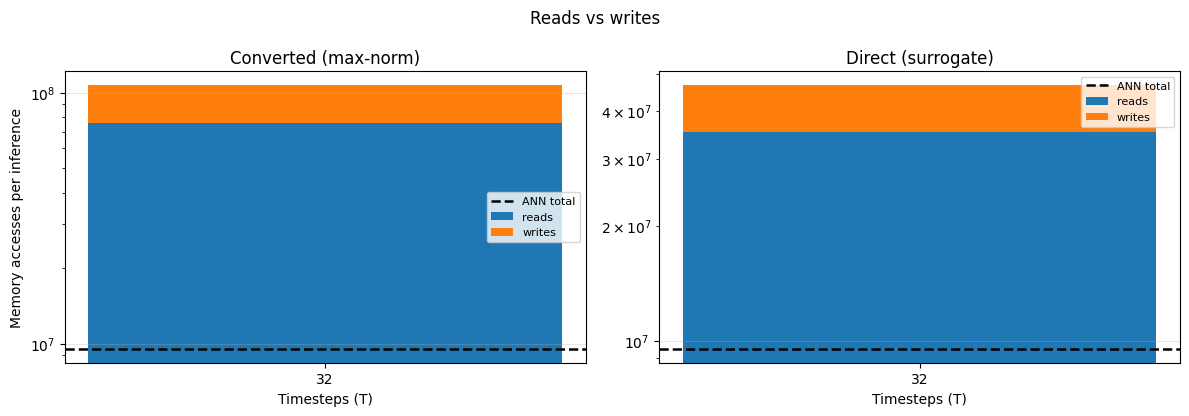

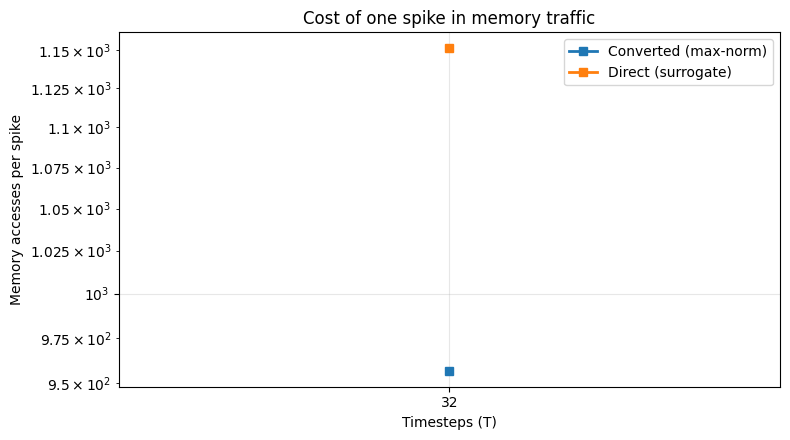

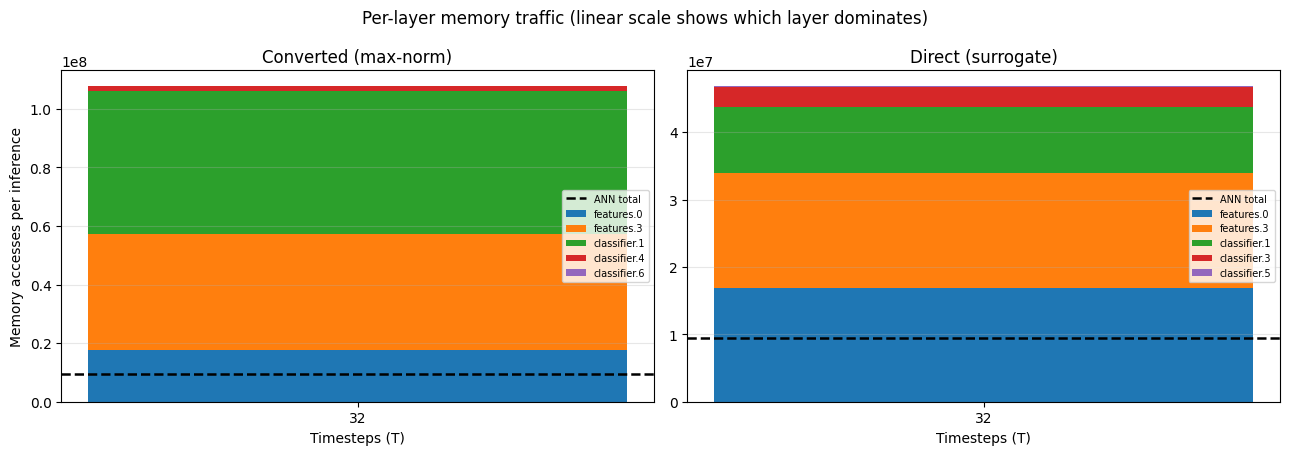

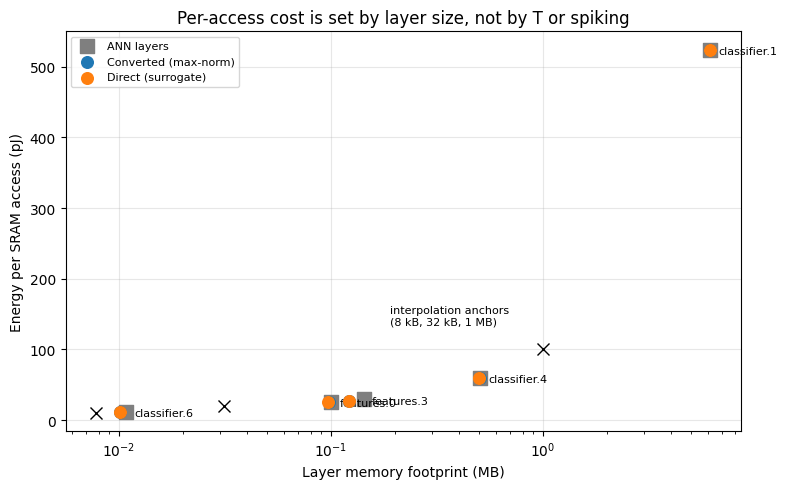

In [72]:
ann = profile_ann(best_model, a_test_dataloader, DEVICE)
#   ann["accuracy"]   -> float, e.g. 0.9864
#   ann["totals"]     -> dict of analytical energy totals
#   ann["per_layer"]  -> DataFrame, one row per layer
#   ann["empirical"]  -> Level 3 dict
#   ann["point"]      -> one-row DataFrame
conv_sum, conv_layers = run_benchmark(conv_snn_max, a_test_dataloader, DEVICE)
dir_sum,  dir_layers  = run_benchmark(snn,          a_test_dataloader, DEVICE)

models = {
    "Converted (max-norm)": (conv_sum, conv_layers),
    "Direct (surrogate)":   (dir_sum,  dir_layers),
}

totals = build_totals(ann, models)
print(totals.to_string(index=False))
print(memory_summary(ann, totals, at_T=32).to_string(index=False))

plot_totals(ann, totals, at_T=32)
plot_memory_accesses(ann, models, at_T=32)

In [73]:


from __future__ import annotations

from typing import Dict, List, Optional, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn


Source = Union[nn.Module, pd.DataFrame, float]


def _label(ratio: float) -> str:
    """'1.02x (+2.1%)' / '0.96x (-4.2%)'. A ratio below 1 is 0.96x, never
    -0.96x, so the signed percentage carries the direction."""
    if np.isnan(ratio):
        return "n/a"
    return f"{ratio:.2f}x ({100 * (ratio - 1):+.1f}%)"


def accuracy_retention(
    baseline: Source,
    models: Dict[str, Source],
    loader=None,
    device=None,
    Ts: Optional[List[int]] = None,
    max_batches: Optional[int] = None
) -> pd.DataFrame:
    """
    baseline : the ANN. An nn.Module (evaluated with a single forward pass),
               a float accuracy, or a DataFrame with an 'accuracy' column.
    models   : label -> nn.Module (swept over Ts) or a run_benchmark summary
               DataFrame that already carries 'T' and 'accuracy'.
    """
    # baseline accuracy
    if isinstance(baseline, nn.Module):
        if loader is None or device is None:
            raise ValueError("loader and device are required to evaluate an "
                             "nn.Module baseline")
        base_acc = float(accuracy_vs_T(baseline, loader, [1], device,
                                       spiking=False,
                                       max_batches=max_batches)["accuracy"].iloc[0])
    elif isinstance(baseline, pd.DataFrame):
        base_acc = float(baseline["accuracy"].iloc[0])
    else:
        base_acc = float(baseline)

    if not 0 < base_acc <= 1:
        raise ValueError(f"baseline accuracy {base_acc} is not a fraction in "
                         "(0, 1] -- pass 0.95, not 95")

    # each model 
    rows = []
    for name, src in models.items():
        if isinstance(src, nn.Module):
            if loader is None or device is None or Ts is None:
                raise ValueError(f"loader, device and Ts are required to "
                                 f"evaluate '{name}'")
            got = accuracy_vs_T(src, loader, list(Ts), device,
                                spiking=True, max_batches=max_batches)
        elif isinstance(src, pd.DataFrame):
            if "accuracy" not in src.columns:
                raise ValueError(f"'{name}' has no 'accuracy' column -- run "
                                 "run_benchmark with measure_accuracy=True")
            got = src[["T", "accuracy"]].copy()
        else:
            got = pd.DataFrame({"T": [np.nan], "accuracy": [float(src)]})

        for _, r in got.sort_values("T").iterrows():
            acc = float(r["accuracy"])
            ratio = acc / base_acc
            rows.append({
                "model": name,
                "T": r["T"],
                "accuracy": acc,
                "baseline_accuracy": base_acc,
                "retention": ratio,
                "retention_pct": 100 * ratio,
                "delta_pp": 100 * (acc - base_acc),
                "delta_rel_pct": 100 * (ratio - 1),
                "label": _label(ratio),
            })

    df = pd.DataFrame(rows)
    df.attrs["baseline_accuracy"] = base_acc
    return df


def best_retention(df: pd.DataFrame) -> pd.DataFrame:
    """The strongest operating point for each model."""
    return (df.sort_values("retention", ascending=False)
              .groupby("model", as_index=False).first()
              .sort_values("retention", ascending=False))


# PLOTS
def plot_accuracy_retention(df: pd.DataFrame,annotate: bool = True, at_T: Optional[int] = None,target: float = 0.95):
    """
    1. retention vs T, one line per model, annotated with 'x (+/-%)'
    2. horizontal bars at one T, coloured by direction
    """
    base = df.attrs.get("baseline_accuracy", df["baseline_accuracy"].iloc[0])
    swept = df[df["T"].notna()]

    # 1. retention vs T 
    if len(swept):
        all_T = sorted(swept["T"].unique().astype(int))
        fig, ax = plt.subplots(figsize=(9, 5))
        for i, (name, g) in enumerate(swept.groupby("model")):
            g = g.sort_values("T")
            ax.plot(g["T"], g["retention"], "o-", lw=2, ms=7,
                    color=f"C{i}", label=name)
            if annotate:
                for _, r in g.iterrows():
                    ax.annotate(r["label"], (r["T"], r["retention"]),
                                textcoords="offset points", xytext=(0, 9),
                                ha="center", fontsize=7.5, color=f"C{i}")

        ax.axhline(1.0, color="k", ls="--", lw=2,
                   label=f"ANN baseline ({100 * base:.2f}%)")
        ax.axhline(target, color="red", ls=":", lw=1.5,
                   label=f"{100 * target:.0f}% retention")
        ax.fill_between([min(all_T), max(all_T)], 1.0, ax.get_ylim()[1],
                        color="green", alpha=0.06)

        ax.set_xscale("log", base=2)
        ax.set_xticks(all_T); ax.set_xticklabels(all_T)
        ax.set_xlabel("Timesteps (T)")
        ax.set_ylabel(r"Accuracy retention  ($Acc_{SNN}/Acc_{ANN}$)")
        ax.set_title("Accuracy retention vs timesteps")
        ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc="lower right")
        fig.tight_layout(); plt.show()

    #2. bars at one operating point
    if at_T is None and len(swept):
        at_T = int(swept.loc[swept["retention"].idxmax(), "T"])
    snap = df[df["T"] == at_T] if at_T is not None else df
    if not len(snap):
        return

    snap = snap.sort_values("retention")
    idx = np.arange(len(snap))
    colours = ["#2a9d5c" if v >= 1 else "#c0392b" for v in snap["retention"]]

    fig, ax = plt.subplots(figsize=(8.5, 0.8 * len(snap) + 2.4))
    ax.barh(idx, snap["retention"], color=colours, alpha=0.85)
    ax.axvline(1.0, color="k", ls="--", lw=2)
    for i, (_, r) in enumerate(snap.iterrows()):
        ax.annotate(f"  {r['label']}   acc {100 * r['accuracy']:.2f}%",
                    (r["retention"], i), va="center", fontsize=9)
    ax.set_yticks(idx); ax.set_yticklabels(snap["model"], fontsize=9)
    ax.set_xlabel(r"Accuracy retention  ($Acc_{SNN}/Acc_{ANN}$)")
    ax.set_xlim(0, max(1.15, snap["retention"].max() * 1.35))
    ax.set_title(f"Retention against the ANN "
                 f"({100 * base:.2f}%)" + (f", T = {at_T}" if at_T else ""))
    ax.grid(True, axis="x", alpha=0.3)
    fig.tight_layout(); plt.show()


def plot_retention_vs_energy(df: pd.DataFrame,summaries: Dict[str, pd.DataFrame], E_ann: float):
    """
    Retention against analytical energy. The useful region is upper-left:
    retention near 1 at energy below the ANN's.
    """
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    for i, (name, s) in enumerate(summaries.items()):
        g = df[df["model"] == name].merge(
            s[["T", "E_snn"]], on="T").sort_values("T")
        ax.plot(g["E_snn"], g["retention"], "o-", lw=2, ms=7,
                color=f"C{i}", label=name)
        for _, r in g.iterrows():
            ax.annotate(f"T={int(r['T'])}", (r["E_snn"], r["retention"]),
                        textcoords="offset points", xytext=(6, 4), fontsize=8)

    ax.axhline(1.0, color="k", ls="--", lw=2, label="ANN accuracy")
    ax.axvline(E_ann, color="C3", ls="--", lw=2, label="ANN energy")
    ax.set_xscale("log")
    ax.set_xlabel("Analytical energy per inference (J)")
    ax.set_ylabel(r"Accuracy retention  ($Acc_{SNN}/Acc_{ANN}$)")
    ax.set_title("Retention vs energy (upper-left quadrant is the win)")
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()

               model    T  accuracy  baseline_accuracy  retention  retention_pct  delta_pp  delta_rel_pct          label
Converted (max-norm)  1.0    0.1106             0.9846   0.112330      11.232988    -87.40     -88.767012 0.11x (-88.8%)
Converted (max-norm)  2.0    0.1106             0.9846   0.112330      11.232988    -87.40     -88.767012 0.11x (-88.8%)
Converted (max-norm)  4.0    0.2412             0.9846   0.244973      24.497258    -74.34     -75.502742 0.24x (-75.5%)
Converted (max-norm)  8.0    0.9698             0.9846   0.984969      98.496852     -1.48      -1.503148  0.98x (-1.5%)
Converted (max-norm) 16.0    0.9424             0.9846   0.957140      95.713996     -4.22      -4.286004  0.96x (-4.3%)
Converted (max-norm) 32.0    0.9096             0.9846   0.923827      92.382693     -7.50      -7.617307  0.92x (-7.6%)
Converted (max-norm) 64.0    0.8846             0.9846   0.898436      89.843591    -10.00     -10.156409 0.90x (-10.2%)
  Direct (surrogate)  1.0    0.9

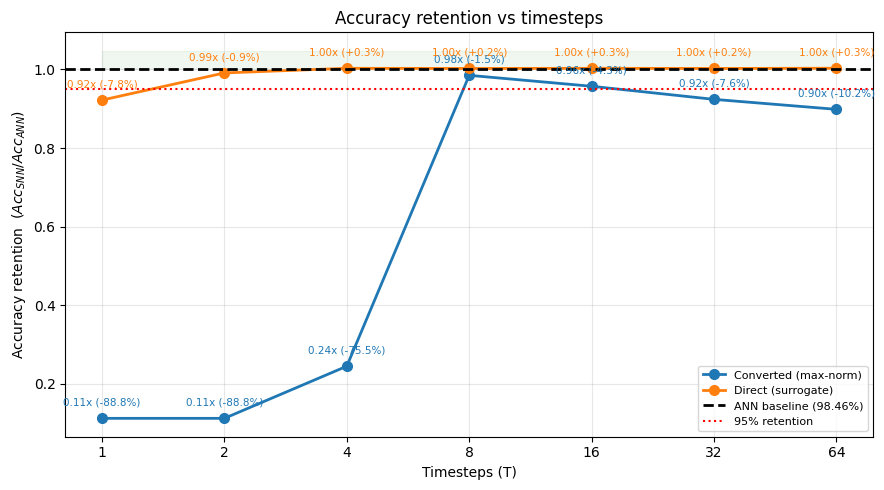

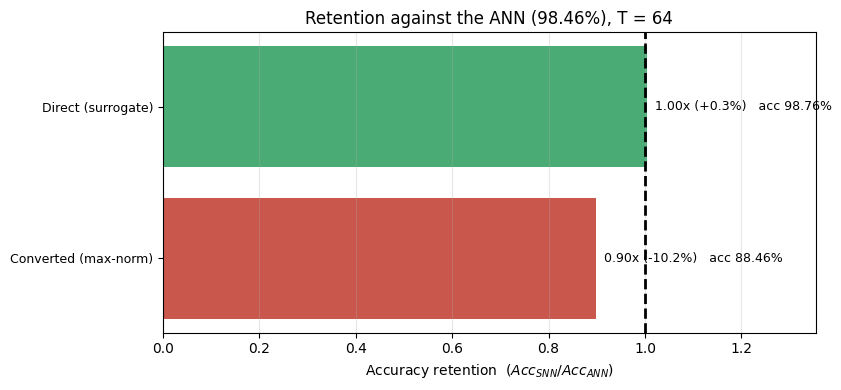

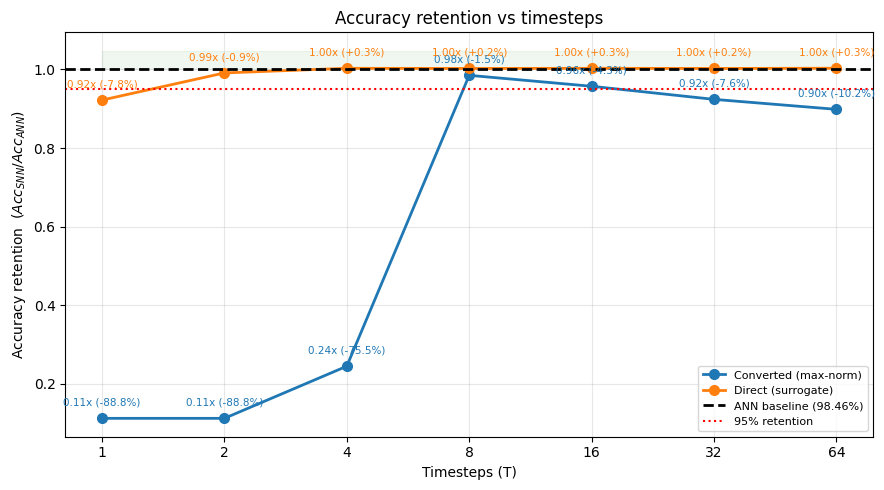

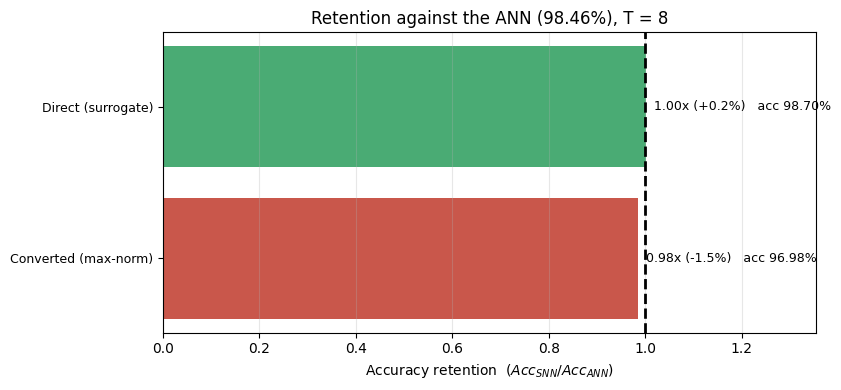

In [74]:
ret = accuracy_retention(ann["accuracy"], {
    "Converted (max-norm)": conv_sum,
    "Direct (surrogate)":   dir_sum,
})
print(ret.to_string(index=False))
print(best_retention(ret).to_string(index=False))

plot_accuracy_retention(ret)                 # picks the best T for the bar chart
plot_accuracy_retention(ret, at_T=8)         # or force one

In [75]:
ret = accuracy_retention(
    0.9864,                                    # baseline accuracy as a float
    {"Converted (max-norm)": conv_snn_max},    # the model itself
    loader=a_test_dataloader, device=DEVICE,
    Ts=[1, 2, 4, 8, 16, 32, 64],
)

               model    T  accuracy  baseline_accuracy  retention  retention_pct  delta_pp  delta_rel_pct          label
Converted (max-norm)  1.0    0.1106             0.9864   0.112125      11.212490    -87.58     -88.787510 0.11x (-88.8%)
Converted (max-norm)  2.0    0.1106             0.9864   0.112125      11.212490    -87.58     -88.787510 0.11x (-88.8%)
Converted (max-norm)  4.0    0.2412             0.9864   0.244526      24.452555    -74.52     -75.547445 0.24x (-75.5%)
Converted (max-norm)  8.0    0.9698             0.9864   0.983171      98.317113     -1.66      -1.682887  0.98x (-1.7%)
Converted (max-norm) 16.0    0.9424             0.9864   0.955393      95.539335     -4.40      -4.460665  0.96x (-4.5%)
Converted (max-norm) 32.0    0.9096             0.9864   0.922141      92.214112     -7.68      -7.785888  0.92x (-7.8%)
Converted (max-norm) 64.0    0.8846             0.9864   0.896796      89.679643    -10.18     -10.320357 0.90x (-10.3%)
               model   T  accura

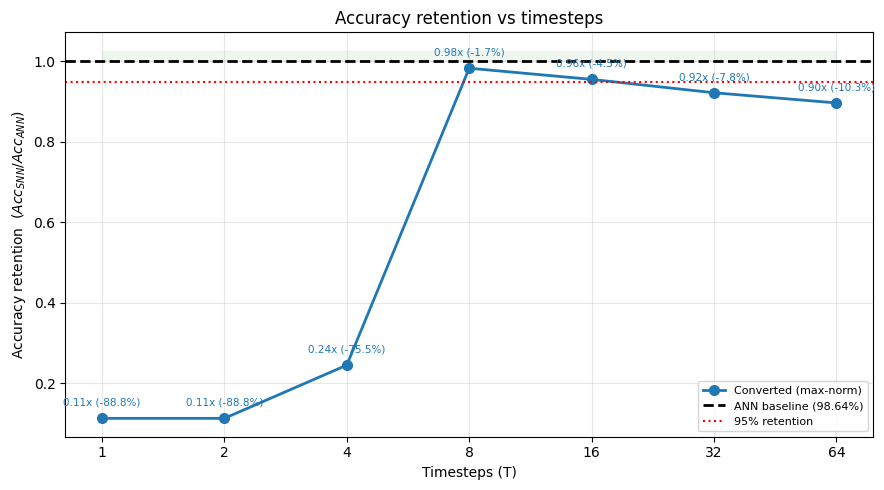

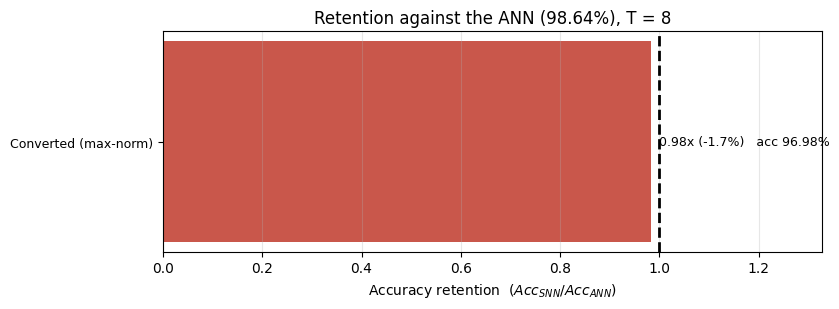

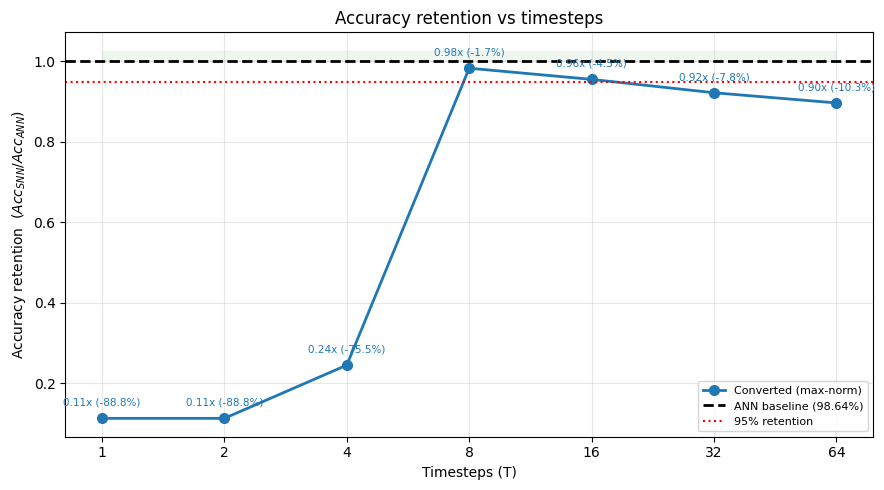

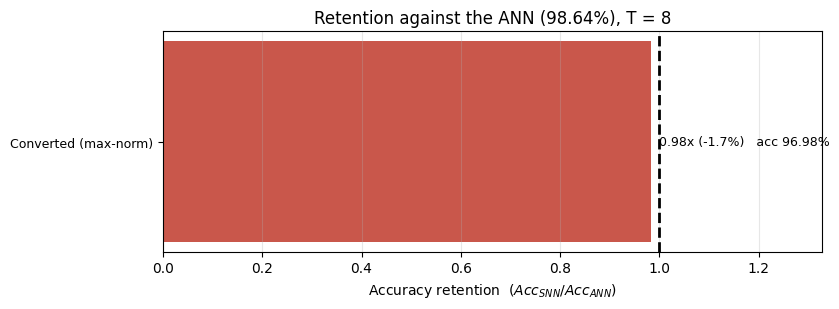

In [76]:
print(ret.to_string(index=False))
print(best_retention(ret).to_string(index=False))

plot_accuracy_retention(ret)                 # picks the best T for the bar chart
plot_accuracy_retention(ret, at_T=8)         # or force one

               model    T  accuracy        spikes  neurons  spikes_per_neuron        mac          acc    mem_reads   mem_writes  mem_accesses  accesses_per_mac  accesses_per_spike    E_mem        E_ops       E_addr  E_total  pct_E_mem  mean_pJ_per_access  E_ratio_ann_over_model  mem_amplification
                 ANN  NaN    0.9846      0.000000        0                NaN  5577728.0 3.841000e+04 9.458506e+06 3.841000e+04  9.496916e+06          1.702650                 NaN 0.001077 1.785257e-05 5.023400e-09 0.001094  98.368397          113.365672                1.000000           1.000000
Converted (max-norm)  1.0    0.1106      0.004687    38400       1.220703e-07   225792.0 3.841270e+04 5.033214e+05 3.841270e+04  5.417341e+05          2.399262        1.155699e+08 0.000015 7.263757e-07 2.616300e-09 0.000015  95.261318           27.051763               71.144840           0.057043
Converted (max-norm)  2.0    0.1106    242.063281    38400       6.303731e-03   451584.0 1.397552e+05 1.15

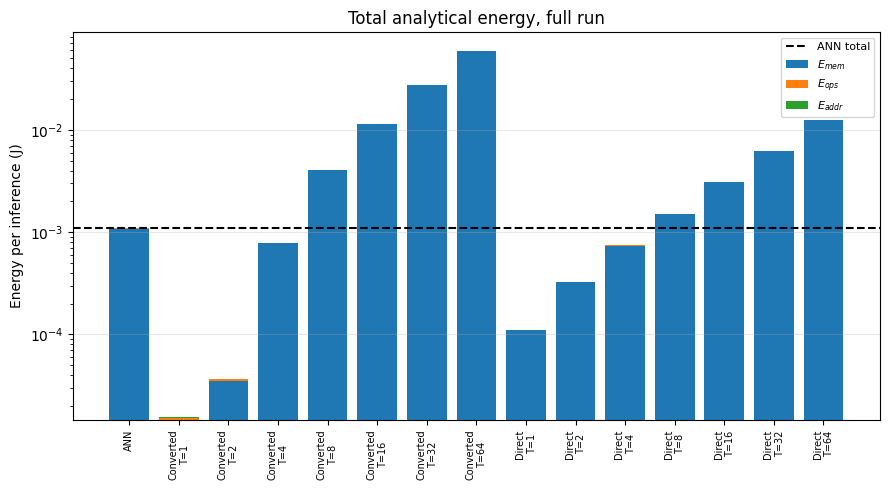

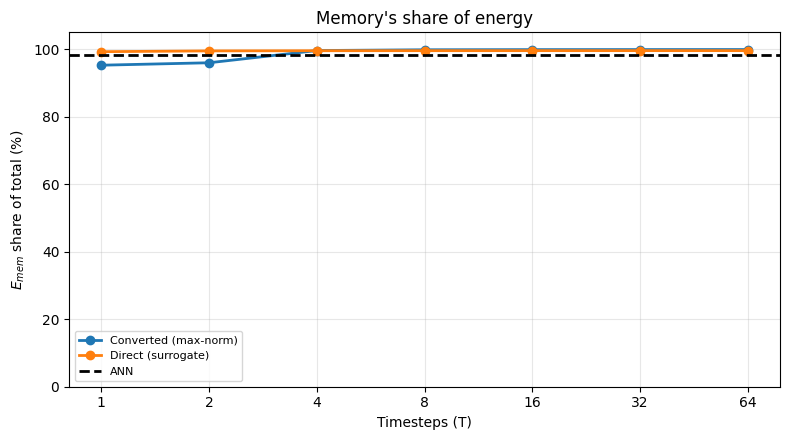

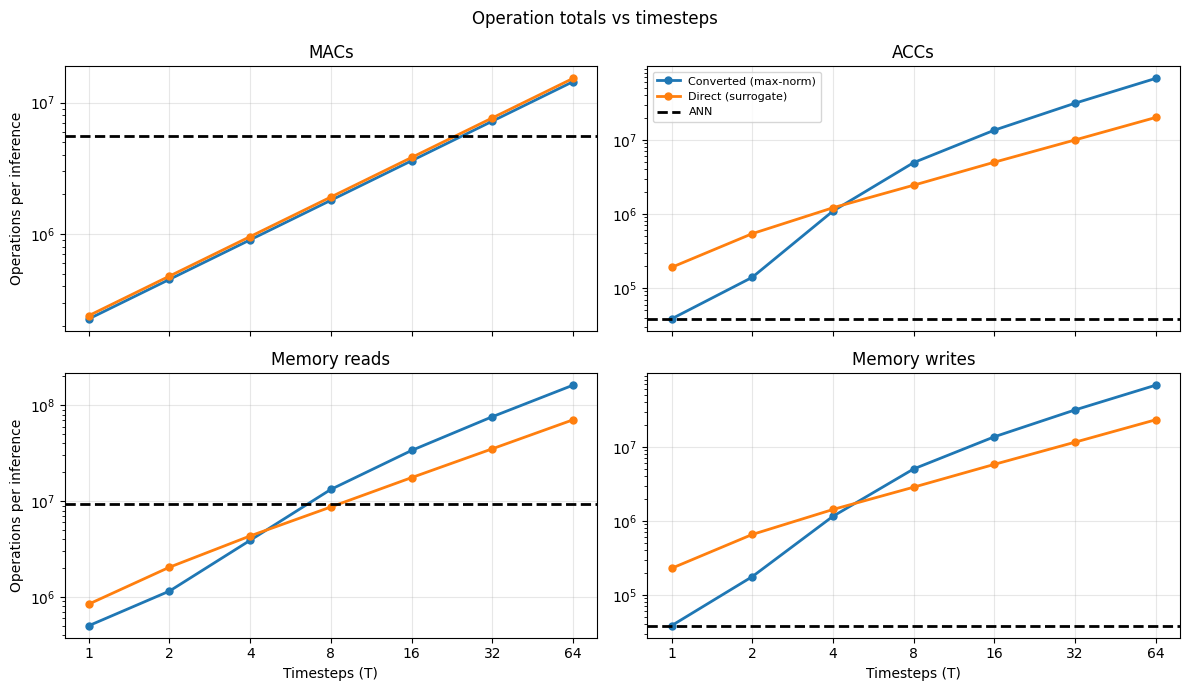

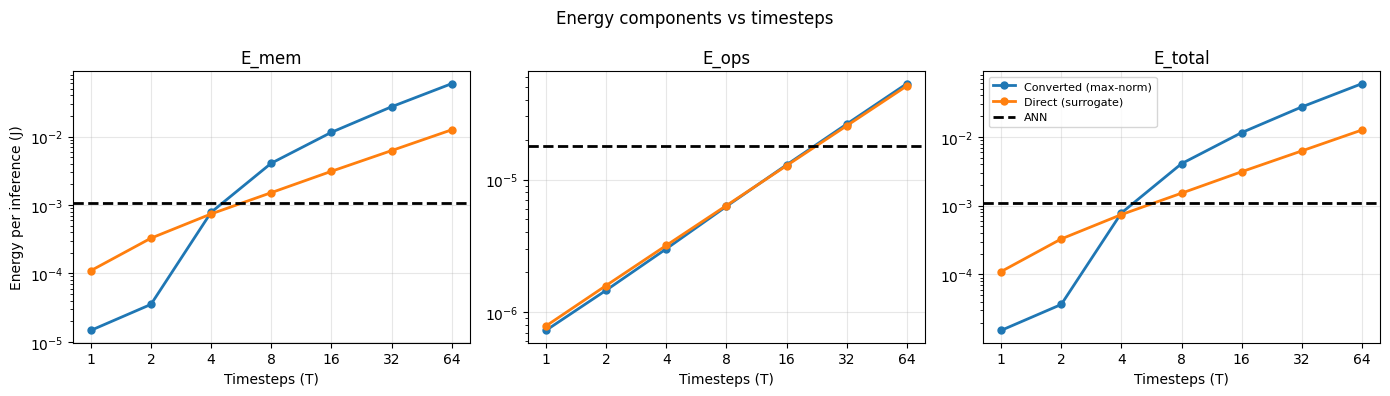

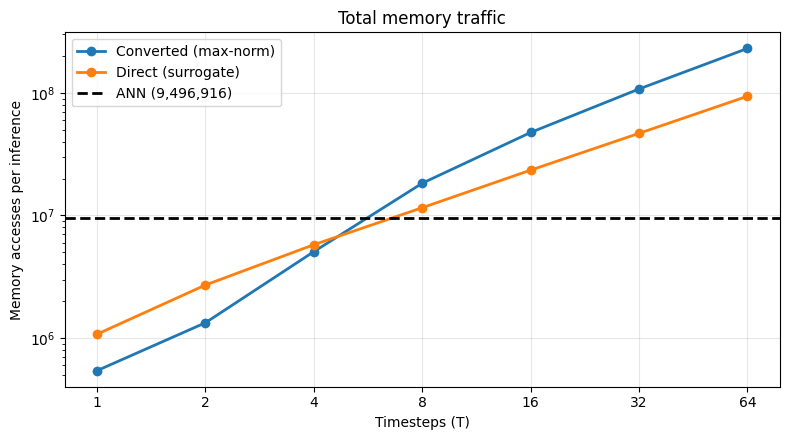

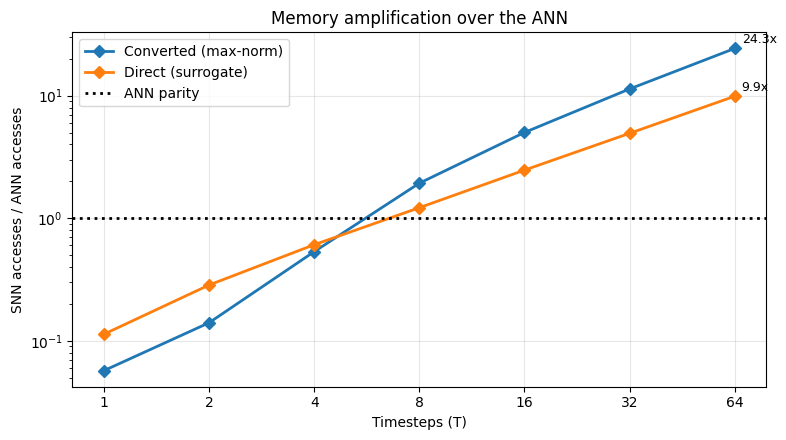

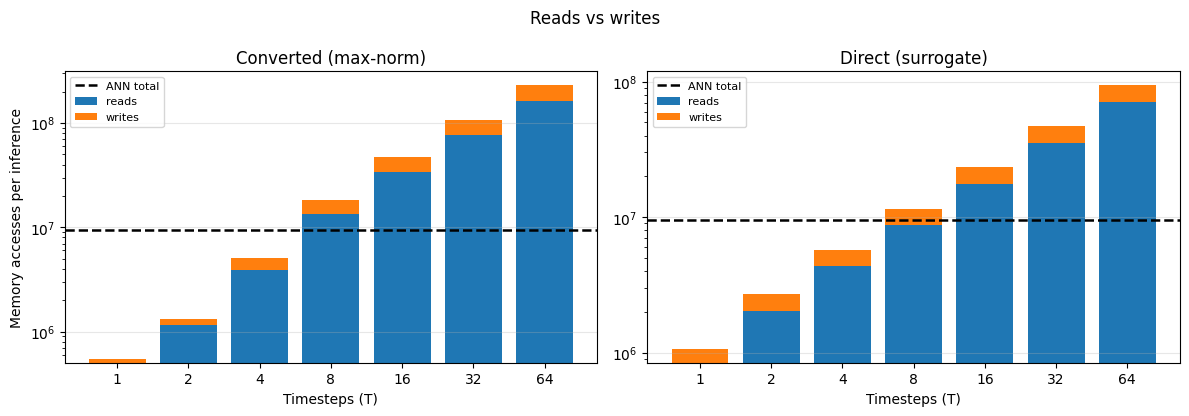

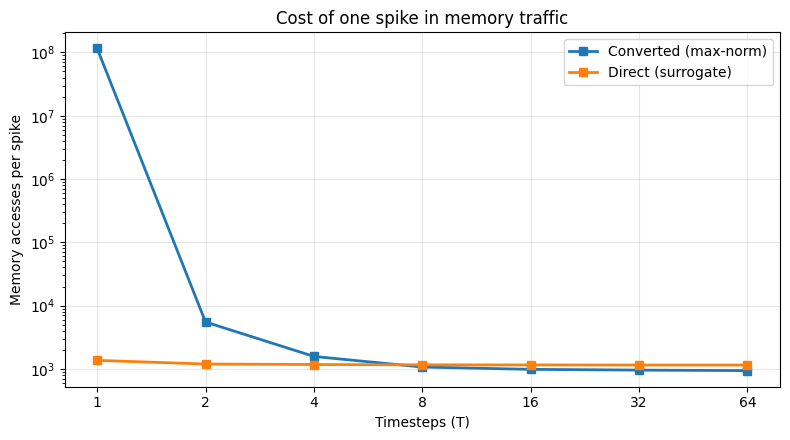

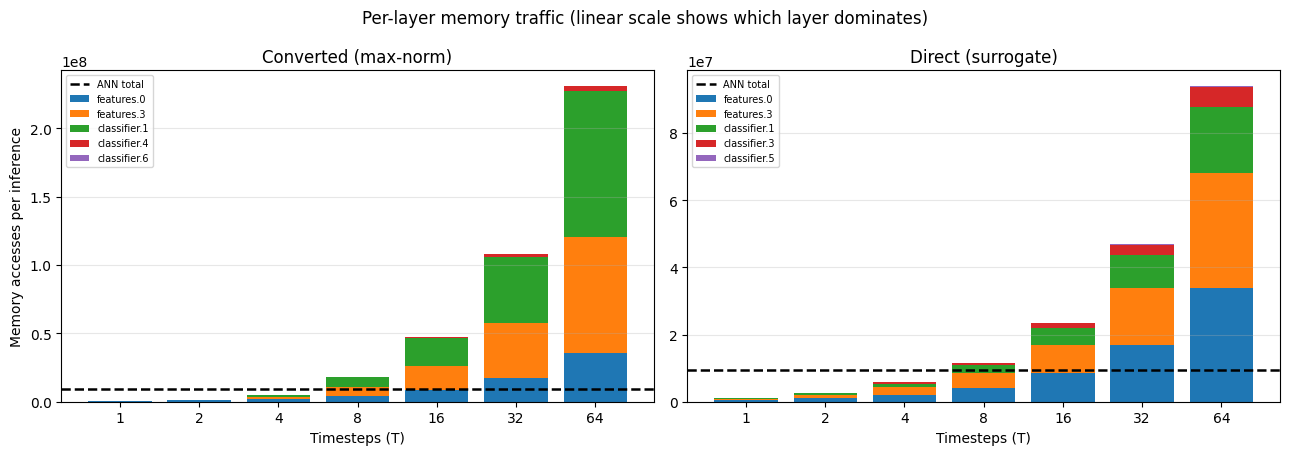

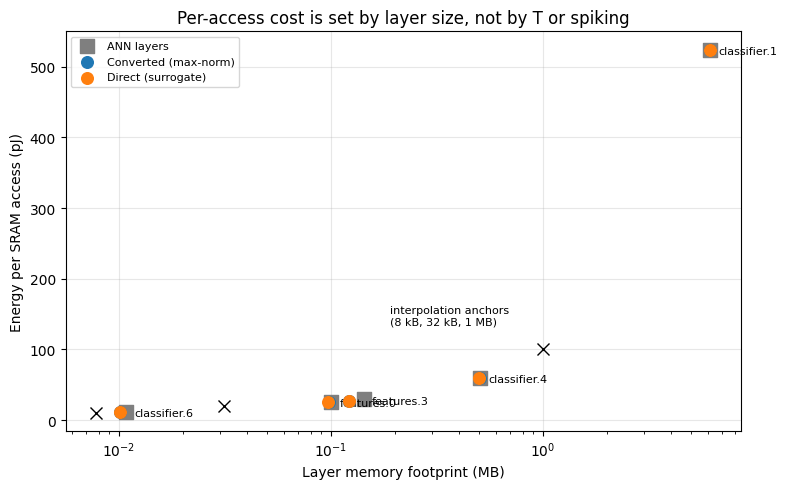

In [77]:
totals = build_totals(ann, models)
print(totals.to_string(index=False))
print(memory_summary(ann, totals).to_string(index=False))

plot_totals(ann, totals)
plot_memory_accesses(ann, models)